# In Silico `Toxicity` prediction for `Bacillus Anthracis` Antibiotic Candidates

This workflow uses `admet_ai` predictions to perform a **rule-based safety triage** of candidate molecules.

The goal is to support **early prioritization**, not to make definitive toxicity claims.

We separate predictions into three categories:

- **Core toxicity risk**: direct safety concerns such as hERG, DILI, AMES, and ClinTox
- **Mechanistic alerts**: stress-response and nuclear-receptor pathway signals
- **ADME / metabolism liabilities**: permeability, transporter, and CYP-related liabilities that may affect developability but do not necessarily imply intrinsic toxicity

In [10]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [11]:
import numpy as np
import pandas as pd
import pubchempy as pcp
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from admet_ai import ADMETModel
from admet_ai.drugbank import get_drugbank
import matplotlib.pyplot as plt
from scipy.stats import percentileofscore

# 6. Data directory for model trained on `ChEMBL + PubChem` bioassay dataset

In [12]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
#resultsDir = os.path.join(dataDir, 'Results/')
saveDir = os.path.join(dataDir, "Results/Bacillus_anthracis_bestMACAW_allDB/")
#DORANETmoleculesDataDir = os.path.join(dataDir, 'DORAnet_molecules/')
#ARTresultsDir = os.path.join(dataDir, 'Results/Bacillus_anthracis_bestMACAW/')
os.makedirs(saveDir, exist_ok=True)

## 6.1 Read `ADMET` endpoints with `pPotency`of the FDA approved Drug data from `Drugbank`

In [13]:
drugBankDrug_FDAapproved_antibiotic_wToxicity = pd.read_csv(saveDir + 'BacillusAnthracis_Drugbnk_FDAapproved_Antibiotic_ARTprediction.csv')
# Identify columns that match the string
matched_cols = drugBankDrug_FDAapproved_antibiotic_wToxicity.filter(like='drugbank_approved_percentile').columns
# Keep everything EXCEPT those columns
drugBankDrug_FDAapproved_antibiotic_wToxicity = drugBankDrug_FDAapproved_antibiotic_wToxicity.drop(columns=matched_cols)
max_val = drugBankDrug_FDAapproved_antibiotic_wToxicity['pPotency_prediction'].max()
min_val = drugBankDrug_FDAapproved_antibiotic_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
drugBankDrug_FDAapproved_antibiotic_wToxicity

pPotency_prediction range: 1.343 → 5.897


,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,Unnamed: 0,ATC_code,...,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo,source_DataBase
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,3.525954,1.119518,1.331698,5.720210,0.000298,1.904541e-06,0.046591,0,J01GB;J01RA,...,36.152091,2.245671,7.526745,-20.117337,1.595968,-1.807717,23.987537,-0.102104,-6.522413,FDA_Antibiotics
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,4.987345,1.120375,2.791410,7.183280,0.000010,6.557220e-08,0.001617,1,J01CA;J01CR,...,8.870990,8.964288,-0.649105,-13.895778,1.984036,-0.922387,59.371961,-1.955969,0.402972,FDA_Antibiotics
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,3.442877,1.119518,1.248620,5.637133,0.000361,2.306042e-06,0.056413,4,J01CA;J01CR,...,3.494191,44.284968,1.065897,-13.175952,2.165658,-0.854850,78.940997,-2.968939,2.201075,FDA_Antibiotics
3,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,3.786489,1.118681,1.593873,5.979105,0.000163,1.049289e-06,0.025476,5,J01DF,...,-10.878718,0.653251,-1.372036,-15.327836,2.373001,-3.370004,59.166133,-1.183660,5.657260,FDA_Antibiotics
4,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,3.794162,1.118931,1.601058,5.987267,0.000161,1.029753e-06,0.025058,6,J01CA;J01CR,...,100.958985,117.151278,-23.185533,-9.495806,2.714478,2.047164,75.654842,-2.922240,5.521395,FDA_Antibiotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,4.309461,1.118857,2.116502,6.502420,0.000049,3.144704e-07,0.007647,146,J01AA,...,9.591706,60.994419,11.583123,-12.590552,2.663011,-0.090869,55.730797,-2.513165,5.962830,FDA_Antibiotics
128,CCS(=O)(=O)CCn1c([N+](=O)[O-])cnc1C,4.424298,1.118918,2.231218,6.617377,0.000038,2.413365e-07,0.005872,147,J01RA;J01XD,...,-0.296836,13.442499,-5.683420,-10.941420,1.811951,-0.624001,46.324032,-1.894738,3.686183,FDA_Antibiotics
129,CO[C@H]1C[C@H](O[C@H]2[C@H](C)[C@@H](O[C@@H]3O...,2.276538,1.125678,0.070209,4.482867,0.005290,3.289523e-05,0.850729,150,J01FA,...,107.706804,61.057693,27.990995,-7.253569,2.947751,2.111868,75.170419,-4.023729,8.703718,FDA_Antibiotics
130,N[C@@H]1[C@H]2CN(c3nc4c(cc3F)c(=O)c(C(=O)O)cn4...,3.073553,1.126205,0.866192,5.280915,0.000844,5.237026e-06,0.136084,151,J01MA,...,8.977690,-22.250148,6.670442,-11.224623,2.764096,-0.132504,59.160649,-4.611402,-2.076524,FDA_Antibiotics


### Convert `SMILES` to `Canonical SMILES` for comparison

In [14]:
def canonicalizeSmiles(smilesValue):
    if pd.isna(smilesValue):
        return None

    smilesStr = str(smilesValue).strip()
    if smilesStr == "":
        return None

    mol = Chem.MolFromSmiles(smilesStr)
    if mol is None:
        return None

    return Chem.MolToSmiles(mol, canonical=True)

drugBankDrug_FDAapproved_antibiotic_wToxicity = drugBankDrug_FDAapproved_antibiotic_wToxicity.copy()
drugBankDrug_FDAapproved_antibiotic_wToxicity["smiles"] = (
    drugBankDrug_FDAapproved_antibiotic_wToxicity["smiles"].apply(canonicalizeSmiles)
)

drugBankDrug_FDAapproved_antibiotic_wToxicity

,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,Unnamed: 0,ATC_code,...,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo,source_DataBase
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,3.525954,1.119518,1.331698,5.720210,0.000298,1.904541e-06,0.046591,0,J01GB;J01RA,...,36.152091,2.245671,7.526745,-20.117337,1.595968,-1.807717,23.987537,-0.102104,-6.522413,FDA_Antibiotics
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,4.987345,1.120375,2.791410,7.183280,0.000010,6.557220e-08,0.001617,1,J01CA;J01CR,...,8.870990,8.964288,-0.649105,-13.895778,1.984036,-0.922387,59.371961,-1.955969,0.402972,FDA_Antibiotics
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,3.442877,1.119518,1.248620,5.637133,0.000361,2.306042e-06,0.056413,4,J01CA;J01CR,...,3.494191,44.284968,1.065897,-13.175952,2.165658,-0.854850,78.940997,-2.968939,2.201075,FDA_Antibiotics
3,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,3.786489,1.118681,1.593873,5.979105,0.000163,1.049289e-06,0.025476,5,J01DF,...,-10.878718,0.653251,-1.372036,-15.327836,2.373001,-3.370004,59.166133,-1.183660,5.657260,FDA_Antibiotics
4,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,3.794162,1.118931,1.601058,5.987267,0.000161,1.029753e-06,0.025058,6,J01CA;J01CR,...,100.958985,117.151278,-23.185533,-9.495806,2.714478,2.047164,75.654842,-2.922240,5.521395,FDA_Antibiotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,4.309461,1.118857,2.116502,6.502420,0.000049,3.144704e-07,0.007647,146,J01AA,...,9.591706,60.994419,11.583123,-12.590552,2.663011,-0.090869,55.730797,-2.513165,5.962830,FDA_Antibiotics
128,CCS(=O)(=O)CCn1c([N+](=O)[O-])cnc1C,4.424298,1.118918,2.231218,6.617377,0.000038,2.413365e-07,0.005872,147,J01RA;J01XD,...,-0.296836,13.442499,-5.683420,-10.941420,1.811951,-0.624001,46.324032,-1.894738,3.686183,FDA_Antibiotics
129,CO[C@H]1C[C@H](O[C@H]2[C@H](C)[C@@H](O[C@@H]3O...,2.276538,1.125678,0.070209,4.482867,0.005290,3.289523e-05,0.850729,150,J01FA,...,107.706804,61.057693,27.990995,-7.253569,2.947751,2.111868,75.170419,-4.023729,8.703718,FDA_Antibiotics
130,N[C@@H]1[C@H]2CN(c3nc4c(cc3F)c(=O)c(C(=O)O)cn4...,3.073553,1.126205,0.866192,5.280915,0.000844,5.237026e-06,0.136084,151,J01MA,...,8.977690,-22.250148,6.670442,-11.224623,2.764096,-0.132504,59.160649,-4.611402,-2.076524,FDA_Antibiotics


### Retain only toxicity, mechanistic, and ADME-related endpoints

In [218]:
# Potency-related columns
dataCols = [
    "smiles",
    "ATC_code", "Drug_Type", "source_DataBase"
]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrug_FDAapproved_antibiotic_wToxicity.columns
]

drugBankDrug_FDAapproved_antibiotic_wToxicity = drugBankDrug_FDAapproved_antibiotic_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrug_FDAapproved_antibiotic_wToxicity.shape)
drugBankDrug_FDAapproved_antibiotic_wToxicity.head()

Filtered dataframe shape: (132, 44)


,smiles,ATC_code,Drug_Type,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,J01GB;J01RA,antibiotic,FDA_Antibiotics,3.525954,1.119518,1.331698,5.720210,0.000298,1.904541e-06,...,0.038441,0.078183,0.000265,0.007574,0.002886,0.001272,0.016743,0.013290,0.264031,0.002039
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,J01CA;J01CR,antibiotic,FDA_Antibiotics,4.987345,1.120375,2.791410,7.183280,0.000010,6.557220e-08,...,0.024073,0.689159,0.001078,0.006863,0.120056,0.001875,0.029528,0.005839,0.341138,0.002913
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,J01CA;J01CR,antibiotic,FDA_Antibiotics,3.442877,1.119518,1.248620,5.637133,0.000361,2.306042e-06,...,0.029585,0.498562,0.000209,0.003408,0.147586,0.001105,0.014598,0.002810,0.168017,0.003372
3,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,J01DF,antibiotic,FDA_Antibiotics,3.786489,1.118681,1.593873,5.979105,0.000163,1.049289e-06,...,0.021248,0.170979,0.000327,0.001936,0.099924,0.000396,0.006895,0.003862,0.107208,0.000714
4,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,J01CA;J01CR,antibiotic,FDA_Antibiotics,3.794162,1.118931,1.601058,5.987267,0.000161,1.029753e-06,...,0.580503,0.481893,0.013029,0.136983,0.067901,0.033108,0.063642,0.114837,0.503432,0.740134


## 6.2 Check toxicty for `buyable` antibioticsData set

### Read `ART` predicted `pPotency` of all the compounds

In [18]:
BacillusAnthracisVirus_wART_Buyable_predicted_all = pd.read_csv(saveDir + 'BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction.csv')
max_val = BacillusAnthracisVirus_wART_Buyable_predicted_all['pPotency_prediction'].max()
min_val = BacillusAnthracisVirus_wART_Buyable_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracisVirus_wART_Buyable_predicted_all

pPotency_prediction range: 1.141 → 6.143


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,4.169872,1.119030,1.976573,6.363170,0.000068,4.333413e-07,0.010554
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,4.429163,1.118621,2.236666,6.621661,0.000037,2.389674e-07,0.005799
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,4.621105,1.118405,2.429031,6.813180,0.000024,1.537519e-07,0.003724
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,4.521367,1.120633,2.324927,6.717807,0.000030,1.915106e-07,0.004732
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.643503,1.119350,2.449576,6.837430,0.000023,1.454020e-07,0.003552
...,...,...,...,...,...,...,...,...
59733,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.008815,1.118924,1.815724,6.201907,0.000098,6.281934e-07,0.015285
59734,CNc1nc(Nc2ccccc2F)nc2ccccc12,4.196679,1.119485,2.002488,6.390870,0.000064,4.065651e-07,0.009943
59735,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.423288,1.119218,2.229622,6.616955,0.000038,2.415712e-07,0.005894
59736,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,4.833275,1.121137,2.635845,7.030704,0.000015,9.317435e-08,0.002313


### Read predicted ADMET properties for all candidate SMILES

In [19]:
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity = pd.read_csv(saveDir + 'BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction_wToxicity.csv')
# Identify columns that match the string
matched_cols = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.filter(like='drugbank_approved_percentile').columns
# Keep everything EXCEPT those columns
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.drop(columns=matched_cols)
max_val = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity

pPotency_prediction range: 1.141 → 6.143


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,4.169872,1.119030,1.976573,6.363170,0.000068,4.333413e-07,0.010554,374.397,3.12552,...,-4.996861,118.607335,86.303194,0.484340,-5.984115,1.914311,3.002084,94.922207,-4.558344,11.722148
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,4.429163,1.118621,2.236666,6.621661,0.000037,2.389674e-07,0.005799,338.393,1.33666,...,-5.205537,42.327284,39.116500,-49.647802,-12.707386,1.809286,0.972791,88.427560,-3.252773,-1.914700
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,4.621105,1.118405,2.429031,6.813180,0.000024,1.537519e-07,0.003724,384.454,0.45232,...,-4.945433,105.007035,66.163495,-46.032595,-10.459297,1.995207,0.321122,71.043233,-2.603080,2.197672
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,4.521367,1.120633,2.324927,6.717807,0.000030,1.915106e-07,0.004732,346.416,1.90460,...,-5.257053,46.138803,3.781762,13.823905,-12.008407,2.166125,0.133414,70.917933,-2.653811,-3.392723
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.643503,1.119350,2.449576,6.837430,0.000023,1.454020e-07,0.003552,341.772,2.47350,...,-5.546406,9.270344,-16.773551,2.057861,-10.951267,2.766361,-0.750541,102.927616,-2.586969,-4.161391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46934,CNc1nc(Nc2ccccc2)nc2ccccc12,4.172397,1.119743,1.977701,6.367093,0.000067,4.294444e-07,0.010527,250.305,3.41510,...,-4.581137,94.550676,95.965427,67.867081,-9.766103,2.180136,3.347163,96.571909,-4.436477,9.117796
46935,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.008815,1.118924,1.815724,6.201907,0.000098,6.281934e-07,0.015285,254.268,3.09470,...,-4.770010,66.496145,68.586421,27.236041,-11.552250,2.847540,2.901858,89.781617,-3.546711,1.054114
46936,CNc1nc(Nc2ccccc2F)nc2ccccc12,4.196679,1.119485,2.002488,6.390870,0.000064,4.065651e-07,0.009943,268.295,3.55420,...,-4.600024,88.097798,100.868810,55.791207,-10.121322,2.605350,3.409929,95.274537,-4.294779,2.445678
46937,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.423288,1.119218,2.229622,6.616955,0.000038,2.415712e-07,0.005894,270.723,3.60900,...,-4.658278,84.763380,81.986052,54.174968,-11.344900,2.844284,3.144153,93.304396,-4.252212,11.537782


# Antibiotic candidate prioritization workflow

1. Harmonizes the FDA-approved antibiotic reference dataframe and the predicted candidate dataframe.
2. Keeps only metadata, potency, toxicity, and ADME-relevant columns.
3. Builds antibiotic-specific desirability scores using the approved antibiotics as the reference set.
4. Computes:
   - Toxicity burden (lower is better)
   - ADME feasibility (higher is better)
   - Potency desirability (higher is better)
5. Applies hard filters.
6. Plots the candidate space in 3D:
   - pPotency
   - Toxicity burden
   - ADME feasibility
7. Finds Pareto-optimal candidates and ranks them.

### 2.1 Load and harmonize the two input dataframes

This cell:
- copies the two input dataframes,
- renames `SMILES` to `smiles` in the predicted set,
- adds missing metadata columns to the predicted set,
- defines the column groups we will use later.

In [57]:
refRawDF = drugBankDrug_FDAapproved_antibiotic_wToxicity.copy()
candRawDF = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.copy()

# Harmonize SMILES column name
candRawDF = candRawDF.rename(columns={"SMILES": "smiles"})

# Add missing metadata columns to the predicted set
if "ATC_code" not in candRawDF.columns:
    candRawDF["ATC_code"] = pd.NA

if "Drug_Type" not in candRawDF.columns:
    candRawDF["Drug_Type"] = "Predicted_candidate"

if "source_DataBase" not in candRawDF.columns:
    candRawDF["source_DataBase"] = "Generated"

# Add a dataset label for plotting
refRawDF["datasetLabel"] = "FDA_Antibiotic"
candRawDF["datasetLabel"] = "Predicted_candidate"

metadataCols = [
    "smiles",
    "ATC_code",
    "Drug_Type",
    "source_DataBase",
    "datasetLabel",
]

potencyCols = [
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "pPotency_upper_95CI",
    "IC50(M)_prediction",
    "IC50(M)_lower_95CI",
    "IC50(M)_upper_95CI",
]

coreToxicityCols = [
    "AMES",
    "Carcinogens_Lagunin",
    "ClinTox",
    "DILI",
    "Skin_Reaction",
    "hERG",
    "LD50_Zhu",
]

mechanisticToxicityCols = [
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma",
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
]

absorptionCols = [
    "Bioavailability_Ma",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Caco2_Wang",
    "Solubility_AqSolDB",
]

metabolismTransportCols = [
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith",
    "Pgp_Broccatelli",
]

pkDispositionCols = [
    "Clearance_Hepatocyte_AZ",
    "Clearance_Microsome_AZ",
    "Half_Life_Obach",
    "PPBR_AZ",
    "VDss_Lombardo",
]

optionalCols = [
    "BBB_Martins",
]

auditOnlyCols = [
    "molecular_weight",
    "logP",
    "hydrogen_bond_acceptors",
    "hydrogen_bond_donors",
    "Lipinski",
    "QED",
    "stereo_centers",
    "tpsa",
    "HydrationFreeEnergy_FreeSolv",
    "Lipophilicity_AstraZeneca",
]

def ensureCols(DF, cols):
    outDF = DF.copy()
    for colName in cols:
        if colName not in outDF.columns:
            outDF[colName] = np.nan
    return outDF[cols].copy()

selectedCols = list(dict.fromkeys(
    metadataCols
    + potencyCols
    + coreToxicityCols
    + mechanisticToxicityCols
    + absorptionCols
    + metabolismTransportCols
    + pkDispositionCols
    + optionalCols
))

auditCols = list(dict.fromkeys(selectedCols + auditOnlyCols))

refLeanDF = ensureCols(refRawDF, selectedCols)
candLeanDF = ensureCols(candRawDF, selectedCols)

refAuditDF = ensureCols(refRawDF, auditCols)
candAuditDF = ensureCols(candRawDF, auditCols)

print("Reference dataframe shape:", refAuditDF.shape)
print("Candidate dataframe shape:", candAuditDF.shape)
print("\nReference columns kept:", len(refAuditDF.columns))
print("Candidate columns kept:", len(candAuditDF.columns))

Reference dataframe shape: (132, 61)
Candidate dataframe shape: (46939, 61)

Reference columns kept: 61
Candidate columns kept: 61


### 2.2 Create the endpoint metadata table

For each endpoint, we specify:
- its major group (`toxicity` or `adme`)
- its block
- its scoring direction
- its weight
- whether it should be used in the score

Directions:
- `lowerBetter`
- `higherBetter`
- `referenceMatch`

`referenceMatch` means the best values are near the FDA-antibiotic reference distribution, rather than simply “more” or “less”.

In [58]:
endpointMetaDF = pd.DataFrame([
    # --------------------
    # Core toxicity
    # --------------------
    {"endpoint": "AMES",                  "majorGroup": "toxicity", "block": "coreToxicity",        "direction": "lowerBetter",   "weight": 1.25, "useInScore": True},
    {"endpoint": "Carcinogens_Lagunin",   "majorGroup": "toxicity", "block": "coreToxicity",        "direction": "lowerBetter",   "weight": 1.25, "useInScore": True},
    {"endpoint": "ClinTox",               "majorGroup": "toxicity", "block": "coreToxicity",        "direction": "lowerBetter",   "weight": 1.40, "useInScore": True},
    {"endpoint": "DILI",                  "majorGroup": "toxicity", "block": "coreToxicity",        "direction": "lowerBetter",   "weight": 1.50, "useInScore": True},
    {"endpoint": "Skin_Reaction",         "majorGroup": "toxicity", "block": "coreToxicity",        "direction": "lowerBetter",   "weight": 1.00, "useInScore": True},
    {"endpoint": "hERG",                  "majorGroup": "toxicity", "block": "coreToxicity",        "direction": "lowerBetter",   "weight": 1.50, "useInScore": True},
    {"endpoint": "LD50_Zhu",              "majorGroup": "toxicity", "block": "coreToxicity",        "direction": "higherBetter",  "weight": 1.20, "useInScore": True},

    # --------------------
    # Mechanistic toxicity alerts
    # --------------------
    {"endpoint": "NR-AR-LBD",             "majorGroup": "toxicity", "block": "mechanisticToxicity", "direction": "lowerBetter",   "weight": 0.40, "useInScore": True},
    {"endpoint": "NR-AR",                 "majorGroup": "toxicity", "block": "mechanisticToxicity", "direction": "lowerBetter",   "weight": 0.40, "useInScore": True},
    {"endpoint": "NR-AhR",                "majorGroup": "toxicity", "block": "mechanisticToxicity", "direction": "lowerBetter",   "weight": 0.45, "useInScore": True},
    {"endpoint": "NR-Aromatase",          "majorGroup": "toxicity", "block": "mechanisticToxicity", "direction": "lowerBetter",   "weight": 0.40, "useInScore": True},
    {"endpoint": "NR-ER-LBD",             "majorGroup": "toxicity", "block": "mechanisticToxicity", "direction": "lowerBetter",   "weight": 0.40, "useInScore": True},
    {"endpoint": "NR-ER",                 "majorGroup": "toxicity", "block": "mechanisticToxicity", "direction": "lowerBetter",   "weight": 0.40, "useInScore": True},
    {"endpoint": "NR-PPAR-gamma",         "majorGroup": "toxicity", "block": "mechanisticToxicity", "direction": "lowerBetter",   "weight": 0.40, "useInScore": True},
    {"endpoint": "SR-ARE",                "majorGroup": "toxicity", "block": "mechanisticToxicity", "direction": "lowerBetter",   "weight": 0.45, "useInScore": True},
    {"endpoint": "SR-ATAD5",              "majorGroup": "toxicity", "block": "mechanisticToxicity", "direction": "lowerBetter",   "weight": 0.50, "useInScore": True},
    {"endpoint": "SR-HSE",                "majorGroup": "toxicity", "block": "mechanisticToxicity", "direction": "lowerBetter",   "weight": 0.40, "useInScore": True},
    {"endpoint": "SR-MMP",                "majorGroup": "toxicity", "block": "mechanisticToxicity", "direction": "lowerBetter",   "weight": 0.50, "useInScore": True},
    {"endpoint": "SR-p53",                "majorGroup": "toxicity", "block": "mechanisticToxicity", "direction": "lowerBetter",   "weight": 0.55, "useInScore": True},

    # --------------------
    # Absorption / developability
    # --------------------
    {"endpoint": "Bioavailability_Ma",    "majorGroup": "adme",     "block": "absorption",          "direction": "higherBetter",  "weight": 1.30, "useInScore": True},
    {"endpoint": "HIA_Hou",               "majorGroup": "adme",     "block": "absorption",          "direction": "higherBetter",  "weight": 1.30, "useInScore": True},
    {"endpoint": "PAMPA_NCATS",           "majorGroup": "adme",     "block": "absorption",          "direction": "higherBetter",  "weight": 1.10, "useInScore": True},
    {"endpoint": "Caco2_Wang",            "majorGroup": "adme",     "block": "absorption",          "direction": "higherBetter",  "weight": 1.10, "useInScore": True},
    {"endpoint": "Solubility_AqSolDB",    "majorGroup": "adme",     "block": "absorption",          "direction": "higherBetter",  "weight": 1.20, "useInScore": True},

    # --------------------
    # Metabolism / transporter liabilities
    # --------------------
    {"endpoint": "CYP1A2_Veith",                 "majorGroup": "adme", "block": "metabolismTransport", "direction": "lowerBetter",   "weight": 0.90, "useInScore": True},
    {"endpoint": "CYP2C19_Veith",                "majorGroup": "adme", "block": "metabolismTransport", "direction": "lowerBetter",   "weight": 0.90, "useInScore": True},
    {"endpoint": "CYP2C9_Veith",                 "majorGroup": "adme", "block": "metabolismTransport", "direction": "lowerBetter",   "weight": 0.90, "useInScore": True},
    {"endpoint": "CYP2D6_Veith",                 "majorGroup": "adme", "block": "metabolismTransport", "direction": "lowerBetter",   "weight": 0.90, "useInScore": True},
    {"endpoint": "CYP3A4_Veith",                 "majorGroup": "adme", "block": "metabolismTransport", "direction": "lowerBetter",   "weight": 0.90, "useInScore": True},

    # These are kept as referenceMatch by default because substrate status is often context-dependent.
    {"endpoint": "CYP2C9_Substrate_CarbonMangels",  "majorGroup": "adme", "block": "metabolismTransport", "direction": "referenceMatch", "weight": 0.60, "useInScore": True},
    {"endpoint": "CYP2D6_Substrate_CarbonMangels",  "majorGroup": "adme", "block": "metabolismTransport", "direction": "referenceMatch", "weight": 0.60, "useInScore": True},
    {"endpoint": "CYP3A4_Substrate_CarbonMangels",  "majorGroup": "adme", "block": "metabolismTransport", "direction": "referenceMatch", "weight": 0.60, "useInScore": True},
    {"endpoint": "Pgp_Broccatelli",                 "majorGroup": "adme", "block": "metabolismTransport", "direction": "referenceMatch", "weight": 0.80, "useInScore": True},

    # --------------------
    # PK disposition / exposure
    # --------------------
    {"endpoint": "Clearance_Hepatocyte_AZ", "majorGroup": "adme", "block": "pkDisposition", "direction": "referenceMatch", "weight": 1.00, "useInScore": True},
    {"endpoint": "Clearance_Microsome_AZ",  "majorGroup": "adme", "block": "pkDisposition", "direction": "referenceMatch", "weight": 1.00, "useInScore": True},
    {"endpoint": "Half_Life_Obach",         "majorGroup": "adme", "block": "pkDisposition", "direction": "referenceMatch", "weight": 1.00, "useInScore": True},
    {"endpoint": "PPBR_AZ",                 "majorGroup": "adme", "block": "pkDisposition", "direction": "referenceMatch", "weight": 0.80, "useInScore": True},
    {"endpoint": "VDss_Lombardo",           "majorGroup": "adme", "block": "pkDisposition", "direction": "referenceMatch", "weight": 0.90, "useInScore": True},

    # --------------------
    # Optional endpoint
    # --------------------
    {"endpoint": "BBB_Martins",             "majorGroup": "adme", "block": "optional", "direction": "referenceMatch", "weight": 0.00, "useInScore": False},
])

endpointMetaDF

,endpoint,majorGroup,block,direction,weight,useInScore
0,AMES,toxicity,coreToxicity,lowerBetter,1.25,True
1,Carcinogens_Lagunin,toxicity,coreToxicity,lowerBetter,1.25,True
2,ClinTox,toxicity,coreToxicity,lowerBetter,1.40,True
3,DILI,toxicity,coreToxicity,lowerBetter,1.50,True
4,Skin_Reaction,toxicity,coreToxicity,lowerBetter,1.00,True
5,hERG,toxicity,coreToxicity,lowerBetter,1.50,True
6,LD50_Zhu,toxicity,coreToxicity,higherBetter,1.20,True
7,NR-AR-LBD,toxicity,mechanisticToxicity,lowerBetter,0.40,True
8,NR-AR,toxicity,mechanisticToxicity,lowerBetter,0.40,True
9,NR-AhR,toxicity,mechanisticToxicity,lowerBetter,0.45,True


### 2.3 Convert all relevant columns to numeric and define helper functions

This cell:
- coerces scoring columns to numeric,
- defines empirical desirability functions,
- defines a weighted geometric mean,
- computes a conservative potency column for later ranking.

In [59]:
refScoreDF = refAuditDF.copy()
candScoreDF = candAuditDF.copy()

numericCols = list(dict.fromkeys(
    potencyCols
    + coreToxicityCols
    + mechanisticToxicityCols
    + absorptionCols
    + metabolismTransportCols
    + pkDispositionCols
    + optionalCols
    + auditOnlyCols
))

for colName in numericCols:
    if colName in refScoreDF.columns:
        refScoreDF[colName] = pd.to_numeric(refScoreDF[colName], errors="coerce")
    if colName in candScoreDF.columns:
        candScoreDF[colName] = pd.to_numeric(candScoreDF[colName], errors="coerce")

# Conservative potency: use lower 95% CI when available, otherwise fallback to prediction
refScoreDF["potencyConservative"] = refScoreDF["pPotency_lower_95CI"].fillna(refScoreDF["pPotency_prediction"])
candScoreDF["potencyConservative"] = candScoreDF["pPotency_lower_95CI"].fillna(candScoreDF["pPotency_prediction"])

def getSortedRefArray(refSeries):
    refArray = pd.to_numeric(refSeries, errors="coerce").dropna().to_numpy(dtype=float)
    refArray = refArray[np.isfinite(refArray)]
    refArray = np.sort(refArray)
    return refArray

def higherBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)

    outArray = np.full(len(valueArray), np.nan, dtype=float)
    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(percentArray, 0.0, 1.0)

    return pd.Series(outArray, index=valueSeries.index)

def lowerBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)

    outArray = np.full(len(valueArray), np.nan, dtype=float)
    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(1.0 - percentArray, 0.0, 1.0)

    return pd.Series(outArray, index=valueSeries.index)

def referenceMatchDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)

    outArray = np.full(len(valueArray), np.nan, dtype=float)
    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    refMedian = np.nanmedian(refArray)
    q25, q75 = np.nanpercentile(refArray, [25, 75])
    robustSigma = (q75 - q25) / 1.349 if q75 > q25 else np.nanstd(refArray)

    if not np.isfinite(robustSigma) or robustSigma <= 0:
        robustSigma = 1e-6

    finiteMask = np.isfinite(valueArray)
    zArray = (valueArray[finiteMask] - refMedian) / robustSigma

    # Smooth penalty away from the antibiotic reference center
    outArray[finiteMask] = np.exp(-0.5 * (zArray ** 2))
    outArray = np.clip(outArray, 0.0, 1.0)

    return pd.Series(outArray, index=valueSeries.index)

def weightedGeoMeanSeries(DF, valueCols, weightArray):
    valueMatrix = DF[valueCols].to_numpy(dtype=float)
    weightArray = np.asarray(weightArray, dtype=float)

    outArray = np.full(valueMatrix.shape[0], np.nan, dtype=float)

    for rowIdx in range(valueMatrix.shape[0]):
        rowArray = valueMatrix[rowIdx]
        finiteMask = np.isfinite(rowArray)

        if finiteMask.sum() == 0:
            continue

        rowValues = np.clip(rowArray[finiteMask], 1e-6, 1.0)
        rowWeights = weightArray[finiteMask]

        outArray[rowIdx] = np.exp(np.sum(rowWeights * np.log(rowValues)) / np.sum(rowWeights))

    return pd.Series(outArray, index=DF.index)

### 2.4 Build endpoint desirabilities using the FDA-approved antibiotics as the reference distribution

This is the QED-like part of the workflow:
each endpoint becomes a 0–1 desirability score relative to the approved-antibiotic reference set.

In [60]:
activeEndpointMetaDF = endpointMetaDF[endpointMetaDF["useInScore"]].copy()

for _, rowDF in activeEndpointMetaDF.iterrows():
    endpointName = rowDF["endpoint"]
    directionName = rowDF["direction"]
    desirabilityCol = f"{endpointName}_des"

    if directionName == "higherBetter":
        refScoreDF[desirabilityCol] = higherBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desirabilityCol] = higherBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "lowerBetter":
        refScoreDF[desirabilityCol] = lowerBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desirabilityCol] = lowerBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "referenceMatch":
        refScoreDF[desirabilityCol] = referenceMatchDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desirabilityCol] = referenceMatchDes(refScoreDF[endpointName], candScoreDF[endpointName])

    else:
        raise ValueError(f"Unknown direction: {directionName}")

# Potency desirability from the conservative potency against the FDA antibiotic reference
refScoreDF["PotencyDes"] = higherBetterDes(refScoreDF["potencyConservative"], refScoreDF["potencyConservative"])
candScoreDF["PotencyDes"] = higherBetterDes(refScoreDF["potencyConservative"], candScoreDF["potencyConservative"])

desColList = [f"{endpointName}_des" for endpointName in activeEndpointMetaDF["endpoint"]]
print("Number of desirability columns created:", len(desColList))
print(desColList[:10], "...")

Number of desirability columns created: 38
['AMES_des', 'Carcinogens_Lagunin_des', 'ClinTox_des', 'DILI_des', 'Skin_Reaction_des', 'hERG_des', 'LD50_Zhu_des', 'NR-AR-LBD_des', 'NR-AR_des', 'NR-AhR_des'] ...


### 2.5 Build block scores and the final composite scores

We compute:
- Core toxicity safety
- Mechanistic toxicity safety
- Toxicity burden = 1 - total toxicity safety
- Absorption score
- Metabolism/transport score
- PK disposition score
- ADME feasibility

In [61]:
blockWeightMap = {
    "coreToxicity": 0.75,
    "mechanisticToxicity": 0.25,
    "absorption": 0.40,
    "metabolismTransport": 0.30,
    "pkDisposition": 0.30,
}

def addBlockScore(DF, blockName):
    blockMetaDF = activeEndpointMetaDF[activeEndpointMetaDF["block"] == blockName].copy()
    valueCols = [f"{endpointName}_des" for endpointName in blockMetaDF["endpoint"]]
    weightArray = blockMetaDF["weight"].to_numpy(dtype=float)

    scoreColName = f"{blockName}Score"
    DF[scoreColName] = weightedGeoMeanSeries(DF, valueCols, weightArray)
    return DF

for blockName in ["coreToxicity", "mechanisticToxicity", "absorption", "metabolismTransport", "pkDisposition"]:
    refScoreDF = addBlockScore(refScoreDF, blockName)
    candScoreDF = addBlockScore(candScoreDF, blockName)

# Toxicity safety and burden
toxBlockCols = ["coreToxicityScore", "mechanisticToxicityScore"]
toxBlockWeights = np.array([blockWeightMap["coreToxicity"], blockWeightMap["mechanisticToxicity"]], dtype=float)

refScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(refScoreDF, toxBlockCols, toxBlockWeights)
candScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(candScoreDF, toxBlockCols, toxBlockWeights)

refScoreDF["ToxicityBurden"] = 1.0 - refScoreDF["ToxicitySafety"]
candScoreDF["ToxicityBurden"] = 1.0 - candScoreDF["ToxicitySafety"]

# ADME feasibility
admeBlockCols = ["absorptionScore", "metabolismTransportScore", "pkDispositionScore"]
admeBlockWeights = np.array([
    blockWeightMap["absorption"],
    blockWeightMap["metabolismTransport"],
    blockWeightMap["pkDisposition"]
], dtype=float)

refScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(refScoreDF, admeBlockCols, admeBlockWeights)
candScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(candScoreDF, admeBlockCols, admeBlockWeights)

summaryCols = [
    "pPotency_prediction",
    "potencyConservative",
    "ToxicitySafety",
    "ToxicityBurden",
    "ADMEFeasibility",
    "coreToxicityScore",
    "mechanisticToxicityScore",
    "absorptionScore",
    "metabolismTransportScore",
    "pkDispositionScore",
    "PotencyDes",
]

refScoreDF[summaryCols].describe().T

,count,mean,std,min,25%,50%,75%,max
pPotency_prediction,132.0,3.684012,0.821362,1.343247,3.046390,3.928463,4.233035,5.897288
potencyConservative,132.0,1.488637,0.822155,-0.850346,0.848614,1.734206,2.039672,3.704234
ToxicitySafety,132.0,0.383930,0.139377,0.006490,0.285426,0.390449,0.464813,0.690473
ToxicityBurden,132.0,0.616070,0.139377,0.309527,0.535187,0.609551,0.714574,0.993510
ADMEFeasibility,132.0,0.419814,0.170426,0.028174,0.304479,0.446063,0.547576,0.772069
coreToxicityScore,132.0,0.386767,0.138202,0.007141,0.296284,0.387423,0.481292,0.700429
mechanisticToxicityScore,132.0,0.429320,0.218491,0.004872,0.262943,0.427594,0.596868,0.844413
absorptionScore,132.0,0.439110,0.212230,0.036108,0.260336,0.440324,0.595410,0.939258
metabolismTransportScore,132.0,0.452348,0.257137,0.004541,0.243779,0.456111,0.664926,0.944027
pkDispositionScore,132.0,0.563248,0.278453,0.002230,0.391679,0.645211,0.773596,0.977451


### 2.6 Build raw-potency desirability for ranking

We keep all compounds and do not apply hard filters.

We create a potency desirability score from `pPotency_prediction`, using the FDA-approved antibiotics as the reference distribution.

In [62]:
# Potency desirability based on raw pPotency prediction
refScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    refScoreDF["pPotency_prediction"]
)

candScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    candScoreDF["pPotency_prediction"]
)

# Create a combined dataframe for plotting only
combinedPlotDF = pd.concat(
    [
        refScoreDF.copy(),
        candScoreDF.copy(),
    ],
    ignore_index=True
)

print("Reference compounds:", len(refScoreDF))
print("Candidate compounds:", len(candScoreDF))
print("Total compounds in combined plot:", len(combinedPlotDF))

Reference compounds: 132
Candidate compounds: 46939
Total compounds in combined plot: 47071


### 2.7 Define Pareto-optimality helper

For the 2D case, optimal means:
- maximize `pPotency_prediction`
- minimize `ToxicityBurden`

For the 3D case, optimal means:
- maximize `pPotency_prediction`
- minimize `ToxicityBurden`
- maximize `ADMEFeasibility`

We compute Pareto-optimal compounds only on the **generated candidates**.
The FDA-approved antibiotics are shown only as a visual reference.

In [63]:
def getParetoMask(objectiveDF, senseList):
    valueMatrix = objectiveDF.to_numpy(dtype=float)
    finiteRowMask = np.all(np.isfinite(valueMatrix), axis=1)

    transformedMatrix = valueMatrix[finiteRowMask].copy()

    for colIdx, senseName in enumerate(senseList):
        if senseName == "min":
            transformedMatrix[:, colIdx] = -transformedMatrix[:, colIdx]
        elif senseName == "max":
            pass
        else:
            raise ValueError(f"Unknown sense: {senseName}")

    paretoMaskArray = np.ones(transformedMatrix.shape[0], dtype=bool)

    for i in range(transformedMatrix.shape[0]):
        if not paretoMaskArray[i]:
            continue

        dominatesMask = (
            np.all(transformedMatrix >= transformedMatrix[i], axis=1)
            & np.any(transformedMatrix > transformedMatrix[i], axis=1)
        )
        if dominatesMask.any():
            paretoMaskArray[i] = False

    fullMaskArray = np.zeros(objectiveDF.shape[0], dtype=bool)
    fullMaskArray[np.where(finiteRowMask)[0]] = paretoMaskArray

    return pd.Series(fullMaskArray, index=objectiveDF.index)

### 2.8 Compute optimal candidates for the 2D case

2D optimization uses:
- `pPotency_prediction` (higher is better)
- `ToxicityBurden` (lower is better)

We then rank the Pareto-optimal set using a desirability-based score.

In [67]:
cand2DDF = candScoreDF.copy()

cand2DDF = cand2DDF[
    cand2DDF[["pPotency_prediction", "ToxicityBurden", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff = cand2DDF["pPotency_prediction"].quantile(0.75)
yCutoff = cand2DDF["ToxicityBurden"].quantile(0.25)

optimal2DDF = cand2DDF[
    (cand2DDF["pPotency_prediction"] >= xCutoff) &
    (cand2DDF["ToxicityBurden"] <= yCutoff)
].copy()

optimal2DDF["OverallPriority2D"] = (
    optimal2DDF["PotencyDesRaw"] * optimal2DDF["ToxicitySafety"]
)

top20_2D_DF = (
    optimal2DDF.sort_values(
        by=["OverallPriority2D", "pPotency_prediction", "ToxicityBurden"],
        ascending=[False, False, True]
    )
    .head(20)
    .copy()
)

top20_2D_DF["Top20Rank_2D"] = np.arange(1, len(top20_2D_DF) + 1)
top20_2D_DF

,smiles,ATC_code,Drug_Type,source_DataBase,datasetLabel,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,...,mechanisticToxicityScore,absorptionScore,metabolismTransportScore,pkDispositionScore,ToxicitySafety,ToxicityBurden,ADMEFeasibility,PotencyDesRaw,OverallPriority2D,Top20Rank_2D
11013,NCc1cc(C(=O)N2CCC(C(=O)O)CC2)[nH]n1,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.524980,1.119295,2.331162,6.718798,0.000030,...,0.865128,0.531790,0.737312,0.174684,0.689271,0.310729,0.420017,0.909091,0.626610,1
746,COC(=O)C1(CNC(=O)CNS(=O)(=O)c2cccnc2)CC1,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.573866,1.119592,2.379466,6.768266,0.000027,...,0.680250,0.827376,0.180086,0.030806,0.669624,0.330376,0.195126,0.916667,0.613822,2
965,CNS(=O)(=O)c1cccc(CNC(=O)NC2CC(=O)N(C)C2)c1,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.476564,1.119016,2.283294,6.669835,0.000033,...,0.907309,0.744978,0.228148,0.348048,0.662658,0.337342,0.415733,0.909091,0.602417,3
7605,CCNC(=O)CNS(=O)(=O)c1ccc(C(=O)OC)cc1,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.561581,1.118899,2.368540,6.754623,0.000027,...,0.864682,0.789020,0.243292,0.015718,0.655308,0.344692,0.171234,0.916667,0.600699,4
13501,COC(=O)c1cc(S(=O)(=O)NC2(CCO)CCC2)cn1C,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.532633,1.120858,2.335751,6.729515,0.000029,...,0.704557,0.859880,0.147268,0.205946,0.654795,0.345205,0.329863,0.916667,0.600228,5
19367,COc1cc(OC)cc(S(=O)(=O)NC2CCC(=O)NC2(C)C)c1,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.496591,1.118426,2.304476,6.688706,0.000032,...,0.718556,0.828289,0.047558,0.634975,0.659801,0.340199,0.324540,0.909091,0.599819,6
14314,COc1cccc(-n2cc(C(=O)N3CCC(C4NC(=O)C4(C)C)CC3)n...,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.730046,1.119053,2.536702,6.923390,0.000019,...,0.637615,0.712016,0.081644,0.388873,0.633980,0.366020,0.310110,0.939394,0.595557,7
16456,COc1ccc(C(=O)N2CCCC(C(=O)O)C2)cc1S(=O)(=O)NC(C)C,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.484113,1.119640,2.289618,6.678608,0.000033,...,0.704592,0.746960,0.193237,0.584266,0.655072,0.344928,0.462519,0.909091,0.595520,8
982,CNS(=O)(=O)CC(=O)N1CCCC1C(=O)NCc1ccco1,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.442532,1.120140,2.247059,6.638006,0.000036,...,0.747337,0.732550,0.480109,0.668476,0.665488,0.334512,0.627860,0.893939,0.594906,9
23745,CN1CC(NS(=O)(=O)c2cccc3c2OC(C)(C)C3)CCC1=O,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.664164,1.119022,2.470882,6.857446,0.000022,...,0.703020,0.792132,0.008294,0.505689,0.632625,0.367375,0.176327,0.939394,0.594284,10


### 2.9 Make the 2D plot

Plot contents:
- all generated candidates
- FDA-approved antibiotics as red stars
- Pareto-optimal generated compounds as green X markers

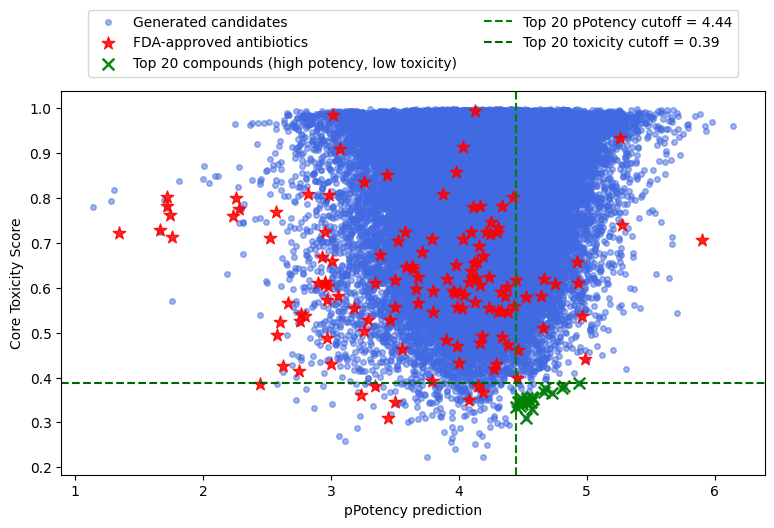

In [68]:
# Selection cutoffs from all generated candidates
xCutoff = cand2DDF["pPotency_prediction"].quantile(0.75)
yCutoff = cand2DDF["ToxicityBurden"].quantile(0.25)

# Keep only compounds in the desired quadrant
optimal2DDF = cand2DDF[
    (cand2DDF["pPotency_prediction"] >= xCutoff) &
    (cand2DDF["ToxicityBurden"] <= yCutoff)
].copy()

# Rank inside that quadrant
optimal2DDF["rankScore2D"] = (
    optimal2DDF["PotencyDesRaw"] * optimal2DDF["ToxicitySafety"]
)

top20_2D_DF = optimal2DDF.sort_values(
    by=["rankScore2D", "pPotency_prediction", "ToxicityBurden"],
    ascending=[False, False, True]
).head(20).copy()

# Display cutoffs from the actual top 20 compounds
xDisplay = top20_2D_DF["pPotency_prediction"].min()
yDisplay = top20_2D_DF["ToxicityBurden"].max()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    cand2DDF["pPotency_prediction"],
    cand2DDF["ToxicityBurden"],
    s=16, alpha=0.5, color="royalblue", label="Generated candidates"
)

ax.scatter(
    refScoreDF["pPotency_prediction"],
    refScoreDF["ToxicityBurden"],
    marker="*", s=90, alpha=0.85, color="red", label="FDA-approved antibiotics"
)

ax.scatter(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["ToxicityBurden"],
    marker="x", s=70, linewidths=1.8, alpha=0.95, color="green",
    label="Top 20 compounds (high potency, low toxicity)"
)

# Plot lines that match the actual highlighted top 20 region
ax.axvline(
    xDisplay,
    linestyle="--",
    linewidth=1.5,
    color="green",
    label=f"Top 20 pPotency cutoff = {xDisplay:.2f}"
)

ax.axhline(
    yDisplay,
    linestyle="--",
    linewidth=1.5,
    color="darkgreen",
    label=f"Top 20 toxicity cutoff = {yDisplay:.2f}"
)

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Core Toxicity Score")

ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(
    saveDir,
    "BacillusAnthracis_pPotency_vs_CoreToxicityMean_top20Highlighted.svg"
)
png_path = os.path.join(
    saveDir,
    "BacillusAnthracis_pPotency_vs_CoreToxicityMean_top20Highlighted.png"
)

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### 2.10 Compute optimal candidates for the 3D case

3D optimization uses:
- `pPotency_prediction` (higher is better)
- `ToxicityBurden` (lower is better)
- `ADMEFeasibility` (higher is better)

We again rank only the Pareto-optimal set.

In [69]:
cand3DDF = candScoreDF.copy()

cand3DDF = cand3DDF[
    cand3DDF[["pPotency_prediction", "ToxicityBurden", "ADMEFeasibility", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

# Data-driven cutoffs from generated candidates
xCutoff = cand3DDF["pPotency_prediction"].quantile(0.75)
yCutoff = cand3DDF["ToxicityBurden"].quantile(0.25)
zCutoff = cand3DDF["ADMEFeasibility"].quantile(0.75)

# Keep only compounds in the desired 3D region
optimal3DDF = cand3DDF[
    (cand3DDF["pPotency_prediction"] >= xCutoff) &
    (cand3DDF["ToxicityBurden"] <= yCutoff) &
    (cand3DDF["ADMEFeasibility"] >= zCutoff)
].copy()

# Rank inside that region
optimal3DDF["OverallPriority3D"] = (
    optimal3DDF["PotencyDesRaw"] *
    optimal3DDF["ToxicitySafety"] *
    optimal3DDF["ADMEFeasibility"]
)

top20_3D_DF = (
    optimal3DDF.sort_values(
        by=["OverallPriority3D", "pPotency_prediction", "ToxicityBurden", "ADMEFeasibility"],
        ascending=[False, False, True, False]
    )
    .head(20)
    .copy()
)

top20_3D_DF["Top20Rank_3D"] = np.arange(1, len(top20_3D_DF) + 1)
top20_3D_DF

,smiles,ATC_code,Drug_Type,source_DataBase,datasetLabel,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,...,mechanisticToxicityScore,absorptionScore,metabolismTransportScore,pkDispositionScore,ToxicitySafety,ToxicityBurden,ADMEFeasibility,PotencyDesRaw,OverallPriority3D,Top20Rank_3D
14322,Cc1cc(C(=O)O)ccc1S(=O)(=O)NCC1(C)CCC(=O)N1,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.601779,1.119041,2.408458,6.795099,0.000025,...,0.784932,0.588435,0.770668,0.922628,0.564069,0.435931,0.730210,0.916667,0.377565,1
25288,COCc1cccc(S(=O)(=O)NCC2(C(=O)O)CCOCC2)c1,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.683652,1.119473,2.489484,6.877819,0.000021,...,0.690923,0.733724,0.444450,0.870187,0.602276,0.397724,0.664421,0.939394,0.375912,2
17528,Cn1ccc(C(=O)N2CCC(C)(NC(=O)CC3(C)CCS(=O)(=O)N3...,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.553625,1.119175,2.360042,6.747208,0.000028,...,0.728635,0.685264,0.616906,0.666047,0.619432,0.380568,0.658355,0.916667,0.373822,3
982,CNS(=O)(=O)CC(=O)N1CCCC1C(=O)NCc1ccco1,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.442532,1.120140,2.247059,6.638006,0.000036,...,0.747337,0.732550,0.480109,0.668476,0.665488,0.334512,0.627860,0.893939,0.373518,4
27418,CCn1cnnc1CNC(=O)c1cc(S(N)(=O)=O)ccc1OC,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.473383,1.118918,2.280303,6.666462,0.000034,...,0.920403,0.824832,0.704780,0.681043,0.550703,0.449297,0.742873,0.909091,0.371911,5
112,CCn1nc(C)c(CNc2ncccc2S(N)(=O)=O)c1C,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.636146,1.118727,2.443441,6.828851,0.000023,...,0.775826,0.839852,0.430779,0.926035,0.563654,0.436346,0.707857,0.916667,0.365737,6
10356,Cc1cc(C(=O)N2CCn3c(C)nnc3C2)cc(S(N)(=O)=O)c1C,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.486447,1.118452,2.294281,6.678614,0.000033,...,0.774627,0.853987,0.561398,0.627172,0.584867,0.415133,0.686401,0.909091,0.364957,7
31946,CCNC(=O)Cn1cnc2c1c(=O)[nH]c(=O)n2C,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.467259,1.118963,2.274091,6.660428,0.000034,...,0.890993,0.694664,0.850882,0.640180,0.555660,0.444340,0.720379,0.909091,0.363896,8
31251,CNS(=O)(=O)c1ccc(CN2CCCC2(C)C(=O)O)cc1,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.482377,1.120119,2.286944,6.677809,0.000033,...,0.884007,0.707384,0.511871,0.617382,0.646359,0.353641,0.616278,0.909091,0.362124,9
8314,CNS(=O)(=O)c1cc(C(=O)NCc2nnc3n2CCC3)n(C)c1,<NA>,Predicted_candidate,Generated,Predicted_candidate,4.550343,1.119746,2.355641,6.745046,0.000028,...,0.881112,0.788661,0.793045,0.409665,0.588119,0.411881,0.649044,0.916667,0.349906,10


### 2.11 Make the 3D plot

Plot contents:
- all generated candidates
- FDA-approved antibiotics as red stars
- Pareto-optimal generated compounds as green X markers

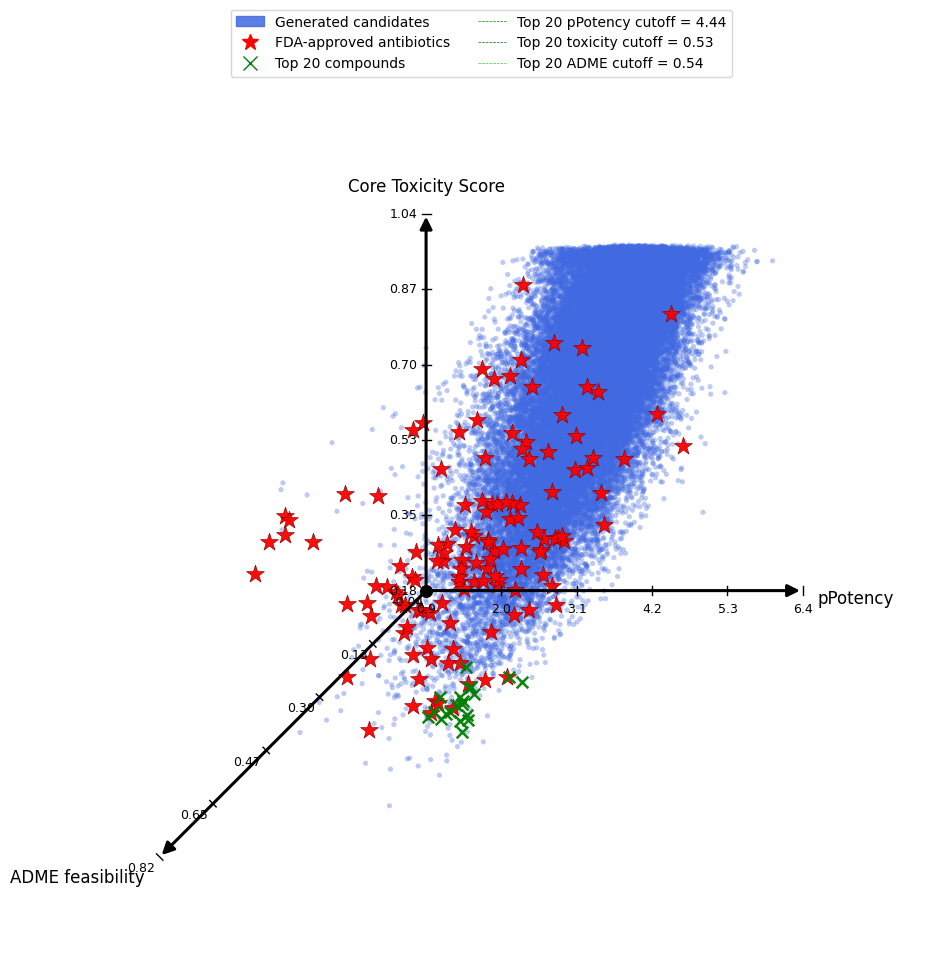

In [87]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# =========================================================
# 1. Real data
# =========================================================
allDF = cand3DDF.copy()
refDF = refScoreDF.copy()
topDF = top20_3D_DF.copy()

xCol = "pPotency_prediction"
yCol = "ADMEFeasibility"   # diagonal axis in this projection
zCol = "ToxicityBurden"    # vertical axis in this projection

allDF = allDF[np.isfinite(allDF[[xCol, yCol, zCol]]).all(axis=1)].copy()
refDF = refDF[np.isfinite(refDF[[xCol, yCol, zCol]]).all(axis=1)].copy()
topDF = topDF[np.isfinite(topDF[[xCol, yCol, zCol]]).all(axis=1)].copy()

# =========================================================
# 2. Real ranges from all plotted data
# =========================================================
xAll = np.concatenate([allDF[xCol].to_numpy(), refDF[xCol].to_numpy(), topDF[xCol].to_numpy()])
yAll = np.concatenate([allDF[yCol].to_numpy(), refDF[yCol].to_numpy(), topDF[yCol].to_numpy()])
zAll = np.concatenate([allDF[zCol].to_numpy(), refDF[zCol].to_numpy(), topDF[zCol].to_numpy()])

def paddedRange(arr, frac=0.05):
    arrMin = np.nanmin(arr)
    arrMax = np.nanmax(arr)
    span = arrMax - arrMin
    pad = span * frac if span > 0 else 1.0
    return arrMin - pad, arrMax + pad

X_MIN, X_MAX = paddedRange(xAll, frac=0.05)
Y_MIN, Y_MAX = paddedRange(yAll, frac=0.05)
Z_MIN, Z_MAX = paddedRange(zAll, frac=0.05)

# =========================================================
# 3. Projection setup
# =========================================================
AXIS_LEN = 1.0
ANG_X = math.radians(0)      # pPotency → right
ANG_Z = math.radians(90)     # Core Toxicity Score → up
ANG_Y = math.radians(225)    # ADME feasibility → lower-left

UX = np.array([math.cos(ANG_X), math.sin(ANG_X)])
UZ = np.array([math.cos(ANG_Z), math.sin(ANG_Z)])
UY = np.array([math.cos(ANG_Y), math.sin(ANG_Y)])
O = np.array([0.0, 0.0])

def dataToCanvas(xVal, yVal, zVal):
    xn = (xVal - X_MIN) / (X_MAX - X_MIN)
    yn = (yVal - Y_MIN) / (Y_MAX - Y_MIN)
    zn = (zVal - Z_MIN) / (Z_MAX - Z_MIN)
    c = O + AXIS_LEN * (xn * UX + yn * UY + zn * UZ)
    return c[0], c[1]

def seriesToCanvas(xSeries, ySeries, zSeries):
    xs, ys = [], []
    for xv, yv, zv in zip(xSeries, ySeries, zSeries):
        cx, cy = dataToCanvas(xv, yv, zv)
        xs.append(cx)
        ys.append(cy)
    return np.array(xs), np.array(ys)

allCX, allCY = seriesToCanvas(allDF[xCol], allDF[yCol], allDF[zCol])
refCX, refCY = seriesToCanvas(refDF[xCol], refDF[yCol], refDF[zCol])
topCX, topCY = seriesToCanvas(topDF[xCol], topDF[yCol], topDF[zCol])

TIP_X = O + AXIS_LEN * UX
TIP_Z = O + AXIS_LEN * UZ
TIP_Y = O + AXIS_LEN * UY

# =========================================================
# 4. Plot
# =========================================================
fig, ax = plt.subplots(figsize=(12, 11), facecolor="white")
ax.set_facecolor("white")
ax.set_aspect("equal")
ax.axis("off")

# =========================================================
# 5. Draw axes only (no gridlines)
# =========================================================
for tip in [TIP_X, TIP_Z, TIP_Y]:
    ax.annotate(
        "",
        xy=tip, xytext=O,
        arrowprops=dict(arrowstyle="-|>", color="black", lw=2.2, mutation_scale=18),
        zorder=5
    )

ax.scatter([O[0]], [O[1]], s=70, c="black", zorder=6)

# =========================================================
# 6. Add simple ticks and tick labels
# =========================================================
def drawAxisTicks(axisVec, valMin, valMax, offsetVec, nTicks=5, fmt="{:.2f}"):
    for i in range(nTicks + 1):
        t = i / nTicks
        pos = O + AXIS_LEN * t * axisVec
        tickStart = pos - 0.012 * np.array([axisVec[1], -axisVec[0]])
        tickEnd   = pos + 0.012 * np.array([axisVec[1], -axisVec[0]])
        ax.plot([tickStart[0], tickEnd[0]], [tickStart[1], tickEnd[1]],
                color="black", lw=1.0, zorder=5)
        val = valMin + t * (valMax - valMin)
        ax.text(pos[0] + offsetVec[0], pos[1] + offsetVec[1],
                fmt.format(val), fontsize=9, color="black",
                ha="center", va="center", zorder=6)

drawAxisTicks(UX, X_MIN, X_MAX, offsetVec=np.array([0.00, -0.05]), nTicks=5, fmt="{:.1f}")
drawAxisTicks(UZ, Z_MIN, Z_MAX, offsetVec=np.array([-0.06, 0.00]), nTicks=5, fmt="{:.2f}")
drawAxisTicks(UY, Y_MIN, Y_MAX, offsetVec=np.array([-0.05, -0.03]), nTicks=5, fmt="{:.2f}")

# =========================================================
# 7. Scatter layers
# =========================================================
# Generated candidates as small dots
ax.scatter(
    allCX, allCY,
    c="royalblue", alpha=0.35, s=14,
    marker="o", edgecolors="none", zorder=2
)

ax.scatter(
    refCX, refCY,
    c="red", marker="*", s=180,
    edgecolors="darkred", linewidths=0.5,
    alpha=0.95, zorder=4
)

ax.scatter(
    topCX, topCY,
    color="green",
    marker="x",
    s=70,
    linewidths=1.8,
    alpha=0.95,
    zorder=5
)

'''
# Optional rank labels
if "Top20Rank_3D" in topDF.columns:
    for _, row in topDF.iterrows():
        cx, cy = dataToCanvas(row[xCol], row[yCol], row[zCol])
        ax.text(cx + 0.012, cy + 0.012, str(int(row["Top20Rank_3D"])),
                fontsize=8, color="green", zorder=6)
'''
# =========================================================
# 8. Cutoffs from actual top 20 boundary
# =========================================================
xDisplay = topDF[xCol].min()
zDisplay = topDF[zCol].max()   # Core Toxicity Score cutoff
yDisplay = topDF[yCol].min()   # ADME cutoff
'''
# pPotency cutoff guide
p1 = np.array(dataToCanvas(xDisplay, Y_MIN, Z_MIN))
p2 = np.array(dataToCanvas(xDisplay, Y_MIN, Z_MAX))
ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
        linestyle="--", linewidth=1.5, color="green", zorder=3)

# Toxicity cutoff guide
p3 = np.array(dataToCanvas(X_MIN, Y_MIN, zDisplay))
p4 = np.array(dataToCanvas(X_MAX, Y_MIN, zDisplay))
ax.plot([p3[0], p4[0]], [p3[1], p4[1]],
        linestyle="--", linewidth=1.5, color="darkgreen", zorder=3)

# ADME cutoff guide
p5 = np.array(dataToCanvas(X_MIN, yDisplay, Z_MIN))
p6 = np.array(dataToCanvas(X_MAX, yDisplay, Z_MIN))
ax.plot([p5[0], p6[0]], [p5[1], p6[1]],
        linestyle="--", linewidth=1.5, color="limegreen", zorder=3)
'''
# =========================================================
# 9. Simple axis labels at the axis tips
# =========================================================
ax.text(TIP_X[0] + 0.04, TIP_X[1] - 0.02, "pPotency",
        fontsize=12, color="black", ha="left", va="center")

ax.text(TIP_Z[0], TIP_Z[1] + 0.05, "Core Toxicity Score",
        fontsize=12, color="black", ha="center", va="bottom")

ax.text(TIP_Y[0] - 0.04, TIP_Y[1] - 0.03, "ADME feasibility",
        fontsize=12, color="black", ha="right", va="top")

# =========================================================
# 10. Autoscale
# =========================================================
plotX = np.concatenate([allCX, refCX, topCX, [TIP_X[0], TIP_Y[0], TIP_Z[0]]])
plotY = np.concatenate([allCY, refCY, topCY, [TIP_X[1], TIP_Y[1], TIP_Z[1]]])

pad = 0.30
ax.set_xlim(plotX.min() - pad, plotX.max() + pad)
ax.set_ylim(plotY.min() - pad, plotY.max() + pad)

# =========================================================
# 11. Legend with all cutoffs
# =========================================================
bluePatch = mpatches.Patch(
    facecolor="royalblue",
    edgecolor="royalblue",
    alpha=0.85,
    label="Generated candidates"
)
redStar = mlines.Line2D([], [], color="red", marker="*", linestyle="None",
                        markersize=12, label="FDA-approved antibiotics")
greenX = mlines.Line2D([], [], color="green", marker="x", linestyle="None",
                       markersize=10, label="Top 20 compounds")

potLine = mlines.Line2D([], [], color="green", linestyle="--", linewidth=0.5,
                        label=f"Top 20 pPotency cutoff = {xDisplay:.2f}")
toxLine = mlines.Line2D([], [], color="darkgreen", linestyle="--", linewidth=0.5,
                        label=f"Top 20 toxicity cutoff = {zDisplay:.2f}")
admeLine = mlines.Line2D([], [], color="limegreen", linestyle="--", linewidth=0.5,
                         label=f"Top 20 ADME cutoff = {yDisplay:.2f}")

ax.legend(
    handles=[bluePatch, redStar, greenX, potLine, toxLine, admeLine],
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=True
)

# =========================================================
# 12. Save
# =========================================================
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(
    saveDir,
    "BacillusAnthracis_customProjected3D_top20.svg"
)
png_path = os.path.join(
    saveDir,
    "BacillusAnthracis_customProjected3D_top20.png"
)

plt.savefig(svg_path, format="svg", dpi=600, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.savefig(png_path, format="png", dpi=600, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## 12. Save the top 20 compounds for both cases

We save:
- the top 20 optimal compounds from the 2D case
- the top 20 optimal compounds from the 3D case
- a combined file with a `selectionCase` column

In [83]:
top20_2D_exportCols = [
    "selectionCase",
    "Top20Rank_2D",
    "smiles",
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "ToxicityBurden",
    "ToxicitySafety",
    "OverallPriority2D",
    "QED",
]

top20_3D_exportCols = [
    "selectionCase",
    "Top20Rank_3D",
    "smiles",
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "ToxicityBurden",
    "ToxicitySafety",
    "ADMEFeasibility",
    "OverallPriority3D",
    "QED",
]

top20_2D_exportDF = top20_2D_DF.copy()
top20_2D_exportDF["selectionCase"] = "2D_pPotency_vs_Toxicity"
top20_2D_exportDF = top20_2D_exportDF[
    [colName for colName in top20_2D_exportCols if colName in top20_2D_exportDF.columns]
].copy()

top20_3D_exportDF = top20_3D_DF.copy()
top20_3D_exportDF["selectionCase"] = "3D_pPotency_vs_Toxicity_vs_ADME"
top20_3D_exportDF = top20_3D_exportDF[
    [colName for colName in top20_3D_exportCols if colName in top20_3D_exportDF.columns]
].copy()

toxicityTop20Path = os.path.abspath(
    os.path.join(saveDir, "BacillusAnthracisVirus_wART_BuyableDataset_wToxicity_top20.csv")
)
admetTop20Path = os.path.abspath(
    os.path.join(saveDir, "BacillusAnthracisVirus_wART_BuyableDataset_wADMET_top20.csv")
)

top20_2D_exportDF.to_csv(toxicityTop20Path, index=False)
top20_3D_exportDF.to_csv(admetTop20Path, index=False)

print("Saved:")
print(f"- {toxicityTop20Path}")
print(f"- {admetTop20Path}")

Saved:
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW_allDB/BacillusAnthracisVirus_wART_BuyableDataset_wToxicity_top20.csv
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW_allDB/BacillusAnthracisVirus_wART_BuyableDataset_wADMET_top20.csv


### Retain potency predictions along with toxicity, mechanistic, and ADME-related endpoints

In [222]:
# Potency-related columns
potencyCols = [
    "SMILES",
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.columns
]

BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.shape)
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.head()

Filtered dataframe shape: (46939, 41)


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,4.169872,1.119030,1.976573,6.363170,0.000068,4.333413e-07,0.010554,0.727207,0.499834,...,0.995333,0.889405,0.556546,0.952716,0.115046,0.826106,0.134753,0.108329,0.760515,0.592387
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,4.429163,1.118621,2.236666,6.621661,0.000037,2.389674e-07,0.005799,0.204361,0.089317,...,0.949429,0.973717,0.730353,0.310337,0.474573,0.095773,0.269003,0.008871,0.549327,0.044814
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,4.621105,1.118405,2.429031,6.813180,0.000024,1.537519e-07,0.003724,0.312347,0.181800,...,0.925759,0.893960,0.012659,0.420566,0.319929,0.083655,0.081229,0.007386,0.524254,0.148049
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,4.521367,1.120633,2.324927,6.717807,0.000030,1.915106e-07,0.004732,0.049025,0.109170,...,0.842507,0.874405,0.007123,0.112539,0.517903,0.071035,0.050239,0.037251,0.335556,0.179092
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.643503,1.119350,2.449576,6.837430,0.000023,1.454020e-07,0.003552,0.008243,0.031413,...,0.110157,0.798915,0.050893,0.081878,0.708961,0.196669,0.026894,0.021543,0.313643,0.009893


### Compute DrugBank `reference percentile` by comparing with FDA approved `Antibiotics`

In [225]:
column_list = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.columns.tolist()
print(column_list)

['SMILES', 'pPotency_prediction', 'pPotency_std', 'pPotency_lower_95CI', 'pPotency_upper_95CI', 'IC50(M)_prediction', 'IC50(M)_lower_95CI', 'IC50(M)_upper_95CI', 'AMES', 'hERG', 'DILI', 'ClinTox', 'Carcinogens_Lagunin', 'Skin_Reaction', 'LD50_Zhu', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'NR-AR-LBD', 'NR-AR', 'NR-AhR', 'NR-Aromatase', 'NR-ER-LBD', 'NR-ER', 'NR-PPAR-gamma', 'BBB_Martins', 'Pgp_Broccatelli', 'Caco2_Wang', 'HIA_Hou', 'PAMPA_NCATS', 'Bioavailability_Ma', 'CYP1A2_Veith', 'CYP2C19_Veith', 'CYP2C9_Substrate_CarbonMangels', 'CYP2C9_Veith', 'CYP2D6_Substrate_CarbonMangels', 'CYP2D6_Veith', 'CYP3A4_Substrate_CarbonMangels', 'CYP3A4_Veith']


In [230]:
def addReferencePercentiles(queryDF, referenceDF, propertyCols, suffix):
    outputDF = queryDF.copy()

    for col in propertyCols:
        refVals = pd.to_numeric(referenceDF[col], errors="coerce").dropna().values

        if len(refVals) == 0:
            outputDF[f"{col}_{suffix}"] = np.nan
            continue

        outputDF[f"{col}_{suffix}"] = pd.to_numeric(
            outputDF[col], errors="coerce"
        ).apply(
            lambda x: percentileofscore(refVals, x, kind="weak")
            if pd.notna(x) else np.nan
        )

    return outputDF

selectedCols = coreToxicityCols + mechanisticAlertCols + admeLiabilityCols
print(f"Number of shared selected columns: {len(selectedCols)}")

BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_pct = addReferencePercentiles(
    queryDF=BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity,
    referenceDF=drugBankDrug_FDAapproved_antibiotic_wToxicity,
    propertyCols=selectedCols,
    suffix="Drugbank_percentile"
)
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_pct

Number of shared selected columns: 33


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS_Drugbank_percentile,Bioavailability_Ma_Drugbank_percentile,CYP1A2_Veith_Drugbank_percentile,CYP2C19_Veith_Drugbank_percentile,CYP2C9_Substrate_CarbonMangels_Drugbank_percentile,CYP2C9_Veith_Drugbank_percentile,CYP2D6_Substrate_CarbonMangels_Drugbank_percentile,CYP2D6_Veith_Drugbank_percentile,CYP3A4_Substrate_CarbonMangels_Drugbank_percentile,CYP3A4_Veith_Drugbank_percentile
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,4.169872,1.119030,1.976573,6.363170,0.000068,4.333413e-07,0.010554,0.727207,0.499834,...,100.000000,78.787879,99.242424,100.000000,47.727273,100.000000,99.242424,96.969697,99.242424,94.696970
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,4.429163,1.118621,2.236666,6.621661,0.000037,2.389674e-07,0.005799,0.204361,0.089317,...,100.000000,98.484848,99.242424,99.242424,95.454545,97.727273,100.000000,40.151515,84.090909,71.969697
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,4.621105,1.118405,2.429031,6.813180,0.000024,1.537519e-07,0.003724,0.312347,0.181800,...,100.000000,79.545455,84.090909,100.000000,89.393939,96.969697,93.939394,35.606061,80.303030,87.878788
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,4.521367,1.120633,2.324927,6.717807,0.000030,1.915106e-07,0.004732,0.049025,0.109170,...,96.212121,77.272727,71.212121,94.696970,98.484848,96.212121,86.363636,83.333333,65.151515,88.636364
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.643503,1.119350,2.449576,6.837430,0.000023,1.454020e-07,0.003552,0.008243,0.031413,...,46.212121,64.393939,96.212121,92.424242,100.000000,98.484848,57.575758,66.666667,59.848485,40.909091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46934,CNc1nc(Nc2ccccc2)nc2ccccc12,4.172397,1.119743,1.977701,6.367093,0.000067,4.294444e-07,0.010527,0.670750,0.818788,...,100.000000,90.151515,100.000000,100.000000,80.303030,97.727273,100.000000,100.000000,84.090909,99.242424
46935,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.008815,1.118924,1.815724,6.201907,0.000098,6.281934e-07,0.015285,0.873983,0.718039,...,100.000000,100.000000,100.000000,100.000000,80.303030,97.727273,100.000000,99.242424,87.121212,97.727273
46936,CNc1nc(Nc2ccccc2F)nc2ccccc12,4.196679,1.119485,2.002488,6.390870,0.000064,4.065651e-07,0.009943,0.844169,0.862255,...,100.000000,100.000000,100.000000,100.000000,89.393939,96.969697,100.000000,100.000000,90.151515,100.000000
46937,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.423288,1.119218,2.229622,6.616955,0.000038,2.415712e-07,0.005894,0.767482,0.514581,...,100.000000,96.969697,100.000000,100.000000,50.000000,97.727273,100.000000,99.242424,90.151515,93.939394


### Histogram of percentile columns

This shows whether the candidate set is generally worse or better than FDA-approved antibiotics for each endpoint

In [234]:
# Core toxicity percentile columns
coreToxicityPctCols = [
    f"{col}_Drugbank_percentile" for col in coreToxicityCols
    if f"{col}_Drugbank_percentile" in BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_pct.columns
]

print(coreToxicityPctCols)

['AMES_Drugbank_percentile', 'hERG_Drugbank_percentile', 'DILI_Drugbank_percentile', 'ClinTox_Drugbank_percentile', 'Carcinogens_Lagunin_Drugbank_percentile', 'Skin_Reaction_Drugbank_percentile', 'LD50_Zhu_Drugbank_percentile']


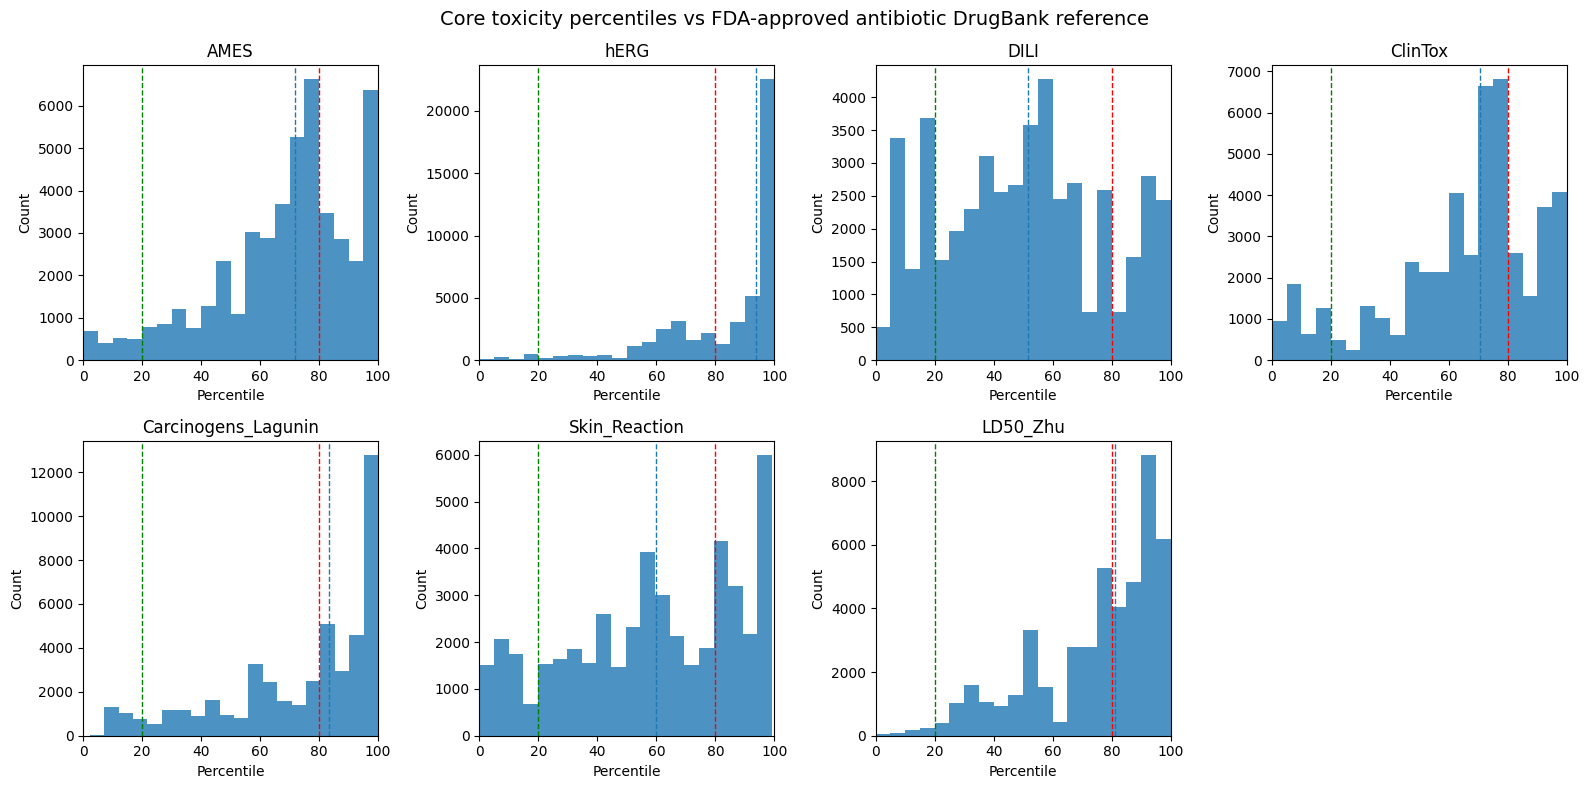

In [238]:
DF = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_pct.copy()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(coreToxicityPctCols):
    vals = pd.to_numeric(DF[col], errors="coerce").dropna()

    axes[idx].hist(vals, bins=20, alpha=0.8)
    axes[idx].set_title(col.replace("_Drugbank_percentile", ""))
    axes[idx].set_xlim(0, 100)
    axes[idx].set_xlabel("Percentile")
    axes[idx].set_ylabel("Count")
    axes[idx].axvline(vals.median(), linestyle="--", linewidth=1)
    axes[idx].axvline(x=20, linestyle="--", c='g', linewidth=1)
    axes[idx].axvline(x=80, linestyle="--", c='r', linewidth=1)

# Hide unused subplot
for idx in range(len(coreToxicityPctCols), len(axes)):
    axes[idx].axis("off")

fig.suptitle("Core toxicity percentiles vs FDA-approved antibiotic DrugBank reference", fontsize=14)
plt.tight_layout()
plt.show()

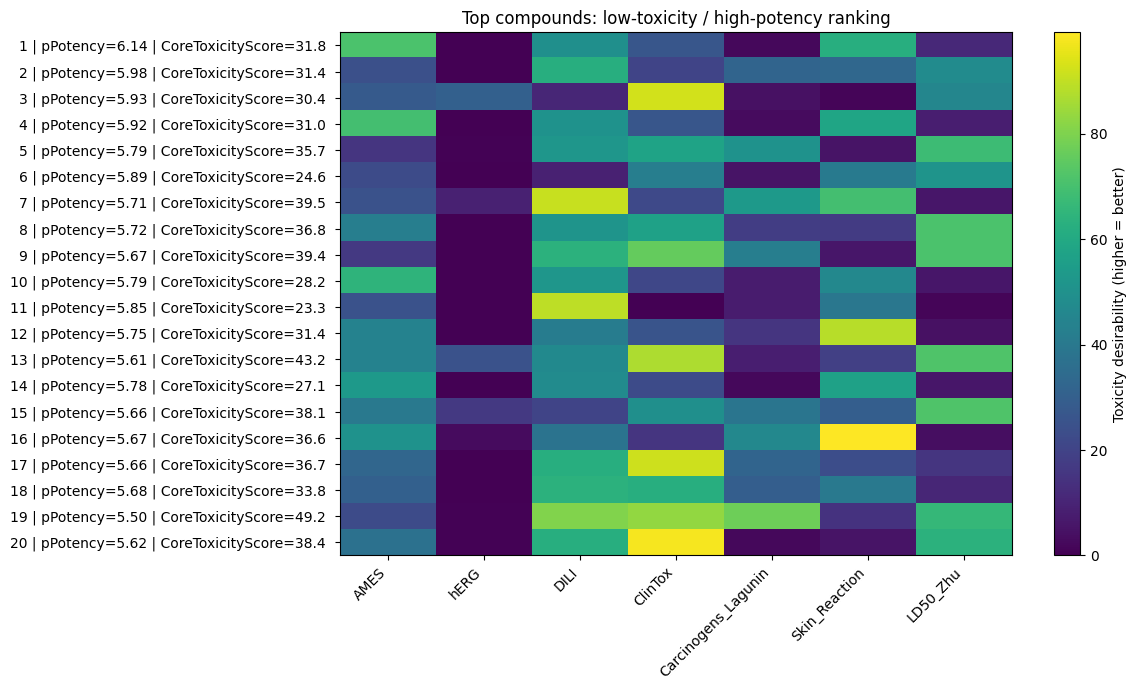

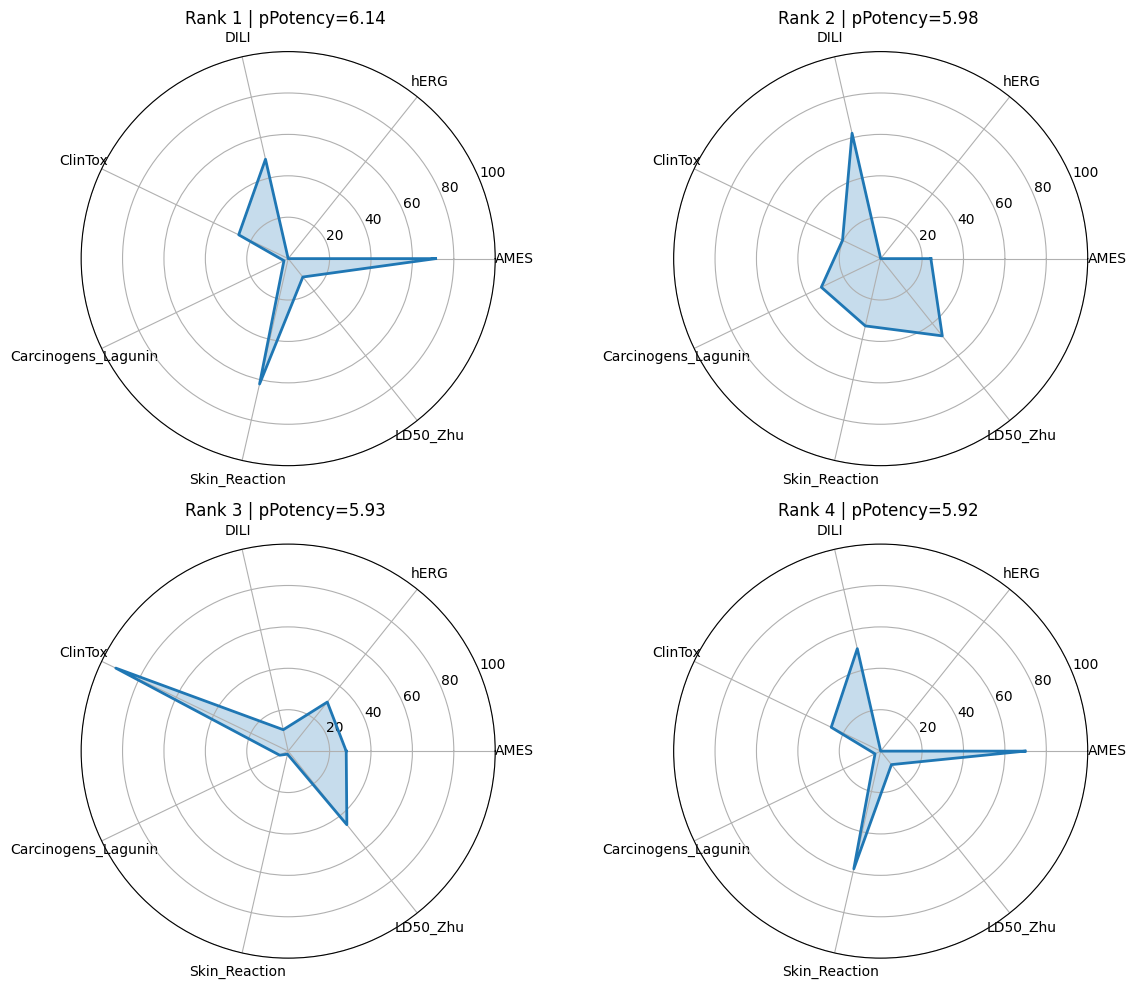

In [242]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plotCoreToxicityHeatmapAndRadar(
    DF,
    coreToxicityCols=None,
    percentileSuffix="_Drugbank_percentile",
    potencyCol="pPotency_prediction",
    smilesCol="SMILES",
    potencyThreshold=5.0,
    topN=20,
    radarTopN=4,
    toxicityWeight=0.6,
    potencyWeight=0.4,
    figsizeHeatmap=(12, 7),
    figsizeRadar=(12, 10),
):
    """
    Rank compounds so that:
      - lower toxicity percentile is better
      - higher potency is better

    Then generate:
      1. Heatmap of top compounds
      2. Radar plots for top compounds

    Returns
    -------
    resultDF : pandas.DataFrame
        Ranked dataframe used for plotting.
    """

    if coreToxicityCols is None:
        coreToxicityCols = [
            "AMES",
            "hERG",
            "DILI",
            "ClinTox",
            "Carcinogens_Lagunin",
            "Skin_Reaction",
            "LD50_Zhu",
        ]

    workDF = DF.copy()

    percentileCols = [
        f"{col}{percentileSuffix}"
        for col in coreToxicityCols
        if f"{col}{percentileSuffix}" in workDF.columns
    ]

    if len(percentileCols) == 0:
        raise ValueError(
            f"No percentile columns found with suffix '{percentileSuffix}'."
        )

    if potencyCol not in workDF.columns:
        raise ValueError(f"Potency column '{potencyCol}' not found in dataframe.")

    # Convert relevant columns to numeric
    for col in percentileCols + [potencyCol]:
        workDF[col] = pd.to_numeric(workDF[col], errors="coerce")

    # Filter by potency threshold
    if potencyThreshold is not None:
        workDF = workDF.loc[workDF[potencyCol] >= potencyThreshold].copy()

    # Remove rows with missing values in required columns
    workDF = workDF.dropna(subset=percentileCols + [potencyCol]).reset_index(drop=True)

    if len(workDF) == 0:
        raise ValueError("No rows remain after filtering and NaN removal.")

    # ---------------------------------------------------
    # 1. Toxicity desirability score
    # Lower DrugBank percentile = lower toxicity = better
    # So convert with: desirability = 100 - percentile
    # ---------------------------------------------------
    toxicityDesirabilityCols = []
    for col in percentileCols:
        newCol = col.replace(percentileSuffix, "_desirability")
        workDF[newCol] = 100.0 - workDF[col]
        toxicityDesirabilityCols.append(newCol)

    workDF["CoreToxicityScore"] = workDF[toxicityDesirabilityCols].mean(axis=1)

    # ---------------------------------------------------
    # 2. Potency desirability score
    # Higher pPotency_prediction = better
    # Normalize to 0-100
    # ---------------------------------------------------
    potencyMin = workDF[potencyCol].min()
    potencyMax = workDF[potencyCol].max()

    if potencyMax > potencyMin:
        workDF["PotencyScore"] = 100.0 * (
            (workDF[potencyCol] - potencyMin) / (potencyMax - potencyMin)
        )
    else:
        workDF["PotencyScore"] = 100.0

    # ---------------------------------------------------
    # 3. Combined desirability
    # ---------------------------------------------------
    workDF["CombinedDrugScore"] = (
        toxicityWeight * workDF["CoreToxicityScore"]
        + potencyWeight * workDF["PotencyScore"]
    )

    # Rank top compounds
    resultDF = (
        workDF.sort_values(
            ["CombinedDrugScore", "CoreToxicityScore", potencyCol],
            ascending=[False, False, False]
        )
        .head(topN)
        .reset_index(drop=True)
    )

    # ---------------------------------------------------
    # 4. Heatmap
    # Use desirability values so higher = better everywhere
    # ---------------------------------------------------
    heatmapDF = resultDF[toxicityDesirabilityCols].copy()
    heatmapDF.columns = coreToxicityCols[:len(heatmapDF.columns)]

    rowLabels = []
    for idx, row in resultDF.iterrows():
        if smilesCol in resultDF.columns:
            smi = str(row[smilesCol])
            smiShort = smi[:18] + "..." if len(smi) > 18 else smi
            label = (
                f"{idx+1} | pPotency={row[potencyCol]:.2f} | "
                f"CoreToxicityScore={row['CoreToxicityScore']:.1f} "
            )
        else:
            label = (
                f"{idx+1} | pPotency={row[potencyCol]:.2f} | "
                f"CoreToxicityScore={row['CoreToxicityScore']:.1f}"
            )
        rowLabels.append(label)

    plt.figure(figsize=figsizeHeatmap)
    plt.imshow(heatmapDF, aspect="auto")
    plt.colorbar(label="Toxicity desirability (higher = better)")
    plt.xticks(
        range(len(heatmapDF.columns)),
        heatmapDF.columns,
        rotation=45,
        ha="right",
    )
    plt.yticks(range(len(resultDF)), rowLabels)
    plt.title("Top compounds: low-toxicity / high-potency ranking")
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------
    # 5. Radar plots
    # ---------------------------------------------------
    radarDF = resultDF.head(radarTopN).copy()
    radarCols = toxicityDesirabilityCols
    radarLabels = coreToxicityCols[:len(radarCols)]

    nPlots = len(radarDF)
    nCols = 2
    nRows = int(np.ceil(nPlots / nCols))

    angles = np.linspace(0, 2 * np.pi, len(radarCols), endpoint=False).tolist()
    angles += angles[:1]

    fig, axes = plt.subplots(
        nRows, nCols, figsize=figsizeRadar, subplot_kw=dict(polar=True)
    )
    axes = np.array(axes).reshape(-1)

    for plotIdx in range(len(axes)):
        ax = axes[plotIdx]

        if plotIdx < nPlots:
            row = radarDF.iloc[plotIdx]
            values = [row[col] for col in radarCols]
            values += values[:1]

            ax.plot(angles, values, linewidth=2)
            ax.fill(angles, values, alpha=0.25)
            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(radarLabels)
            ax.set_ylim(0, 100)
            ax.set_title(
                f"Rank {plotIdx+1} | pPotency={row[potencyCol]:.2f} ",
                pad=20,
            )
        else:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

    return resultDF


topCompoundsDF = plotCoreToxicityHeatmapAndRadar(
    DF=BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_pct,
    coreToxicityCols=[
        "AMES",
        "hERG",
        "DILI",
        "ClinTox",
        "Carcinogens_Lagunin",
        "Skin_Reaction",
        "LD50_Zhu"
    ],
    percentileSuffix="_Drugbank_percentile",
    potencyCol="pPotency_prediction",
    smilesCol="SMILES",
    potencyThreshold=5.0,
    topN=20,
    radarTopN=4,
    toxicityWeight=0.5,
    potencyWeight=0.5
)

In [ ]:
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.columns

## ADMET Multiparameter optimization (MPO) scoring logic

This workflow builds three **normalized 0–1 risk scores** for each molecule using FDA-approved antibiotics as the reference set.

First, the ADMET endpoints are grouped into:
- **Core toxicity**: direct toxicity-related endpoints such as AMES, hERG, DILI, ClinTox, carcinogenicity, skin reaction, and LD50.
- **Mechanistic alerts**: stress-response and nuclear-receptor alert endpoints.
- **ADME**: transporter, metabolism, absorption, and bioavailability endpoints.

For each endpoint, the FDA-approved antibiotic set is used to compute a **reference range** based on the 5th and 95th percentiles.  
Each candidate endpoint value is then converted to a **normalized risk score between 0 and 1**:
- **0 = better / lower risk**
- **1 = worse / higher risk**

For **lower-is-better** endpoints, the raw value is scaled directly within the FDA reference range.  
For **higher-is-better** endpoints, the scale is inverted so that all final risk values have the same interpretation: **lower is better**.

Within each category, the normalized endpoint risks are combined using an **equal-weighted mean**:
- `Core_Toxicity_MeanScore`
- `Mechanistic_Alert_MeanScore`
- `ADME_MeanScore`

In [184]:
# =========================================================
# 1. Antibiotic-specific endpoint configuration
# =========================================================

CORE_TOXICITY_COLS = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu",
]

MECHANISTIC_ALERT_COLS = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma",
]

ADME_LOWER_IS_BETTER_COLS = [
    "Pgp_Broccatelli",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith",
]

ADME_HIGHER_IS_BETTER_COLS = [
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
]


# =========================================================
# 2. Default antibiotic-specific weights
# =========================================================

DEFAULT_CORE_WEIGHTS = {
    "hERG": 1.5,
    "DILI": 1.5,
    "ClinTox": 1.5,
    "AMES": 1.2,
    "Carcinogens_Lagunin": 1.2,
    "LD50_Zhu": 1.0,
    "Skin_Reaction": 0.5,
}

DEFAULT_MECHANISTIC_WEIGHTS = {
    col: 0.5 for col in MECHANISTIC_ALERT_COLS
}

DEFAULT_ADME_WEIGHTS_ORAL_LOWER = {
    "Pgp_Broccatelli": 0.8,
    "CYP1A2_Veith": 0.4,
    "CYP2C19_Veith": 0.4,
    "CYP2C9_Substrate_CarbonMangels": 0.3,
    "CYP2C9_Veith": 0.4,
    "CYP2D6_Substrate_CarbonMangels": 0.3,
    "CYP2D6_Veith": 0.4,
    "CYP3A4_Substrate_CarbonMangels": 0.5,
    "CYP3A4_Veith": 0.6,
}

DEFAULT_ADME_WEIGHTS_ORAL_HIGHER = {
    "Caco2_Wang": 1.0,
    "HIA_Hou": 1.2,
    "PAMPA_NCATS": 0.7,
    "Bioavailability_Ma": 1.0,
}

DEFAULT_ADME_WEIGHTS_IV_LOWER = {
    "Pgp_Broccatelli": 0.8,
    "CYP1A2_Veith": 0.4,
    "CYP2C19_Veith": 0.4,
    "CYP2C9_Substrate_CarbonMangels": 0.3,
    "CYP2C9_Veith": 0.4,
    "CYP2D6_Substrate_CarbonMangels": 0.3,
    "CYP2D6_Veith": 0.4,
    "CYP3A4_Substrate_CarbonMangels": 0.5,
    "CYP3A4_Veith": 0.6,
}

DEFAULT_ADME_WEIGHTS_IV_HIGHER = {
    "Caco2_Wang": 0.3,
    "HIA_Hou": 0.3,
    "PAMPA_NCATS": 0.2,
    "Bioavailability_Ma": 0.3,
}

DEFAULT_OVERALL_GROUP_WEIGHTS = {
    "CoreToxicityScore": 1.5,
    "MechanisticAlertScore": 0.6,
    "AntibioticADMEScore": 1.0,
}

EPSILON = 1e-6


# =========================================================
# 3. Utility helpers
# =========================================================

def clip01(series):
    return series.clip(lower=0.0, upper=1.0)


def toNumericSeries(series):
    return pd.to_numeric(series, errors="coerce")


def availableColumns(df, columns):
    return [col for col in columns if col in df.columns]


def buildReferenceStats(referenceDF, allEndpointCols, lowerQuantile=0.10, upperQuantile=0.90):
    """
    Build empirical reference statistics from approved antibiotics.
    These stats are later used to convert raw endpoints into desirability scores.
    """
    statsDict = {}

    for col in allEndpointCols:
        if col not in referenceDF.columns:
            continue

        series = toNumericSeries(referenceDF[col]).dropna()
        if len(series) == 0:
            continue

        qLow = series.quantile(lowerQuantile)
        qMed = series.quantile(0.50)
        qHigh = series.quantile(upperQuantile)

        statsDict[col] = {
            "qLow": qLow,
            "qMed": qMed,
            "qHigh": qHigh,
        }

    return statsDict


def logisticLowerIsBetter(series, endpointName, referenceStats, steepness=6.0):
    """
    Lower value -> higher desirability.
    Output in [0, 1].
    """
    if endpointName not in referenceStats:
        return pd.Series(np.nan, index=series.index)

    qLow = referenceStats[endpointName]["qLow"]
    qHigh = referenceStats[endpointName]["qHigh"]

    if pd.isna(qLow) or pd.isna(qHigh) or qHigh == qLow:
        return pd.Series(0.5, index=series.index)

    midpoint = 0.5 * (qLow + qHigh)
    scale = max((qHigh - qLow) / 2.0, 1e-8)

    z = (series - midpoint) / scale
    desirability = 1.0 / (1.0 + np.exp(steepness * z))
    return clip01(pd.Series(desirability, index=series.index))


def logisticHigherIsBetter(series, endpointName, referenceStats, steepness=6.0):
    """
    Higher value -> higher desirability.
    Output in [0, 1].
    """
    if endpointName not in referenceStats:
        return pd.Series(np.nan, index=series.index)

    qLow = referenceStats[endpointName]["qLow"]
    qHigh = referenceStats[endpointName]["qHigh"]

    if pd.isna(qLow) or pd.isna(qHigh) or qHigh == qLow:
        return pd.Series(0.5, index=series.index)

    midpoint = 0.5 * (qLow + qHigh)
    scale = max((qHigh - qLow) / 2.0, 1e-8)

    z = (series - midpoint) / scale
    desirability = 1.0 / (1.0 + np.exp(-steepness * z))
    return clip01(pd.Series(desirability, index=series.index))


def weightedGeometricMean(df, weightsDict, epsilon=EPSILON):
    """
    Weighted geometric mean with row-wise missing-value handling.
    Only available columns contribute to each row.
    """
    cols = [col for col in weightsDict if col in df.columns]
    if len(cols) == 0:
        return pd.Series(np.nan, index=df.index)

    weights = pd.Series({col: float(weightsDict[col]) for col in cols}, dtype=float)
    numericDF = df[cols].apply(pd.to_numeric, errors="coerce")

    availableMask = numericDF.notna()
    weightedLogDF = np.log(numericDF.clip(lower=epsilon)).mul(weights, axis=1)

    numerator = weightedLogDF.where(availableMask).sum(axis=1, skipna=True)
    denominator = availableMask.mul(weights, axis=1).sum(axis=1)

    out = np.exp(numerator / denominator)
    out[denominator == 0] = np.nan
    return out


def computeCoverage(df, weightsDict):
    """
    Weighted coverage fraction in [0, 1].
    Measures how much of the intended score was actually observed.
    """
    cols = [col for col in weightsDict if col in df.columns]
    if len(cols) == 0:
        return pd.Series(np.nan, index=df.index)

    weights = pd.Series({col: float(weightsDict[col]) for col in cols}, dtype=float)
    numericDF = df[cols].apply(pd.to_numeric, errors="coerce")
    observedWeight = numericDF.notna().mul(weights, axis=1).sum(axis=1)
    totalWeight = weights.sum()

    return observedWeight / totalWeight if totalWeight > 0 else pd.Series(np.nan, index=df.index)


def empiricalPercentileFromReference(candidateSeries, referenceSeries):
    """
    Return percentile rank relative to reference values.
    Used for interpretability, following the contextualization logic of ADMET-AI.
    """
    referenceValues = toNumericSeries(referenceSeries).dropna().values
    if len(referenceValues) == 0:
        return pd.Series(np.nan, index=candidateSeries.index)

    candidateValues = toNumericSeries(candidateSeries)
    percentiles = []

    for value in candidateValues:
        if pd.isna(value):
            percentiles.append(np.nan)
        else:
            percentile = 100.0 * np.mean(referenceValues <= value)
            percentiles.append(percentile)

    return pd.Series(percentiles, index=candidateSeries.index)


# =========================================================
# 4. Desirability builders for endpoint groups
# =========================================================

def buildCoreToxicityDesirabilityDF(df, referenceStats, coreWeights):
    outDF = pd.DataFrame(index=df.index)
    for col in coreWeights:
        if col in df.columns:
            outDF[col] = logisticLowerIsBetter(
                toNumericSeries(df[col]),
                col,
                referenceStats
            )
    return outDF


def buildMechanisticDesirabilityDF(df, referenceStats, mechanisticWeights):
    outDF = pd.DataFrame(index=df.index)
    for col in mechanisticWeights:
        if col in df.columns:
            outDF[col] = logisticLowerIsBetter(
                toNumericSeries(df[col]),
                col,
                referenceStats
            )
    return outDF


def buildAdmeDesirabilityDF(df, referenceStats, admeLowerWeights, admeHigherWeights):
    outDF = pd.DataFrame(index=df.index)

    for col in admeLowerWeights:
        if col in df.columns:
            outDF[col] = logisticLowerIsBetter(
                toNumericSeries(df[col]),
                col,
                referenceStats
            )

    for col in admeHigherWeights:
        if col in df.columns:
            outDF[col] = logisticHigherIsBetter(
                toNumericSeries(df[col]),
                col,
                referenceStats
            )

    return outDF


# =========================================================
# 5. Main scoring function
# =========================================================

def addAntibioticSpecificAdmetScores(
    candidateDF,
    referenceDF,
    route="oral",
    includeBBB=False,
    coreWeights=None,
    mechanisticWeights=None,
    admeLowerWeights=None,
    admeHigherWeights=None,
    overallGroupWeights=None,
    lowerQuantile=0.10,
    upperQuantile=0.90,
    coverageThreshold=0.70,
):
    """
    Build three antibiotic-specific grouped scores:
      1. CoreToxicityScore
      2. MechanisticAlertScore
      3. AntibioticADMEScore

    and an optional:
      4. OverallAntibioticADMETScore

    All grouped scores are desirability-based and lie approximately in [0, 1].

    Also adds risk-like columns for direct plotting:
      - Core_Toxicity_MeanScore
      - Mechanistic_Alert_MeanScore
      - ADME_MeanScore

    For these derived columns, lower is better.
    """

    candidateDF = candidateDF.copy()
    referenceDF = referenceDF.copy()

    if includeBBB:
        # Optional extension point if you want BBB included later.
        pass

    if coreWeights is None:
        coreWeights = DEFAULT_CORE_WEIGHTS.copy()

    if mechanisticWeights is None:
        mechanisticWeights = DEFAULT_MECHANISTIC_WEIGHTS.copy()

    if route.lower() == "oral":
        if admeLowerWeights is None:
            admeLowerWeights = DEFAULT_ADME_WEIGHTS_ORAL_LOWER.copy()
        if admeHigherWeights is None:
            admeHigherWeights = DEFAULT_ADME_WEIGHTS_ORAL_HIGHER.copy()
    elif route.lower() == "iv":
        if admeLowerWeights is None:
            admeLowerWeights = DEFAULT_ADME_WEIGHTS_IV_LOWER.copy()
        if admeHigherWeights is None:
            admeHigherWeights = DEFAULT_ADME_WEIGHTS_IV_HIGHER.copy()
    else:
        raise ValueError("route must be 'oral' or 'iv'")

    if overallGroupWeights is None:
        overallGroupWeights = DEFAULT_OVERALL_GROUP_WEIGHTS.copy()

    allEndpointCols = sorted(set(
        list(coreWeights.keys())
        + list(mechanisticWeights.keys())
        + list(admeLowerWeights.keys())
        + list(admeHigherWeights.keys())
    ))

    sharedEndpointCols = [
        col for col in allEndpointCols
        if col in candidateDF.columns and col in referenceDF.columns
    ]

    referenceStats = buildReferenceStats(
        referenceDF=referenceDF,
        allEndpointCols=sharedEndpointCols,
        lowerQuantile=lowerQuantile,
        upperQuantile=upperQuantile,
    )

    # -----------------------------------------------------
    # Candidate desirability dataframes
    # -----------------------------------------------------
    coreDesDF = buildCoreToxicityDesirabilityDF(candidateDF, referenceStats, coreWeights)
    mechDesDF = buildMechanisticDesirabilityDF(candidateDF, referenceStats, mechanisticWeights)
    admeDesDF = buildAdmeDesirabilityDF(candidateDF, referenceStats, admeLowerWeights, admeHigherWeights)

    # -----------------------------------------------------
    # Candidate grouped desirability scores
    # -----------------------------------------------------
    candidateDF["CoreToxicityScore"] = weightedGeometricMean(coreDesDF, coreWeights)
    candidateDF["MechanisticAlertScore"] = weightedGeometricMean(mechDesDF, mechanisticWeights)
    candidateDF["AntibioticADMEScore"] = weightedGeometricMean(
        admeDesDF,
        {**admeLowerWeights, **admeHigherWeights}
    )

    # Risk-like versions for direct plotting/ranking
    # lower = better
    candidateDF["Core_Toxicity_MeanScore"] = 1.0 - candidateDF["CoreToxicityScore"]
    candidateDF["Mechanistic_Alert_MeanScore"] = 1.0 - candidateDF["MechanisticAlertScore"]
    candidateDF["ADME_MeanScore"] = 1.0 - candidateDF["AntibioticADMEScore"]

    # -----------------------------------------------------
    # Candidate coverage
    # -----------------------------------------------------
    candidateDF["CoreToxicityCoverage"] = computeCoverage(coreDesDF, coreWeights)
    candidateDF["MechanisticAlertCoverage"] = computeCoverage(mechDesDF, mechanisticWeights)
    candidateDF["AntibioticADMECoverage"] = computeCoverage(
        admeDesDF,
        {**admeLowerWeights, **admeHigherWeights}
    )

    # -----------------------------------------------------
    # Candidate grouped desirability labels
    # -----------------------------------------------------
    candidateDF["CoreToxicityDesirability"] = pd.cut(
        candidateDF["CoreToxicityScore"],
        bins=[-np.inf, 0.33, 0.66, np.inf],
        labels=["Low", "Moderate", "High"]
    )

    candidateDF["MechanisticAlertDesirability"] = pd.cut(
        candidateDF["MechanisticAlertScore"],
        bins=[-np.inf, 0.33, 0.66, np.inf],
        labels=["Low", "Moderate", "High"]
    )

    candidateDF["AntibioticADMEDesirability"] = pd.cut(
        candidateDF["AntibioticADMEScore"],
        bins=[-np.inf, 0.33, 0.66, np.inf],
        labels=["Low", "Moderate", "High"]
    )

    # -----------------------------------------------------
    # Candidate overall score
    # -----------------------------------------------------
    overallInputDF = candidateDF[
        ["CoreToxicityScore", "MechanisticAlertScore", "AntibioticADMEScore"]
    ].copy()

    candidateDF["OverallAntibioticADMETScore"] = weightedGeometricMean(
        overallInputDF,
        overallGroupWeights
    )

    candidateDF["OverallAntibioticADMETDesirability"] = pd.cut(
        candidateDF["OverallAntibioticADMETScore"],
        bins=[-np.inf, 0.33, 0.66, np.inf],
        labels=["Low", "Moderate", "High"]
    )

    candidateDF["OverallAntibioticADMETCoverage"] = computeCoverage(
        overallInputDF,
        overallGroupWeights
    )

    # -----------------------------------------------------
    # Candidate low-confidence flags
    # -----------------------------------------------------
    candidateDF["LowConfidence_CoreToxicityScore"] = (
        candidateDF["CoreToxicityCoverage"] < coverageThreshold
    )
    candidateDF["LowConfidence_MechanisticAlertScore"] = (
        candidateDF["MechanisticAlertCoverage"] < coverageThreshold
    )
    candidateDF["LowConfidence_AntibioticADMEScore"] = (
        candidateDF["AntibioticADMECoverage"] < coverageThreshold
    )
    candidateDF["LowConfidence_OverallAntibioticADMETScore"] = (
        candidateDF["OverallAntibioticADMETCoverage"] < coverageThreshold
    )

    # -----------------------------------------------------
    # Reference desirability dataframes
    # -----------------------------------------------------
    referenceScoredDF = referenceDF.copy()

    referenceCoreDesDF = buildCoreToxicityDesirabilityDF(referenceScoredDF, referenceStats, coreWeights)
    referenceMechDesDF = buildMechanisticDesirabilityDF(referenceScoredDF, referenceStats, mechanisticWeights)
    referenceAdmeDesDF = buildAdmeDesirabilityDF(referenceScoredDF, referenceStats, admeLowerWeights, admeHigherWeights)

    # -----------------------------------------------------
    # Reference grouped desirability scores
    # -----------------------------------------------------
    referenceScoredDF["CoreToxicityScore"] = weightedGeometricMean(referenceCoreDesDF, coreWeights)
    referenceScoredDF["MechanisticAlertScore"] = weightedGeometricMean(referenceMechDesDF, mechanisticWeights)
    referenceScoredDF["AntibioticADMEScore"] = weightedGeometricMean(
        referenceAdmeDesDF,
        {**admeLowerWeights, **admeHigherWeights}
    )

    # Risk-like versions for direct plotting/ranking
    # lower = better
    referenceScoredDF["Core_Toxicity_MeanScore"] = 1.0 - referenceScoredDF["CoreToxicityScore"]
    referenceScoredDF["Mechanistic_Alert_MeanScore"] = 1.0 - referenceScoredDF["MechanisticAlertScore"]
    referenceScoredDF["ADME_MeanScore"] = 1.0 - referenceScoredDF["AntibioticADMEScore"]

    # Reference desirability labels
    referenceScoredDF["CoreToxicityDesirability"] = pd.cut(
        referenceScoredDF["CoreToxicityScore"],
        bins=[-np.inf, 0.33, 0.66, np.inf],
        labels=["Low", "Moderate", "High"]
    )

    referenceScoredDF["MechanisticAlertDesirability"] = pd.cut(
        referenceScoredDF["MechanisticAlertScore"],
        bins=[-np.inf, 0.33, 0.66, np.inf],
        labels=["Low", "Moderate", "High"]
    )

    referenceScoredDF["AntibioticADMEDesirability"] = pd.cut(
        referenceScoredDF["AntibioticADMEScore"],
        bins=[-np.inf, 0.33, 0.66, np.inf],
        labels=["Low", "Moderate", "High"]
    )

    referenceOverallInputDF = referenceScoredDF[
        ["CoreToxicityScore", "MechanisticAlertScore", "AntibioticADMEScore"]
    ].copy()

    referenceScoredDF["OverallAntibioticADMETScore"] = weightedGeometricMean(
        referenceOverallInputDF,
        overallGroupWeights
    )

    referenceScoredDF["OverallAntibioticADMETDesirability"] = pd.cut(
        referenceScoredDF["OverallAntibioticADMETScore"],
        bins=[-np.inf, 0.33, 0.66, np.inf],
        labels=["Low", "Moderate", "High"]
    )

    referenceScoredDF["CoreToxicityCoverage"] = computeCoverage(referenceCoreDesDF, coreWeights)
    referenceScoredDF["MechanisticAlertCoverage"] = computeCoverage(referenceMechDesDF, mechanisticWeights)
    referenceScoredDF["AntibioticADMECoverage"] = computeCoverage(
        referenceAdmeDesDF,
        {**admeLowerWeights, **admeHigherWeights}
    )
    referenceScoredDF["OverallAntibioticADMETCoverage"] = computeCoverage(
        referenceOverallInputDF,
        overallGroupWeights
    )

    referenceScoredDF["LowConfidence_CoreToxicityScore"] = (
        referenceScoredDF["CoreToxicityCoverage"] < coverageThreshold
    )
    referenceScoredDF["LowConfidence_MechanisticAlertScore"] = (
        referenceScoredDF["MechanisticAlertCoverage"] < coverageThreshold
    )
    referenceScoredDF["LowConfidence_AntibioticADMEScore"] = (
        referenceScoredDF["AntibioticADMECoverage"] < coverageThreshold
    )
    referenceScoredDF["LowConfidence_OverallAntibioticADMETScore"] = (
        referenceScoredDF["OverallAntibioticADMETCoverage"] < coverageThreshold
    )

    # -----------------------------------------------------
    # Percentile-style contextualization against approved antibiotics
    # -----------------------------------------------------
    candidateDF["CoreToxicityScore_Percentile_vs_ApprovedAntibiotics"] = empiricalPercentileFromReference(
        candidateDF["CoreToxicityScore"],
        referenceScoredDF["CoreToxicityScore"]
    )

    candidateDF["MechanisticAlertScore_Percentile_vs_ApprovedAntibiotics"] = empiricalPercentileFromReference(
        candidateDF["MechanisticAlertScore"],
        referenceScoredDF["MechanisticAlertScore"]
    )

    candidateDF["AntibioticADMEScore_Percentile_vs_ApprovedAntibiotics"] = empiricalPercentileFromReference(
        candidateDF["AntibioticADMEScore"],
        referenceScoredDF["AntibioticADMEScore"]
    )

    candidateDF["OverallAntibioticADMETScore_Percentile_vs_ApprovedAntibiotics"] = empiricalPercentileFromReference(
        candidateDF["OverallAntibioticADMETScore"],
        referenceScoredDF["OverallAntibioticADMETScore"]
    )

    referenceScoredDF["CoreToxicityScore_Percentile_vs_ApprovedAntibiotics"] = empiricalPercentileFromReference(
        referenceScoredDF["CoreToxicityScore"],
        referenceScoredDF["CoreToxicityScore"]
    )

    referenceScoredDF["MechanisticAlertScore_Percentile_vs_ApprovedAntibiotics"] = empiricalPercentileFromReference(
        referenceScoredDF["MechanisticAlertScore"],
        referenceScoredDF["MechanisticAlertScore"]
    )

    referenceScoredDF["AntibioticADMEScore_Percentile_vs_ApprovedAntibiotics"] = empiricalPercentileFromReference(
        referenceScoredDF["AntibioticADMEScore"],
        referenceScoredDF["AntibioticADMEScore"]
    )

    referenceScoredDF["OverallAntibioticADMETScore_Percentile_vs_ApprovedAntibiotics"] = empiricalPercentileFromReference(
        referenceScoredDF["OverallAntibioticADMETScore"],
        referenceScoredDF["OverallAntibioticADMETScore"]
    )

    return candidateDF, referenceScoredDF, referenceStats


# =========================================================
# 6. Concise output helper
# =========================================================

def keepConciseAntibioticScoringColumns(df):
    preferredInputCols = [
        "SMILES",
        "smiles",
        "ATC_code",
        "Drug_Type",
        "pPotency_prediction",
        "pPotency_std",
    ]

    scoreCols = [
        "CoreToxicityScore",
        "MechanisticAlertScore",
        "AntibioticADMEScore",
        "OverallAntibioticADMETScore",

        "Core_Toxicity_MeanScore",
        "Mechanistic_Alert_MeanScore",
        "ADME_MeanScore",

        "CoreToxicityDesirability",
        "MechanisticAlertDesirability",
        "AntibioticADMEDesirability",
        "OverallAntibioticADMETDesirability",

        "CoreToxicityCoverage",
        "MechanisticAlertCoverage",
        "AntibioticADMECoverage",
        "OverallAntibioticADMETCoverage",

        "LowConfidence_CoreToxicityScore",
        "LowConfidence_MechanisticAlertScore",
        "LowConfidence_AntibioticADMEScore",
        "LowConfidence_OverallAntibioticADMETScore",

        "CoreToxicityScore_Percentile_vs_ApprovedAntibiotics",
        "MechanisticAlertScore_Percentile_vs_ApprovedAntibiotics",
        "AntibioticADMEScore_Percentile_vs_ApprovedAntibiotics",
        "OverallAntibioticADMETScore_Percentile_vs_ApprovedAntibiotics",
    ]

    keepCols = [col for col in preferredInputCols if col in df.columns]
    keepCols += [col for col in scoreCols if col in df.columns]

    return df[keepCols].copy()


# =========================================================
# 7. Usage
# =========================================================

candidateDF = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.copy()
referenceDF = drugBankDrug_FDAapproved_antibiotic_wToxicity.copy()

candidateScoredDF, referenceScoredDF, referenceStats = addAntibioticSpecificAdmetScores(
    candidateDF=candidateDF,
    referenceDF=referenceDF,
    route="oral",              # or "iv"
    includeBBB=False,
    coverageThreshold=0.70,
)

BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_scored = keepConciseAntibioticScoringColumns(candidateScoredDF)
drugBankDrug_FDAapproved_antibiotic_wToxicity_scored = keepConciseAntibioticScoringColumns(referenceScoredDF)

print("Candidate scored shape:", BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_scored.shape)
print("Reference scored shape:", drugBankDrug_FDAapproved_antibiotic_wToxicity_scored.shape)

Candidate scored shape: (46939, 26)
Reference scored shape: (132, 28)


### Find top 20 compounds with `high pPotency` and `low toxicity`

In [189]:
# =========================================================
# 1. Load scored dataframes
# =========================================================
generatedDF = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_scored.copy()
fdaDF = drugBankDrug_FDAapproved_antibiotic_wToxicity_scored.copy()

# Keep only rows with required columns
requiredCols = ["pPotency_prediction", "Core_Toxicity_MeanScore"]
generatedDF = generatedDF.dropna(subset=requiredCols).copy()
fdaDF = fdaDF.dropna(subset=requiredCols).copy()

# Optional: remove low-confidence toxicity rows
if "LowConfidence_CoreToxicityScore" in generatedDF.columns:
    generatedDF = generatedDF[~generatedDF["LowConfidence_CoreToxicityScore"]].copy()

if "LowConfidence_CoreToxicityScore" in fdaDF.columns:
    fdaDF = fdaDF[~fdaDF["LowConfidence_CoreToxicityScore"]].copy()

# =========================================================
# 2. Data-driven selection criteria
#    High potency = top 25%
#    Low toxicity = bottom 25%
# =========================================================
potencyCutoff = generatedDF["pPotency_prediction"].quantile(0.75)
toxicityCutoff = generatedDF["Core_Toxicity_MeanScore"].quantile(0.25)

selectedGeneratedDF = generatedDF[
    (generatedDF["pPotency_prediction"] >= potencyCutoff) &
    (generatedDF["Core_Toxicity_MeanScore"] <= toxicityCutoff)
].copy()

selectedCount = len(selectedGeneratedDF)
print(f"Number of compounds passing data-driven selection criteria: {selectedCount}")
print(f"Potency cutoff (top 25%): pPotency_prediction >= {potencyCutoff:.3f}")
print(f"Toxicity cutoff (bottom 25%): Core_Toxicity_MeanScore <= {toxicityCutoff:.3f}")
print()

# Rank selected compounds by highest potency, then lowest toxicity
topN = 20
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_top20 = (
    selectedGeneratedDF
    .sort_values(
        by=["pPotency_prediction", "Core_Toxicity_MeanScore"],
        ascending=[False, True]
    )
    .head(topN)
    .copy()
    .reset_index(drop=True)
)

topGeneratedDF = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_top20.copy()

# =========================================================
# 3. Add IC50 column if not already present
#    IC50 in microM assuming pPotency = -log10(IC50 in molar)
# =========================================================
if "IC50_uM" not in topGeneratedDF.columns:
    topGeneratedDF["IC50_uM"] = 10 ** (6 - topGeneratedDF["pPotency_prediction"])

# Keep same IC50 column in saved top20 dataframe
if "IC50_uM" not in BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_top20.columns:
    BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_top20["IC50_uM"] = (
        10 ** (6 - BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_top20["pPotency_prediction"])
    )

# =========================================================
# 4. Print ranges 
# =========================================================
print("Ranges for top 20 compounds:")

pPotMin = topGeneratedDF["pPotency_prediction"].min()
pPotMax = topGeneratedDF["pPotency_prediction"].max()
print(f"pPotency_prediction range: {pPotMin:.3f} - {pPotMax:.3f}")

if "pPotency_std" in topGeneratedDF.columns:
    pPotStdMin = topGeneratedDF["pPotency_std"].min()
    pPotStdMax = topGeneratedDF["pPotency_std"].max()
    print(f"pPotency_std range: {pPotStdMin:.3f} - {pPotStdMax:.3f}")
else:
    print("pPotency_std range: column not available")

ic50Min = topGeneratedDF["IC50_uM"].min()
ic50Max = topGeneratedDF["IC50_uM"].max()
print(f"IC50_uM range: {ic50Min:.3f} - {ic50Max:.3f}")

toxMin = topGeneratedDF["Core_Toxicity_MeanScore"].min()
toxMax = topGeneratedDF["Core_Toxicity_MeanScore"].max()
print(f"Core_Toxicity_MeanScore range: {toxMin:.3f} - {toxMax:.3f}")
print()

# Optional: display a compact preview
previewCols = [
    col for col in [
        "SMILES",
        "pPotency_prediction",
        "pPotency_std",
        "IC50_uM",
        "Core_Toxicity_MeanScore"
    ]
    if col in topGeneratedDF.columns
]
topGeneratedDF[previewCols]

Number of compounds passing data-driven selection criteria: 2128
Potency cutoff (top 25%): pPotency_prediction >= 4.442
Toxicity cutoff (bottom 25%): Core_Toxicity_MeanScore <= 0.688

Ranges for top 20 compounds:
pPotency_prediction range: 5.258 - 5.708
pPotency_std range: 1.119 - 1.132
IC50_uM range: 1.958 - 5.527
Core_Toxicity_MeanScore range: 0.348 - 0.679



,SMILES,pPotency_prediction,pPotency_std,IC50_uM,Core_Toxicity_MeanScore
0,COC(=O)NCC(=O)N1CCC(C(=O)NCc2ccc(C)c(F)c2)CC1,5.708208,1.132327,1.957908,0.591988
1,O=C(CSc1nnnn1-c1ccccc1)c1ccc2ccccc2c1,5.655612,1.121413,2.209978,0.665226
2,COC(CNC(=O)NC1CCCCC1NS(C)(=O)=O)c1ccccc1,5.643335,1.126799,2.273342,0.512995
3,CC(C)(NS(=O)(=O)c1cccnc1)c1ccc([N+](=O)[O-])cc1,5.539620,1.124545,2.886555,0.543640
4,O=C(Nc1c2c(nn1-c1ccccc1)CS(=O)C2)c1ccco1,5.482609,1.121951,3.291480,0.643253
5,CCC(C(=O)NC1CCN(C(=O)OC)CC1)c1ccc(F)cc1,5.418313,1.130490,3.816688,0.621058
6,CCOC(=O)Cn1c(-c2cccnc2)nc2ccccc21,5.406289,1.119268,3.923841,0.643606
7,CC(NS(=O)(=O)c1ccc(F)cc1)C(=O)NC1(CC(=O)O)CCC1,5.372927,1.120360,4.237140,0.642391
8,CCOC(=O)NC1CCCN(C(=O)C2CC(=O)N(c3ccc(F)cc3)C2)C1,5.366841,1.124064,4.296937,0.678707
9,O=Cc1cc(Cl)cc(OCc2ccccc2Cl)c1,5.343640,1.119809,4.532730,0.655591


### Plot full distribution compounds with `high pPotency` and `low toxicity`

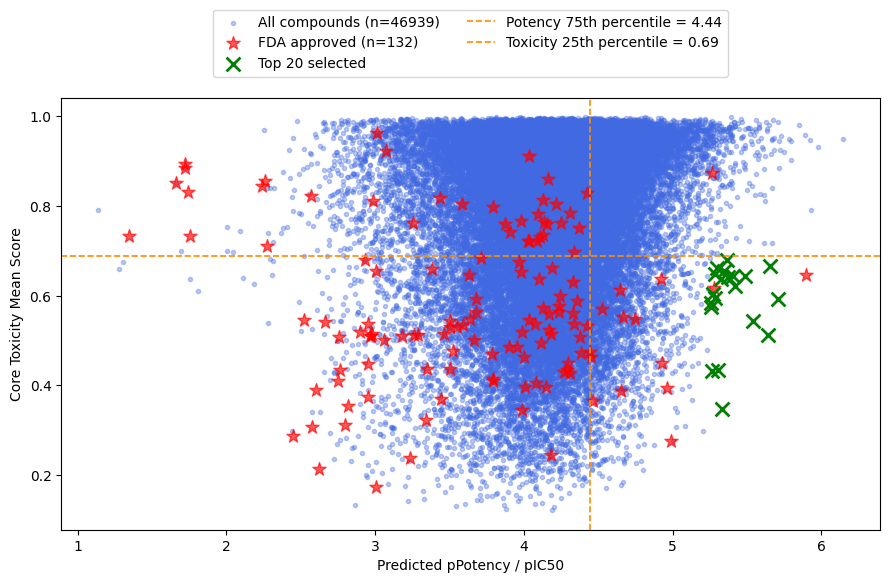

In [190]:
generatedCount = len(generatedDF)
fdaCount = len(fdaDF)
selectedCount = len(selectedGeneratedDF)
topCount = len(topGeneratedDF)

plt.figure(figsize=(9, 6))

# Full distribution of generated compounds
plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Core_Toxicity_MeanScore"],
    alpha=0.35,
    marker=".",
    c="royalblue",
    label=f"All compounds (n={generatedCount})"
)

# FDA-approved antibiotics
plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Core_Toxicity_MeanScore"],
    alpha=0.65,
    marker="*",
    c="red",
    s=100,
    label=f"FDA approved (n={fdaCount})"
)

# Highlight top 20 selected compounds
plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Core_Toxicity_MeanScore"],
    alpha=1.0,
    marker="x",
    s=100,
    c="green",
    linewidths=2,
    label=f"Top {topCount} selected"
)

# Data-driven cutoff lines
plt.axvline(
    x=potencyCutoff,
    c="darkorange",
    linestyle="--",
    linewidth=1.2,
    label=f"Potency 75th percentile = {potencyCutoff:.2f}"
)

plt.axhline(
    y=toxicityCutoff,
    c="darkorange",
    linestyle="--",
    linewidth=1.2,
    label=f"Toxicity 25th percentile = {toxicityCutoff:.2f}"
)

plt.xlabel("Predicted pPotency / pIC50")
plt.ylabel("Core Toxicity Mean Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.22), ncol=2)
plt.tight_layout()

svg_path = os.path.join(
    saveDir,
    "BacillusAnthracis_pPotency_vs_CoreToxicityMean_top20Highlighted.svg"
)
png_path = os.path.join(
    saveDir,
    "BacillusAnthracis_pPotency_vs_CoreToxicityMean_top20Highlighted.png"
)

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Plot `Core_Toxicity_MeanScore + Mechanistic_Alert_Score + ADME_Liability_Score`

Number of Stage 1 compounds considered for Stage 2: 2128
Top compounds highlighted: 20

Ranges for highlighted Stage 2 top 20 compounds:
pPotency_prediction range: 4.443 - 4.788
Core_Toxicity_MeanScore range: 0.171 - 0.389
Mechanistic_Alert_MeanScore range: 0.069 - 0.216
ADME_MeanScore range: 0.268 - 0.565
Combined_Liability_Score range: 0.059 - 0.184



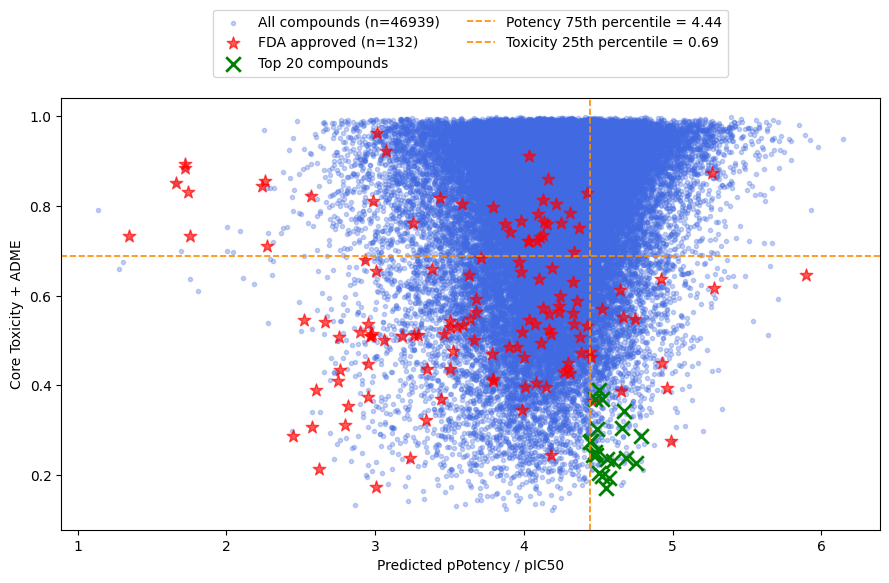

In [192]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Plot Stage 2 result using a data-driven combined liability
# Assumes these already exist from prior cells:
#   generatedDF
#   fdaDF
#   selectedGeneratedDF
#   potencyCutoff
#   toxicityCutoff
# =========================================================

def minMaxScale(series):
    series = pd.to_numeric(series, errors="coerce")
    minVal = series.min()
    maxVal = series.max()
    if pd.isna(minVal) or pd.isna(maxVal) or maxVal == minVal:
        return pd.Series(0.5, index=series.index)
    return (series - minVal) / (maxVal - minVal)

# =========================================================
# 1. Build Stage 2 dataframe from Stage 1 selected compounds
# =========================================================
requiredStage2Cols = [
    "Core_Toxicity_MeanScore",
    "Mechanistic_Alert_MeanScore",
    "ADME_MeanScore"
]

stage2DF = selectedGeneratedDF.dropna(subset=requiredStage2Cols).copy()

# Scale the three liabilities within the Stage 1 pool
stage2DF["CoreToxScaled_Stage2"] = minMaxScale(stage2DF["Core_Toxicity_MeanScore"])
stage2DF["MechanisticScaled_Stage2"] = minMaxScale(stage2DF["Mechanistic_Alert_MeanScore"])
stage2DF["ADMEScaled_Stage2"] = minMaxScale(stage2DF["ADME_MeanScore"])

# Data-driven combined liability score
# lower = better
stage2DF["Combined_Liability_Score"] = (
    stage2DF["CoreToxScaled_Stage2"] +
    stage2DF["MechanisticScaled_Stage2"] +
    stage2DF["ADMEScaled_Stage2"]
) / 3.0

# Top 20 compounds with the best combined liability
topN = 20
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_top20_stage2_combinedLiability = (
    stage2DF
    .sort_values(
        by=["Combined_Liability_Score", "pPotency_prediction"],
        ascending=[True, False]
    )
    .head(topN)
    .copy()
    .reset_index(drop=True)
)

topStage2DF = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_top20_stage2_combinedLiability.copy()

# =========================================================
# 2. Print summary before plotting
# =========================================================
print(f"Number of Stage 1 compounds considered for Stage 2: {len(stage2DF)}")
print(f"Top compounds highlighted: {len(topStage2DF)}")
print()

print("Ranges for highlighted Stage 2 top 20 compounds:")
print(
    f"pPotency_prediction range: "
    f"{topStage2DF['pPotency_prediction'].min():.3f} - "
    f"{topStage2DF['pPotency_prediction'].max():.3f}"
)
print(
    f"Core_Toxicity_MeanScore range: "
    f"{topStage2DF['Core_Toxicity_MeanScore'].min():.3f} - "
    f"{topStage2DF['Core_Toxicity_MeanScore'].max():.3f}"
)
print(
    f"Mechanistic_Alert_MeanScore range: "
    f"{topStage2DF['Mechanistic_Alert_MeanScore'].min():.3f} - "
    f"{topStage2DF['Mechanistic_Alert_MeanScore'].max():.3f}"
)
print(
    f"ADME_MeanScore range: "
    f"{topStage2DF['ADME_MeanScore'].min():.3f} - "
    f"{topStage2DF['ADME_MeanScore'].max():.3f}"
)
print(
    f"Combined_Liability_Score range: "
    f"{topStage2DF['Combined_Liability_Score'].min():.3f} - "
    f"{topStage2DF['Combined_Liability_Score'].max():.3f}"
)
print()

# =========================================================
# 3. Plot
# =========================================================
generatedCount = len(generatedDF)
fdaCount = len(fdaDF)
stage1Count = len(selectedGeneratedDF)
topCount = len(topStage2DF)

plt.figure(figsize=(9, 6))

# Full generated distribution
plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Core_Toxicity_MeanScore"],
    alpha=0.30,
    marker=".",
    c="royalblue",
    label=f"All compounds (n={generatedCount})"
)

# FDA-approved antibiotics
plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Core_Toxicity_MeanScore"],
    alpha=0.65,
    marker="*",
    c="red",
    s=90,
    label=f"FDA approved (n={fdaCount})"
)

'''
# Stage 1 selected compounds
plt.scatter(
    selectedGeneratedDF["pPotency_prediction"],
    selectedGeneratedDF["Core_Toxicity_MeanScore"],
    alpha=0.75,
    marker="o",
    facecolors="none",
    edgecolors="darkorange",
    s=40,
    linewidths=1.2,
    label=f"Stage 1 selected (n={stage1Count})"
)
'''
# Final Stage 2 top 20 compounds
plt.scatter(
    topStage2DF["pPotency_prediction"],
    topStage2DF["Core_Toxicity_MeanScore"],
    alpha=1.0,
    marker="x",
    s=110,
    c="green",
    linewidths=2,
    label=f"Top 20 compounds"
)

# Stage 1 cutoff lines
plt.axvline(
    x=potencyCutoff,
    c="darkorange",
    linestyle="--",
    linewidth=1.2,
    label=f"Potency 75th percentile = {potencyCutoff:.2f}"
)

plt.axhline(
    y=toxicityCutoff,
    c="darkorange",
    linestyle="--",
    linewidth=1.2,
    label=f"Toxicity 25th percentile = {toxicityCutoff:.2f}"
)

plt.xlabel("Predicted pPotency / pIC50")
plt.ylabel("Core Toxicity + ADME")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.22), ncol=2)
plt.tight_layout()

svg_path = os.path.join(
    saveDir,
    "BacillusAnthracis_stage2_top20_combinedLiability_pPotency_vs_CoreToxicityMean.svg"
)
png_path = os.path.join(
    saveDir,
    "BacillusAnthracis_stage2_top20_combinedLiability_pPotency_vs_CoreToxicityMean.png"
)

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

# 6.2 Data directory for model trained on `ChEMBL` bioassay dataset

In [97]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')
saveDir = os.path.join(resultsDir, "Bacillus_anthracis_bestMACAW/")
DORANETmoleculesDataDir = os.path.join(dataDir, 'DORAnet_molecules/')
ARTresultsDir = os.path.join(dataDir, 'Results/Bacillus_anthracis_bestMACAW/')
os.makedirs(saveDir, exist_ok=True)

## Check toxicty for `buyable` antibioticsData set

In [98]:
BacillusAnthracisVirus_wART_Buyable_predicted_all = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction.csv')
max_val = BacillusAnthracisVirus_wART_Buyable_predicted_all['pPotency_prediction'].max()
min_val = BacillusAnthracisVirus_wART_Buyable_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracisVirus_wART_Buyable_predicted_all

pPotency_prediction range: 0.883 → 6.329


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,2.420812,1.929846,-1.361687,6.203311,0.003795,6.261649e-07,22.997815
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,3.495472,1.932781,-0.292779,7.283722,0.000320,5.203287e-08,1.962362
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,2.896828,1.930401,-0.886757,6.680413,0.001268,2.087308e-07,7.704731
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,3.727565,1.934292,-0.063648,7.518778,0.000187,3.028464e-08,1.157837
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.094989,1.938103,0.296307,7.893671,0.000080,1.277407e-08,0.505467
...,...,...,...,...,...,...,...,...
59746,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.226625,1.954812,0.395194,8.058056,0.000059,8.748705e-09,0.402537
59747,CNc1nc(Nc2ccccc2F)nc2ccccc12,3.635805,1.958712,-0.203271,7.474882,0.000231,3.350567e-08,1.596876
59748,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.236636,1.962426,0.390281,8.082991,0.000058,8.260558e-09,0.407117
59749,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,3.757461,1.971891,-0.107446,7.622368,0.000175,2.385790e-08,1.280697


### Read predicted ADMET properties for all candidate SMILES

In [68]:
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_wToxicity.csv')
max_val = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity

pPotency_prediction range: 1.082 → 6.329


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,2.420812,1.929846,-1.361687,6.203311,0.003795,6.261649e-07,22.997815,374.397,3.12552,...,49.127569,94.998061,92.943001,37.999225,83.094223,16.905777,80.806514,82.551377,21.170997,93.524622
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,3.495472,1.932781,-0.292779,7.283722,0.000320,5.203287e-08,1.962362,338.393,1.33666,...,36.603335,55.796820,70.104692,0.736720,22.799535,13.067080,41.682823,70.414889,45.599069,21.868941
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,2.896828,1.930401,-0.886757,6.680413,0.001268,2.087308e-07,7.704731,384.454,0.45232,...,52.113222,91.624661,85.653354,0.969368,41.837922,19.658782,31.562621,44.939899,58.821249,55.409073
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,3.727565,1.934292,-0.063648,7.518778,0.000187,3.028464e-08,1.157837,346.416,1.90460,...,33.772780,59.053897,33.074835,59.790617,27.917798,28.266770,28.925940,44.784800,57.813106,14.850717
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.094989,1.938103,0.296307,7.893671,0.000080,1.277407e-08,0.505467,341.772,2.47350,...,21.907716,22.373013,11.205894,40.907328,36.874758,65.645599,15.471113,94.571539,59.092672,11.322218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46941,CNc1nc(Nc2ccccc2)nc2ccccc12,3.865233,1.959841,0.023946,7.706521,0.000136,1.965527e-08,0.946355,250.305,3.41510,...,75.300504,88.522683,94.920512,91.547111,48.933695,28.809616,87.436991,85.188057,23.497480,89.647150
46942,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.226625,1.954812,0.395194,8.058056,0.000059,8.748705e-09,0.402537,254.268,3.09470,...,63.474215,74.951532,86.816596,73.904614,31.252423,70.608763,78.092284,72.974021,40.209383,45.599069
46943,CNc1nc(Nc2ccccc2F)nc2ccccc12,3.635805,1.958712,-0.203271,7.474882,0.000231,3.350567e-08,1.596876,268.295,3.55420,...,73.943389,86.390074,95.851105,88.716557,45.250097,55.215200,88.483908,83.288096,26.056611,57.464133
46944,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.236636,1.962426,0.390281,8.082991,0.000058,8.260558e-09,0.407117,270.723,3.60900,...,70.182241,84.877860,91.469562,88.290035,32.997286,70.531214,83.637069,79.643273,26.715781,93.175649


### Retain potency predictions along with toxicity, mechanistic, and ADME-related endpoints

In [69]:
# Potency-related columns
potencyCols = [
    "SMILES",
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.columns
]

BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.shape)
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.head()

Filtered dataframe shape: (46946, 41)


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,2.420812,1.929846,-1.361687,6.203311,0.003795,6.261649e-07,22.997815,0.727207,0.499834,...,0.995333,0.889405,0.556546,0.952716,0.115046,0.826106,0.134753,0.108329,0.760515,0.592387
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,3.495472,1.932781,-0.292779,7.283722,0.000320,5.203287e-08,1.962362,0.204361,0.089317,...,0.949429,0.973717,0.730353,0.310337,0.474573,0.095773,0.269003,0.008871,0.549327,0.044814
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,2.896828,1.930401,-0.886757,6.680413,0.001268,2.087308e-07,7.704731,0.312347,0.181800,...,0.925759,0.893960,0.012659,0.420566,0.319929,0.083655,0.081229,0.007386,0.524254,0.148049
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,3.727565,1.934292,-0.063648,7.518778,0.000187,3.028464e-08,1.157837,0.049025,0.109170,...,0.842507,0.874405,0.007123,0.112539,0.517903,0.071035,0.050239,0.037251,0.335556,0.179092
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.094989,1.938103,0.296307,7.893671,0.000080,1.277407e-08,0.505467,0.008243,0.031413,...,0.110157,0.798915,0.050893,0.081878,0.708961,0.196669,0.026894,0.021543,0.313643,0.009893


### Read ADMET endpoints of the FDA approved Drug data from `Drugbank`

In [59]:
drugBankDrug_FDAapproved_antibiotic_wToxicity = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_drugBankDrug_FDAapproved_antibiotic_ARTprediction.csv')
drugBankDrug_FDAapproved_antibiotic_wToxicity

,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,Unnamed: 0,ATC_code,...,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile,source_DataBase
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,3.159859,1.930542,-0.624004,6.943722,0.000692,1.138354e-07,4.207305,0,J01GB;J01RA,...,50.213261,31.136099,50.756107,2.132610,8.103916,6.397829,7.095774,91.779760,4.885615,DrugBank_antibiotics
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,3.884242,1.935675,0.090318,7.678165,0.000131,2.098142e-08,0.812235,1,J01CA;J01CR,...,21.946491,39.278790,35.789066,14.618069,19.271035,13.609926,31.174874,70.104692,40.248158,DrugBank_antibiotics
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,2.502970,1.930324,-1.280466,6.286406,0.003141,5.171229e-07,19.075046,4,J01CA;J01CR,...,17.526173,74.059713,39.007367,18.960838,28.227995,14.385421,55.292749,51.337728,55.409073,DrugBank_antibiotics
3,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,2.828927,1.938527,-0.970585,6.628439,0.001483,2.352667e-07,9.345113,5,J01DF,...,9.461031,29.701435,34.044203,8.646762,40.209383,0.736720,30.981000,80.496316,78.480031,DrugBank_antibiotics
4,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,2.839618,1.938420,-0.959685,6.638920,0.001447,2.296570e-07,9.113501,6,J01CA;J01CR,...,90.500194,97.867390,6.514153,51.647926,62.659946,60.992633,50.290810,52.307096,77.665762,DrugBank_antibiotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,CCS(=O)(=O)CCn1c([N+](=O)[O-])cnc1C,3.467529,1.941613,-0.338033,7.273090,0.000341,5.332239e-08,2.177877,147,J01RA;J01XD,...,14.850717,44.203180,26.483133,36.913532,13.105855,17.603722,19.464909,70.957736,66.072121,DrugBank_antibiotics
129,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,4.183201,1.930681,0.399066,7.967336,0.000066,1.078114e-08,0.398964,149,J01EA;J01EE,...,55.486623,38.425746,12.989531,25.474990,44.668476,41.372625,34.548275,58.666150,13.881349,DrugBank_antibiotics
130,CO[C@H]1C[C@H](O[C@H]2[C@H](C)[C@@H](O[C@@H]3O...,2.218293,1.932381,-1.569172,6.005759,0.006049,9.868260e-07,37.082793,150,J01FA,...,92.400155,83.210547,74.408686,73.284219,76.424971,62.349748,49.864288,31.213649,88.677782,DrugBank_antibiotics
131,N[C@@H]1[C@H]2CN(c3nc4c(cc3F)c(=O)c(C(=O)O)cn4...,2.421079,1.939835,-1.380997,6.223155,0.003792,5.981986e-07,24.043475,151,J01MA,...,22.024040,7.599845,48.933695,34.005428,65.451725,24.040326,30.942226,20.240403,20.744475,DrugBank_antibiotics


### Retain only toxicity, mechanistic, and ADME-related endpoints

In [60]:
# Potency-related columns
dataCols = [
    "smiles",
    "ATC_code", "Drug_Type", "source_DataBase"
]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrug_FDAapproved_antibiotic_wToxicity.columns
]

drugBankDrug_FDAapproved_antibiotic_wToxicity = drugBankDrug_FDAapproved_antibiotic_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrug_FDAapproved_antibiotic_wToxicity.shape)
drugBankDrug_FDAapproved_antibiotic_wToxicity.head()

Filtered dataframe shape: (133, 44)


,smiles,ATC_code,Drug_Type,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,J01GB;J01RA,antibiotic,DrugBank_antibiotics,3.159859,1.930542,-0.624004,6.943722,0.000692,1.138354e-07,...,0.038441,0.078183,0.000265,0.007574,0.002886,0.001272,0.016743,0.013290,0.264031,0.002039
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,J01CA;J01CR,antibiotic,DrugBank_antibiotics,3.884242,1.935675,0.090318,7.678165,0.000131,2.098142e-08,...,0.024073,0.689159,0.001078,0.006863,0.120056,0.001875,0.029528,0.005839,0.341138,0.002913
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,J01CA;J01CR,antibiotic,DrugBank_antibiotics,2.502970,1.930324,-1.280466,6.286406,0.003141,5.171229e-07,...,0.029585,0.498562,0.000209,0.003408,0.147586,0.001105,0.014598,0.002810,0.168017,0.003372
3,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,J01DF,antibiotic,DrugBank_antibiotics,2.828927,1.938527,-0.970585,6.628439,0.001483,2.352667e-07,...,0.021248,0.170979,0.000327,0.001936,0.099924,0.000396,0.006895,0.003862,0.107208,0.000714
4,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,J01CA;J01CR,antibiotic,DrugBank_antibiotics,2.839618,1.938420,-0.959685,6.638920,0.001447,2.296570e-07,...,0.580503,0.481893,0.013029,0.136983,0.067901,0.033108,0.063642,0.114837,0.503432,0.740134


### Multiparameter optimization (MPO) framework based ADMET scoring

We replaced simple arithmetic averaging with a weighted desirability-based multiparameter optimization (MPO) framework. Each ADMET endpoint was converted to a 0–1 desirability value, where `1 --> favorable` and `0 --> unfavorable` profile. Category-level scores were then combined using weighted geometric means, following the same general pattern used in QED and ADMET-score approaches.

**References**

1. ADMET-score – a comprehensive scoring function for evaluation of chemical drug-likeness (https://pubs.rsc.org/en/content/articlelanding/2019/md/c8md00472b)
2. Quantifying the chemical beauty of drugs (https://www.nature.com/articles/nchem.1243)

In [70]:
# =========================================================
# 1. Endpoint groups
# =========================================================
coreToxicityCols = [
    "AMES", "hERG", "DILI", "ClinTox",
    "Carcinogens_Lagunin", "Skin_Reaction", "LD50_Zhu"
]

mechanisticAlertCols = [
    "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53",
    "NR-AR-LBD", "NR-AR", "NR-AhR", "NR-Aromatase",
    "NR-ER-LBD", "NR-ER", "NR-PPAR-gamma"
]

admeLowerIsBetter = [
    "Pgp_Broccatelli",
    "CYP1A2_Veith", "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels", "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels", "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels", "CYP3A4_Veith",
]

admeHigherIsBetter = [
    "Caco2_Wang", "HIA_Hou", "PAMPA_NCATS", "Bioavailability_Ma"
]

# Keep BBB optional for anti-infective projects
includeBBB = False
if includeBBB:
    admeLowerIsBetter = admeLowerIsBetter + ["BBB_Martins"]

allAdmetCols = sorted(set(
    coreToxicityCols + mechanisticAlertCols + admeLowerIsBetter + admeHigherIsBetter
))

# =========================================================
# 2. Input data
# =========================================================
candidateDF = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.copy()
referenceDF = drugBankDrug_FDAapproved_antibiotic_wToxicity.copy()

# Only keep ADMET columns that actually exist in both datasets
availableCols = [
    col for col in allAdmetCols
    if col in candidateDF.columns and col in referenceDF.columns
]

coreAvailable = [col for col in coreToxicityCols if col in availableCols]
mechAvailable = [col for col in mechanisticAlertCols if col in availableCols]
admeLowerAvailable = [col for col in admeLowerIsBetter if col in availableCols]
admeHigherAvailable = [col for col in admeHigherIsBetter if col in availableCols]

# =========================================================
# 3. Reference statistics from FDA-approved antibiotics
#    A) Percentiles for Stage 1/2 filtering
#    B) Mean/std for desirability scoring
# =========================================================
referenceNumericDF = referenceDF[availableCols].apply(pd.to_numeric, errors="coerce")

percentileSummaryDF = (
    referenceNumericDF
    .agg([
        lambda x: x.quantile(0.10),
        lambda x: x.quantile(0.90)
    ])
    .T
)
percentileSummaryDF.columns = ["q10", "q90"]

meanStdSummaryDF = (
    referenceNumericDF
    .agg(["mean", lambda x: x.std(ddof=0)])
    .T
)
meanStdSummaryDF.columns = ["Mean", "Std"]

percentileDict = percentileSummaryDF.to_dict(orient="index")
meanStdDict = meanStdSummaryDF.to_dict(orient="index")

# =========================================================
# 4. Helper functions
# =========================================================
epsilon = 1e-6

def clip01(series):
    return series.clip(lower=epsilon, upper=1 - epsilon)

def buildPercentileMask(df, lowerIsBetterCols, higherIsBetterCols, percentileDict):
    mask = pd.Series(True, index=df.index)

    for col in lowerIsBetterCols:
        if col not in df.columns or col not in percentileDict:
            continue
        series = pd.to_numeric(df[col], errors="coerce")
        mask &= series <= percentileDict[col]["q90"]

    for col in higherIsBetterCols:
        if col not in df.columns or col not in percentileDict:
            continue
        series = pd.to_numeric(df[col], errors="coerce")
        mask &= series >= percentileDict[col]["q10"]

    return mask

def desirabilityLowerIsBetter(series, endpointName, meanStdDict):
    meanVal = meanStdDict[endpointName]["Mean"]
    stdVal = meanStdDict[endpointName]["Std"]

    if pd.isna(meanVal) or pd.isna(stdVal) or stdVal <= 0:
        return pd.Series(0.5, index=series.index)

    z = (series - meanVal) / stdVal
    desirability = np.where(series <= meanVal, 1.0, np.exp(-0.5 * z**2))
    return clip01(pd.Series(desirability, index=series.index))

def desirabilityHigherIsBetter(series, endpointName, meanStdDict):
    meanVal = meanStdDict[endpointName]["Mean"]
    stdVal = meanStdDict[endpointName]["Std"]

    if pd.isna(meanVal) or pd.isna(stdVal) or stdVal <= 0:
        return pd.Series(0.5, index=series.index)

    z = (meanVal - series) / stdVal
    desirability = np.where(series >= meanVal, 1.0, np.exp(-0.5 * z**2))
    return clip01(pd.Series(desirability, index=series.index))

def weightedGeometricMean(dfValues, weightsDict):
    cols = [col for col in weightsDict if col in dfValues.columns]
    if len(cols) == 0:
        return pd.Series(np.nan, index=dfValues.index)

    weights = np.array([weightsDict[col] for col in cols], dtype=float)
    weights = weights / weights.sum()

    values = dfValues[cols].copy().clip(lower=epsilon, upper=1 - epsilon)
    return np.exp(np.log(values).mul(weights, axis=1).sum(axis=1))

def addDesirabilityScores(df):
    df = df.copy()

    coreWeights = {col: 1.0 for col in coreAvailable}
    mechWeights = {col: 1.0 for col in mechAvailable}
    admeWeights = {col: 1.0 for col in (admeLowerAvailable + admeHigherAvailable)}

    coreDesDF = pd.DataFrame(index=df.index)
    for col in coreAvailable:
        coreDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    mechDesDF = pd.DataFrame(index=df.index)
    for col in mechAvailable:
        mechDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    admeDesDF = pd.DataFrame(index=df.index)
    for col in admeLowerAvailable:
        admeDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )
    for col in admeHigherAvailable:
        admeDesDF[col] = desirabilityHigherIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    df["Core_Toxicity_Desirability"] = weightedGeometricMean(coreDesDF, coreWeights)
    df["Core_Toxicity_Score"] = 1 - df["Core_Toxicity_Desirability"]

    df["Mechanistic_Alert_Desirability"] = weightedGeometricMean(mechDesDF, mechWeights)
    df["Mechanistic_Alert_Score"] = 1 - df["Mechanistic_Alert_Desirability"]

    df["ADME_Desirability"] = weightedGeometricMean(admeDesDF, admeWeights)
    df["ADME_Liability_Score"] = 1 - df["ADME_Desirability"]

    return df

def keepConciseColumns(df):
    keepCols = [col for col in ["SMILES", "smiles", "ATC_code", "Drug_Type", "pPotency_prediction", "pPotency_std"] if col in df.columns]
    scoreCols = [
        "Core_Toxicity_Desirability", "Core_Toxicity_Score",
        "Mechanistic_Alert_Desirability", "Mechanistic_Alert_Score",
        "ADME_Desirability", "ADME_Liability_Score"
    ]
    keepCols += [col for col in scoreCols if col in df.columns]
    return df[keepCols].copy()

# =========================================================
# 5. Add score columns to both datasets
# =========================================================
candidateScoredDF = addDesirabilityScores(candidateDF)
referenceScoredDF = addDesirabilityScores(referenceDF)

# =========================================================
# 6. Stage 1: percentile-based toxicity-first filtering
#    lower-is-better endpoints must be <= antibiotic q90
# =========================================================
candidateCoreMask = buildPercentileMask(
    candidateScoredDF,
    lowerIsBetterCols=coreAvailable,
    higherIsBetterCols=[],
    percentileDict=percentileDict
)

referenceCoreMask = buildPercentileMask(
    referenceScoredDF,
    lowerIsBetterCols=coreAvailable,
    higherIsBetterCols=[],
    percentileDict=percentileDict
)

candidateCoreDF = candidateScoredDF.loc[candidateCoreMask].reset_index(drop=True)
referenceCoreDF = referenceScoredDF.loc[referenceCoreMask].reset_index(drop=True)

# =========================================================
# 7. Stage 2: percentile-based mechanistic/ADME filtering
#    mechanistic + ADME liabilities <= q90
#    favorable ADME endpoints >= q10
# =========================================================
candidateAdmetMask = buildPercentileMask(
    candidateCoreDF,
    lowerIsBetterCols=mechAvailable + admeLowerAvailable,
    higherIsBetterCols=admeHigherAvailable,
    percentileDict=percentileDict
)

referenceAdmetMask = buildPercentileMask(
    referenceCoreDF,
    lowerIsBetterCols=mechAvailable + admeLowerAvailable,
    higherIsBetterCols=admeHigherAvailable,
    percentileDict=percentileDict
)

candidateAdmetDF = candidateCoreDF.loc[candidateAdmetMask].reset_index(drop=True)
referenceAdmetDF = referenceCoreDF.loc[referenceAdmetMask].reset_index(drop=True)

# =========================================================
# 8. Final concise output dataframes
# =========================================================
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_core = keepConciseColumns(candidateCoreDF)
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_ADMET = keepConciseColumns(candidateAdmetDF)

drugBankDrug_FDAapproved_antibiotic_wToxicity_core = keepConciseColumns(referenceCoreDF)
drugBankDrug_FDAapproved_antibiotic_wToxicity_ADMET = keepConciseColumns(referenceAdmetDF)

print(f"BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_core: {BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_core.shape}")
print(f"BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_ADMET: {BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_ADMET.shape}")
print(f"drugBankDrug_FDAapproved_antibiotic_wToxicity_core: {drugBankDrug_FDAapproved_antibiotic_wToxicity_core.shape}")
print(f"drugBankDrug_FDAapproved_antibiotic_wToxicity_ADMET: {drugBankDrug_FDAapproved_antibiotic_wToxicity_ADMET.shape}")

BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_core: (6317, 9)
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_ADMET: (155, 9)
drugBankDrug_FDAapproved_antibiotic_wToxicity_core: (67, 11)
drugBankDrug_FDAapproved_antibiotic_wToxicity_ADMET: (19, 11)


### Define filter for compound ranking based on `ADMET` scores

### Plot full distribution + highlighted filtered dataframe

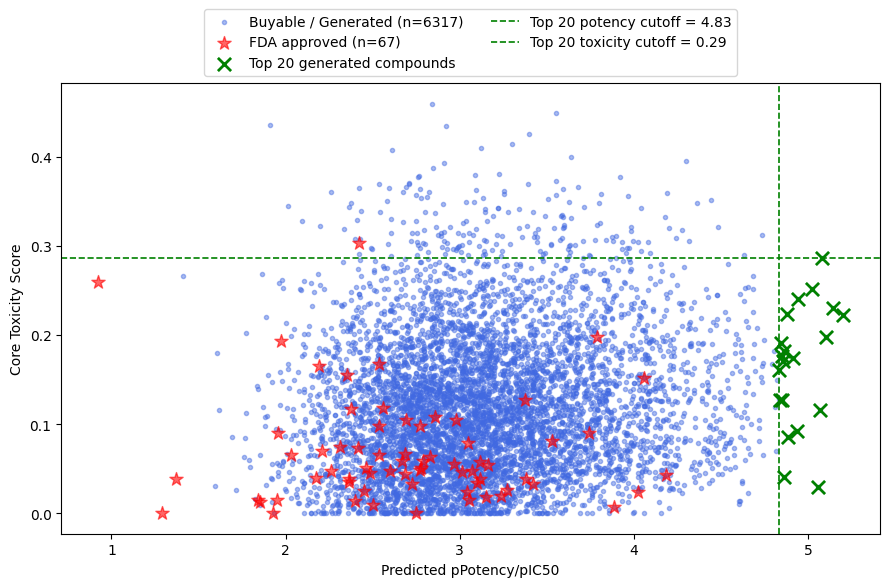

In [71]:
import matplotlib.pyplot as plt

# Dataframes
generatedDF = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_core.copy()
fdaDF = drugBankDrug_FDAapproved_antibiotic_wToxicity_core.copy()

# Keep only rows with required columns
generatedDF = generatedDF[
    generatedDF["pPotency_prediction"].notna() &
    generatedDF["Core_Toxicity_Score"].notna()
].copy()

fdaDF = fdaDF[
    fdaDF["pPotency_prediction"].notna() &
    fdaDF["Core_Toxicity_Score"].notna()
].copy()

# Top 20 generated compounds:
# highest potency first, then lowest toxicity
topN = 20
topGeneratedDF = (
    generatedDF
    .sort_values(
        by=["pPotency_prediction", "Core_Toxicity_Score"],
        ascending=[False, True]
    )
    .head(topN)
    .copy()
)

# Threshold lines from top 20 generated compounds
potencyLine = topGeneratedDF["pPotency_prediction"].min()
toxicityLine = topGeneratedDF["Core_Toxicity_Score"].max()

generatedCount = len(generatedDF)
fdaCount = len(fdaDF)
topCount = len(topGeneratedDF)

plt.figure(figsize=(9, 6))

# Buyable / generated compounds
plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Buyable / Generated (n={generatedCount})"
)

# FDA-approved antibiotic compounds
plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Core_Toxicity_Score"],
    alpha=0.6,
    marker="*",
    c="red",
    s=100,
    label=f"FDA approved (n={fdaCount})"
)

# Top 20 generated compounds
plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="green",
    linewidths=2,
    label=f"Top 20 generated compounds"
)

# Threshold lines from top 20 generated compounds
plt.axvline(
    x=potencyLine,
    c="green",
    linestyle="--",
    linewidth=1.2,
    label=f"Top 20 potency cutoff = {potencyLine:.2f}"
)

plt.axhline(
    y=toxicityLine,
    c="green",
    linestyle="--",
    linewidth=1.2,
    label=f"Top 20 toxicity cutoff = {toxicityLine:.2f}"
)

plt.xlabel("Predicted pPotency/pIC50")
plt.ylabel("Core Toxicity Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=2)
plt.tight_layout()
svg_path = os.path.join(saveDir, "BacillusAnthracisVirus_wART_Buyable_plot_pPotency_CoreToxicity.svg")
png_path = os.path.join(saveDir, "BacillusAnthracisVirus_wART_Buyable_plot_pPotency_CoreToxicity.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Add `Mechanistic_Alert_Score` & `ADME_Liability_Score` with `Toxicity`

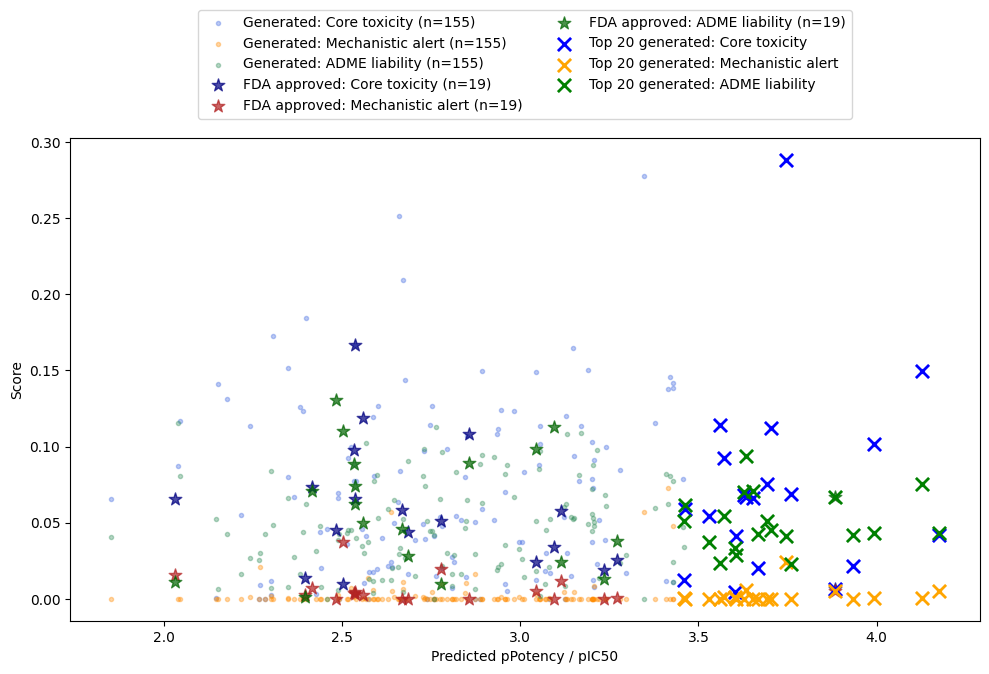

In [72]:
import os
import matplotlib.pyplot as plt

# Best generated compounds after full ADMET filtering
generatedDF = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_ADMET.copy()
fdaDF = drugBankDrug_FDAapproved_antibiotic_wToxicity_ADMET.copy()

requiredCols = [
    "pPotency_prediction",
    "Core_Toxicity_Score",
    "Mechanistic_Alert_Score",
    "ADME_Liability_Score"
]

generatedDF = generatedDF.dropna(subset=requiredCols).copy()
fdaDF = fdaDF.dropna(subset=requiredCols).copy()

# Rank generated compounds by potency first, then lowest liabilities
bestGeneratedDF = (
    generatedDF
    .sort_values(
        by=[
            "pPotency_prediction",
            "Core_Toxicity_Score",
            "Mechanistic_Alert_Score",
            "ADME_Liability_Score"
        ],
        ascending=[False, True, True, True]
    )
    .reset_index(drop=True)
)

topN = 20
topGeneratedDF = bestGeneratedDF.head(topN).copy()

generatedCount = len(generatedDF)
fdaCount = len(fdaDF)
topCount = len(topGeneratedDF)

plt.figure(figsize=(10, 7))

# Generated compounds
plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Core_Toxicity_Score"],
    alpha=0.35,
    marker=".",
    c="royalblue",
    label=f"Generated: Core toxicity (n={generatedCount})"
)

plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Mechanistic_Alert_Score"],
    alpha=0.35,
    marker=".",
    c="darkorange",
    label=f"Generated: Mechanistic alert (n={generatedCount})"
)

plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["ADME_Liability_Score"],
    alpha=0.35,
    marker=".",
    c="seagreen",
    label=f"Generated: ADME liability (n={generatedCount})"
)

# FDA-approved reference compounds
plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Core_Toxicity_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="navy",
    label=f"FDA approved: Core toxicity (n={fdaCount})"
)

plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Mechanistic_Alert_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="firebrick",
    label=f"FDA approved: Mechanistic alert (n={fdaCount})"
)

plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["ADME_Liability_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="darkgreen",
    label=f"FDA approved: ADME liability (n={fdaCount})"
)

# Top generated compounds
plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="blue",
    linewidths=2,
    label=f"Top {topN} generated: Core toxicity"
)

plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Mechanistic_Alert_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="orange",
    linewidths=2,
    label=f"Top {topN} generated: Mechanistic alert"
)

plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["ADME_Liability_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="green",
    linewidths=2,
    label=f"Top {topN} generated: ADME liability"
)

plt.xlabel("Predicted pPotency / pIC50")
plt.ylabel("Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.28), ncol=2)
plt.tight_layout()

svg_path = os.path.join(saveDir, "BacillusAnthracisVirus_wART_Buyable_plot_bestCompounds_AllThreeScores.svg")
png_path = os.path.join(saveDir, "BacillusAnthracisVirus_wART_Buyable_plot_bestCompounds_AllThreeScores.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

In [80]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
df = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_core

# Predicted pPotency from the new dataframe
predicted_pPotency = df['pPotency_prediction'].values

top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]  # Last (20th) value
highest_pPotency = predicted_pPotency[top_20_idx[0]]  # First (1st) value

# Convert to IC50 in µM
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM   = 10**(-highest_pPotency) * 1e6
top_20_std = df['pPotency_std'].values[top_20_idx]


print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} (IC50: {cutoff_IC50_uM:.3f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} (IC50: {best_IC50_uM:.3f} µM)")
print(f"Mean pPotency_std over top-20: {np.mean(top_20_std):.3f}")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} - {highest_pPotency:.2f}; IC50 --> {cutoff_IC50_uM:.3f} - {best_IC50_uM:.3f} µM")

Top 20 compounds cutoff pPotency: 4.83 (IC50: 14.645 µM)
Highest predicted pPotency: 5.20 (IC50: 6.318 µM)
Mean pPotency_std over top-20: 1.935
pPotency range of top 20 compounds: pPotency --> 4.83 - 5.20; IC50 --> 14.645 - 6.318 µM


## Check toxicty for DORANET generated antibioticsData set from `Basidalin precursor`

In [74]:
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction.csv')
max_val = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all['pPotency_prediction'].max()
min_val = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all

pPotency_prediction range: 1.393 → 5.178


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,basidalin_Precursor,3.526906,1.930244,-0.256372,7.310185,0.000297,4.895708e-08,1.804561
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,basidalin_Precursor,3.252108,1.929911,-0.530518,7.034734,0.000560,9.231371e-08,3.392489
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,basidalin_Precursor,2.689813,1.934148,-1.101116,6.480743,0.002043,3.305651e-07,12.621659
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,basidalin_Precursor,2.674573,1.935209,-1.118437,6.467584,0.002116,3.407348e-07,13.135214
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,basidalin_Precursor,3.274244,1.931984,-0.512445,7.060933,0.000532,8.690938e-08,3.254203
...,...,...,...,...,...,...,...,...,...,...
651806,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,basidalin_Precursor,2.637517,1.934402,-1.153910,6.428945,0.002304,3.724393e-07,14.253118
651807,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,basidalin_Precursor,2.789167,1.936595,-1.006559,6.584894,0.001625,2.600796e-07,10.152172
651808,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,basidalin_Precursor,3.151059,1.937884,-0.647195,6.949312,0.000706,1.123798e-07,4.438075
651809,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,basidalin_Precursor,3.136100,1.940873,-0.668012,6.940212,0.000731,1.147593e-07,4.655990


### Read predicted ADMET properties for all candidate SMILES

In [75]:
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction_wToxicity.csv')
max_val = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity

pPotency_prediction range: 1.456 → 5.178


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,3.526906,1.930244,-0.256372,7.310185,0.000297,4.895708e-08,1.804561,507.182,-1.62900,...,5.428461,23.381155,54.633579,87.398216,4.652966,9.112059,36.719659,28.887166,89.414502,9.732454
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,2.689813,1.934148,-1.101116,6.480743,0.002043,3.305651e-07,12.621659,785.557,-2.42396,...,5.893757,12.563009,56.688639,69.910818,4.071345,53.392788,39.433889,46.219465,82.939124,2.326483
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,2.674573,1.935209,-1.118437,6.467584,0.002116,3.407348e-07,13.135214,787.573,-1.75026,...,4.769290,15.936409,61.962001,83.365646,3.140752,61.186506,42.807290,44.784800,85.071733,7.134548
3,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,3.139028,1.938263,-0.659967,6.938023,0.000726,1.153392e-07,4.570537,744.417,-2.89890,...,3.799922,19.542458,50.872431,92.904226,2.869329,13.803800,30.050407,24.505622,92.594029,16.401706
4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,3.019580,1.938354,-0.779594,6.818755,0.000956,1.517908e-07,6.019961,745.425,-2.56940,...,4.226444,29.701435,76.075998,88.096161,3.722373,29.352462,35.944164,27.142303,91.081815,2.791780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210077,CC(=O)N(C[C@H](C)C=C1C=C(O)C(=O)O1)C(=O)CN,2.386857,1.929609,-1.395177,6.168891,0.004103,6.778119e-07,24.841433,268.269,-0.16110,...,52.229546,32.144242,13.687476,4.846840,15.005816,21.519969,15.044591,28.150446,79.643273,72.198527
210078,C=C1OC(=O)C(O)=C1C[C@@H](C)CNC(=O)[C@H](C)N,2.877011,1.932729,-0.911138,6.665160,0.001327,2.161922e-07,8.149639,254.286,0.35860,...,50.639783,31.834044,18.960838,11.244668,21.713843,32.105467,25.319891,20.628150,87.747189,37.068631
210079,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,2.789167,1.936595,-1.006559,6.584894,0.001625,2.600796e-07,10.152172,236.271,-0.15188,...,69.639395,39.860411,23.419930,44.668476,15.897635,75.494378,26.793331,40.209383,71.112834,73.594416
210080,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,3.151059,1.937884,-0.647195,6.949312,0.000706,1.123798e-07,4.438075,254.286,-0.39730,...,41.527724,35.478868,7.522295,17.448623,15.432338,33.695231,18.844513,10.818147,84.490112,23.691353


### Retain potency predictions along with toxicity, mechanistic, and ADME-related endpoints

In [76]:
# Potency-related columns
potencyCols = [
    "SMILES",
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.columns
]

BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.shape)
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.head()

Filtered dataframe shape: (210082, 41)


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,3.526906,1.930244,-0.256372,7.310185,0.000297,4.895708e-08,1.804561,0.033052,0.330824,...,0.024185,0.159878,0.001577,0.034541,0.056855,0.011661,0.015668,0.198030,0.076890,0.001108
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,2.689813,1.934148,-1.101116,6.480743,0.002043,3.305651e-07,12.621659,0.239975,0.900458,...,0.070120,0.380114,0.007940,0.026014,0.047826,0.052646,0.026518,0.152412,0.267949,0.046004
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,2.674573,1.935209,-1.118437,6.467584,0.002116,3.407348e-07,13.135214,0.188998,0.908109,...,0.050004,0.349236,0.005862,0.050689,0.057204,0.072706,0.040867,0.214760,0.236050,0.066886
3,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,3.139028,1.938263,-0.659967,6.938023,0.000726,1.153392e-07,4.570537,0.160844,0.619006,...,0.033647,0.122790,0.001046,0.012560,0.021261,0.009916,0.009539,0.241743,0.165820,0.002698
4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,3.019580,1.938354,-0.779594,6.818755,0.000956,1.517908e-07,6.019961,0.198825,0.550806,...,0.056442,0.123578,0.001490,0.031071,0.019455,0.017940,0.009144,0.228861,0.219715,0.009885


### Multiparameter optimization (MPO) framework based ADMET scoring

We replaced simple arithmetic averaging with a weighted desirability-based multiparameter optimization (MPO) framework. Each ADMET endpoint was converted to a 0–1 desirability value, where `1 --> favorable` and `0 --> unfavorable` profile. Category-level scores were then combined using weighted geometric means, following the same general pattern used in QED and ADMET-score approaches.

**References**

1. ADMET-score – a comprehensive scoring function for evaluation of chemical drug-likeness (https://pubs.rsc.org/en/content/articlelanding/2019/md/c8md00472b)
2. Quantifying the chemical beauty of drugs (https://www.nature.com/articles/nchem.1243)

In [77]:
# =========================================================
# 1. Endpoint groups
# =========================================================
coreToxicityCols = [
    "AMES", "hERG", "DILI", "ClinTox",
    "Carcinogens_Lagunin", "Skin_Reaction", "LD50_Zhu"
]

mechanisticAlertCols = [
    "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53",
    "NR-AR-LBD", "NR-AR", "NR-AhR", "NR-Aromatase",
    "NR-ER-LBD", "NR-ER", "NR-PPAR-gamma"
]

admeLowerIsBetter = [
    "Pgp_Broccatelli",
    "CYP1A2_Veith", "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels", "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels", "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels", "CYP3A4_Veith",
]

admeHigherIsBetter = [
    "Caco2_Wang", "HIA_Hou", "PAMPA_NCATS", "Bioavailability_Ma"
]

# Keep BBB optional for anti-infective projects
includeBBB = False
if includeBBB:
    admeLowerIsBetter = admeLowerIsBetter + ["BBB_Martins"]

allAdmetCols = sorted(set(
    coreToxicityCols + mechanisticAlertCols + admeLowerIsBetter + admeHigherIsBetter
))

# =========================================================
# 2. Input data
# =========================================================
candidateDF = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.copy()
referenceDF = drugBankDrug_FDAapproved_antibiotic_wToxicity.copy()

# Only keep ADMET columns that actually exist in both datasets
availableCols = [
    col for col in allAdmetCols
    if col in candidateDF.columns and col in referenceDF.columns
]

coreAvailable = [col for col in coreToxicityCols if col in availableCols]
mechAvailable = [col for col in mechanisticAlertCols if col in availableCols]
admeLowerAvailable = [col for col in admeLowerIsBetter if col in availableCols]
admeHigherAvailable = [col for col in admeHigherIsBetter if col in availableCols]

# =========================================================
# 3. Reference statistics from FDA-approved antibiotics
#    A) Percentiles for Stage 1/2 filtering
#    B) Mean/std for desirability scoring
# =========================================================
referenceNumericDF = referenceDF[availableCols].apply(pd.to_numeric, errors="coerce")

percentileSummaryDF = (
    referenceNumericDF
    .agg([
        lambda x: x.quantile(0.10),
        lambda x: x.quantile(0.90)
    ])
    .T
)
percentileSummaryDF.columns = ["q10", "q90"]

meanStdSummaryDF = (
    referenceNumericDF
    .agg(["mean", lambda x: x.std(ddof=0)])
    .T
)
meanStdSummaryDF.columns = ["Mean", "Std"]

percentileDict = percentileSummaryDF.to_dict(orient="index")
meanStdDict = meanStdSummaryDF.to_dict(orient="index")

# =========================================================
# 4. Helper functions
# =========================================================
epsilon = 1e-6

def clip01(series):
    return series.clip(lower=epsilon, upper=1 - epsilon)

def buildPercentileMask(df, lowerIsBetterCols, higherIsBetterCols, percentileDict):
    mask = pd.Series(True, index=df.index)

    for col in lowerIsBetterCols:
        if col not in df.columns or col not in percentileDict:
            continue
        series = pd.to_numeric(df[col], errors="coerce")
        mask &= series <= percentileDict[col]["q90"]

    for col in higherIsBetterCols:
        if col not in df.columns or col not in percentileDict:
            continue
        series = pd.to_numeric(df[col], errors="coerce")
        mask &= series >= percentileDict[col]["q10"]

    return mask

def desirabilityLowerIsBetter(series, endpointName, meanStdDict):
    meanVal = meanStdDict[endpointName]["Mean"]
    stdVal = meanStdDict[endpointName]["Std"]

    if pd.isna(meanVal) or pd.isna(stdVal) or stdVal <= 0:
        return pd.Series(0.5, index=series.index)

    z = (series - meanVal) / stdVal
    desirability = np.where(series <= meanVal, 1.0, np.exp(-0.5 * z**2))
    return clip01(pd.Series(desirability, index=series.index))

def desirabilityHigherIsBetter(series, endpointName, meanStdDict):
    meanVal = meanStdDict[endpointName]["Mean"]
    stdVal = meanStdDict[endpointName]["Std"]

    if pd.isna(meanVal) or pd.isna(stdVal) or stdVal <= 0:
        return pd.Series(0.5, index=series.index)

    z = (meanVal - series) / stdVal
    desirability = np.where(series >= meanVal, 1.0, np.exp(-0.5 * z**2))
    return clip01(pd.Series(desirability, index=series.index))

def weightedGeometricMean(dfValues, weightsDict):
    cols = [col for col in weightsDict if col in dfValues.columns]
    if len(cols) == 0:
        return pd.Series(np.nan, index=dfValues.index)

    weights = np.array([weightsDict[col] for col in cols], dtype=float)
    weights = weights / weights.sum()

    values = dfValues[cols].copy().clip(lower=epsilon, upper=1 - epsilon)
    return np.exp(np.log(values).mul(weights, axis=1).sum(axis=1))

def addDesirabilityScores(df):
    df = df.copy()

    coreWeights = {col: 1.0 for col in coreAvailable}
    mechWeights = {col: 1.0 for col in mechAvailable}
    admeWeights = {col: 1.0 for col in (admeLowerAvailable + admeHigherAvailable)}

    coreDesDF = pd.DataFrame(index=df.index)
    for col in coreAvailable:
        coreDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    mechDesDF = pd.DataFrame(index=df.index)
    for col in mechAvailable:
        mechDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    admeDesDF = pd.DataFrame(index=df.index)
    for col in admeLowerAvailable:
        admeDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )
    for col in admeHigherAvailable:
        admeDesDF[col] = desirabilityHigherIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    df["Core_Toxicity_Desirability"] = weightedGeometricMean(coreDesDF, coreWeights)
    df["Core_Toxicity_Score"] = 1 - df["Core_Toxicity_Desirability"]

    df["Mechanistic_Alert_Desirability"] = weightedGeometricMean(mechDesDF, mechWeights)
    df["Mechanistic_Alert_Score"] = 1 - df["Mechanistic_Alert_Desirability"]

    df["ADME_Desirability"] = weightedGeometricMean(admeDesDF, admeWeights)
    df["ADME_Liability_Score"] = 1 - df["ADME_Desirability"]

    return df

def keepConciseColumns(df):
    keepCols = [col for col in ["SMILES", "smiles", "ATC_code", "Drug_Type", "pPotency_prediction", "pPotency_std"] if col in df.columns]
    scoreCols = [
        "Core_Toxicity_Desirability", "Core_Toxicity_Score",
        "Mechanistic_Alert_Desirability", "Mechanistic_Alert_Score",
        "ADME_Desirability", "ADME_Liability_Score"
    ]
    keepCols += [col for col in scoreCols if col in df.columns]
    return df[keepCols].copy()

# =========================================================
# 5. Add score columns to both datasets
# =========================================================
candidateScoredDF = addDesirabilityScores(candidateDF)
referenceScoredDF = addDesirabilityScores(referenceDF)

# =========================================================
# 6. Stage 1: percentile-based toxicity-first filtering
#    lower-is-better endpoints must be <= antibiotic q90
# =========================================================
candidateCoreMask = buildPercentileMask(
    candidateScoredDF,
    lowerIsBetterCols=coreAvailable,
    higherIsBetterCols=[],
    percentileDict=percentileDict
)

referenceCoreMask = buildPercentileMask(
    referenceScoredDF,
    lowerIsBetterCols=coreAvailable,
    higherIsBetterCols=[],
    percentileDict=percentileDict
)

candidateCoreDF = candidateScoredDF.loc[candidateCoreMask].reset_index(drop=True)
referenceCoreDF = referenceScoredDF.loc[referenceCoreMask].reset_index(drop=True)

# =========================================================
# 7. Stage 2: percentile-based mechanistic/ADME filtering
#    mechanistic + ADME liabilities <= q90
#    favorable ADME endpoints >= q10
# =========================================================
candidateAdmetMask = buildPercentileMask(
    candidateCoreDF,
    lowerIsBetterCols=mechAvailable + admeLowerAvailable,
    higherIsBetterCols=admeHigherAvailable,
    percentileDict=percentileDict
)

referenceAdmetMask = buildPercentileMask(
    referenceCoreDF,
    lowerIsBetterCols=mechAvailable + admeLowerAvailable,
    higherIsBetterCols=admeHigherAvailable,
    percentileDict=percentileDict
)

candidateAdmetDF = candidateCoreDF.loc[candidateAdmetMask].reset_index(drop=True)
referenceAdmetDF = referenceCoreDF.loc[referenceAdmetMask].reset_index(drop=True)

# =========================================================
# 8. Final concise output dataframes
# =========================================================
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core = keepConciseColumns(candidateCoreDF)
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_ADMET = keepConciseColumns(candidateAdmetDF)

drugBankDrug_FDAapproved_antibiotic_wToxicity_core = keepConciseColumns(referenceCoreDF)
drugBankDrug_FDAapproved_antibiotic_wToxicity_ADMET = keepConciseColumns(referenceAdmetDF)

print(f"BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core: {BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core.shape}")
print(f"BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_ADMET: {BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_ADMET.shape}")
print(f"drugBankDrug_FDAapproved_antibiotic_wToxicity_core: {drugBankDrug_FDAapproved_antibiotic_wToxicity_core.shape}")
print(f"drugBankDrug_FDAapproved_antibiotic_wToxicity_ADMET: {drugBankDrug_FDAapproved_antibiotic_wToxicity_ADMET.shape}")

BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core: (59518, 9)
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_ADMET: (28424, 9)
drugBankDrug_FDAapproved_antibiotic_wToxicity_core: (67, 11)
drugBankDrug_FDAapproved_antibiotic_wToxicity_ADMET: (19, 11)


### Define filter for compound ranking based on `ADMET` scores

### Plot full distribution + highlighted filtered dataframe

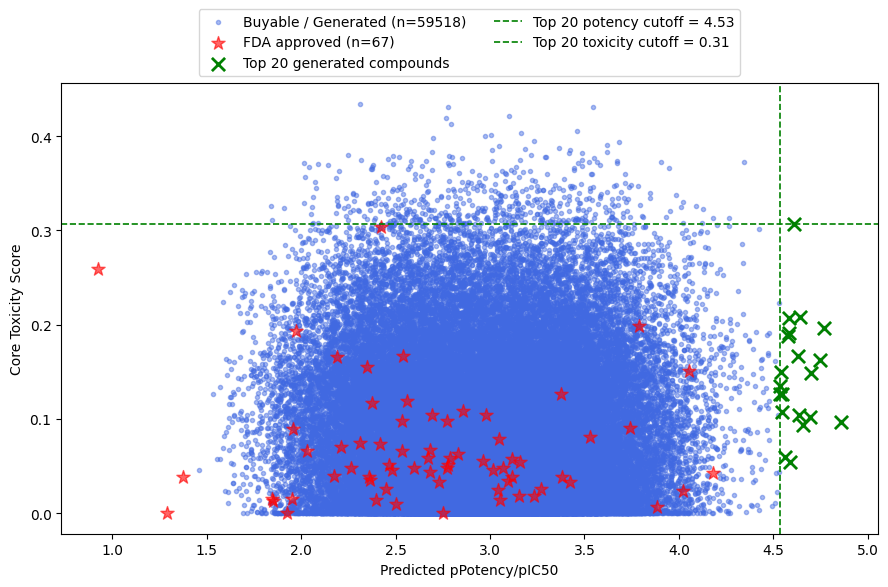

In [89]:
import matplotlib.pyplot as plt

# Dataframes
generatedDF = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core.copy()
fdaDF = drugBankDrug_FDAapproved_antibiotic_wToxicity_core.copy()

# Keep only rows with required columns
generatedDF = generatedDF[
    generatedDF["pPotency_prediction"].notna() &
    generatedDF["Core_Toxicity_Score"].notna()
].copy()

fdaDF = fdaDF[
    fdaDF["pPotency_prediction"].notna() &
    fdaDF["Core_Toxicity_Score"].notna()
].copy()

# Top 20 generated compounds:
# highest potency first, then lowest toxicity
topN = 20
topGeneratedDF = (
    generatedDF
    .sort_values(
        by=["pPotency_prediction", "Core_Toxicity_Score"],
        ascending=[False, True]
    )
    .head(topN)
    .copy()
)

# Threshold lines from top 20 generated compounds
potencyLine = topGeneratedDF["pPotency_prediction"].min()
toxicityLine = topGeneratedDF["Core_Toxicity_Score"].max()

generatedCount = len(generatedDF)
fdaCount = len(fdaDF)
topCount = len(topGeneratedDF)

plt.figure(figsize=(9, 6))

# Buyable / generated compounds
plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Buyable / Generated (n={generatedCount})"
)

# FDA-approved antibiotic compounds
plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Core_Toxicity_Score"],
    alpha=0.6,
    marker="*",
    c="red",
    s=100,
    label=f"FDA approved (n={fdaCount})"
)

# Top 20 generated compounds
plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="green",
    linewidths=2,
    label=f"Top 20 generated compounds"
)

# Threshold lines from top 20 generated compounds
plt.axvline(
    x=potencyLine,
    c="green",
    linestyle="--",
    linewidth=1.2,
    label=f"Top 20 potency cutoff = {potencyLine:.2f}"
)

plt.axhline(
    y=toxicityLine,
    c="green",
    linestyle="--",
    linewidth=1.2,
    label=f"Top 20 toxicity cutoff = {toxicityLine:.2f}"
)

plt.xlabel("Predicted pPotency/pIC50")
plt.ylabel("Core Toxicity Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=2)
plt.tight_layout()
svg_path = os.path.join(saveDir, "BacillusAnthracisVirus_DORAnetGenerated_plot_pPotency_CoreToxicity.svg")
png_path = os.path.join(saveDir, "BacillusAnthracisVirus_DORAnetGenerated_plot_pPotency_CoreToxicity.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Add `Mechanistic_Alert_Score` & `ADME_Liability_Score` with `Toxicity`

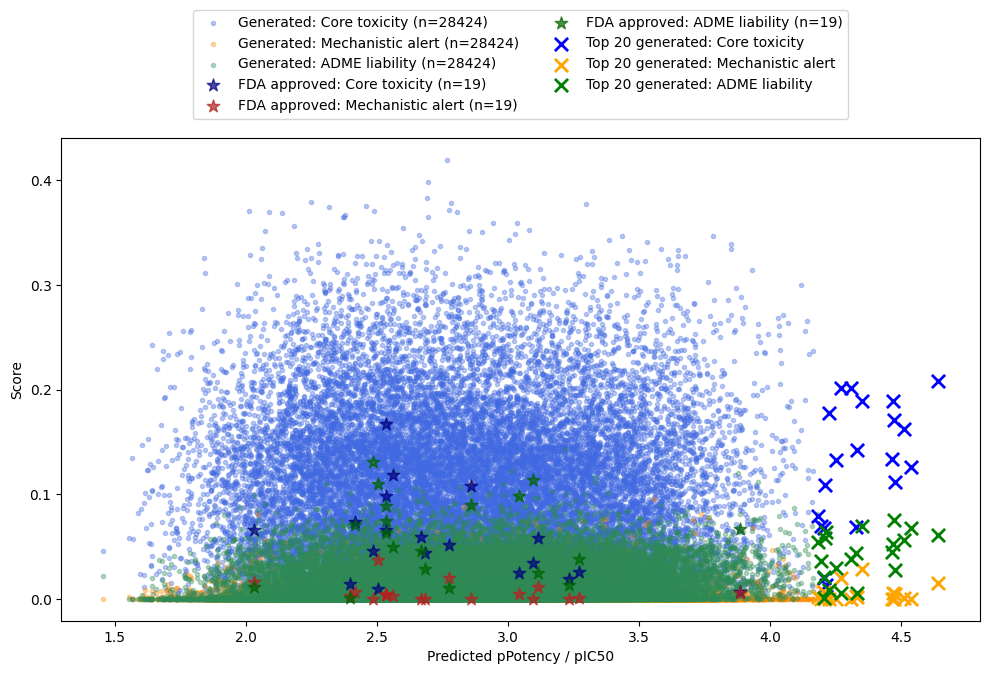

In [90]:
import os
import matplotlib.pyplot as plt

# Best generated compounds after full ADMET filtering
generatedDF = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_ADMET.copy()
fdaDF = drugBankDrug_FDAapproved_antibiotic_wToxicity_ADMET.copy()

requiredCols = [
    "pPotency_prediction",
    "Core_Toxicity_Score",
    "Mechanistic_Alert_Score",
    "ADME_Liability_Score"
]

generatedDF = generatedDF.dropna(subset=requiredCols).copy()
fdaDF = fdaDF.dropna(subset=requiredCols).copy()

# Rank generated compounds by potency first, then lowest liabilities
bestGeneratedDF = (
    generatedDF
    .sort_values(
        by=[
            "pPotency_prediction",
            "Core_Toxicity_Score",
            "Mechanistic_Alert_Score",
            "ADME_Liability_Score"
        ],
        ascending=[False, True, True, True]
    )
    .reset_index(drop=True)
)

topN = 20
topGeneratedDF = bestGeneratedDF.head(topN).copy()

generatedCount = len(generatedDF)
fdaCount = len(fdaDF)
topCount = len(topGeneratedDF)

plt.figure(figsize=(10, 7))

# Generated compounds
plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Core_Toxicity_Score"],
    alpha=0.35,
    marker=".",
    c="royalblue",
    label=f"Generated: Core toxicity (n={generatedCount})"
)

plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Mechanistic_Alert_Score"],
    alpha=0.35,
    marker=".",
    c="darkorange",
    label=f"Generated: Mechanistic alert (n={generatedCount})"
)

plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["ADME_Liability_Score"],
    alpha=0.35,
    marker=".",
    c="seagreen",
    label=f"Generated: ADME liability (n={generatedCount})"
)

# FDA-approved reference compounds
plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Core_Toxicity_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="navy",
    label=f"FDA approved: Core toxicity (n={fdaCount})"
)

plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Mechanistic_Alert_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="firebrick",
    label=f"FDA approved: Mechanistic alert (n={fdaCount})"
)

plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["ADME_Liability_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="darkgreen",
    label=f"FDA approved: ADME liability (n={fdaCount})"
)

# Top generated compounds
plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="blue",
    linewidths=2,
    label=f"Top {topN} generated: Core toxicity"
)

plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Mechanistic_Alert_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="orange",
    linewidths=2,
    label=f"Top {topN} generated: Mechanistic alert"
)

plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["ADME_Liability_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="green",
    linewidths=2,
    label=f"Top {topN} generated: ADME liability"
)

plt.xlabel("Predicted pPotency / pIC50")
plt.ylabel("Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.28), ncol=2)
plt.tight_layout()

svg_path = os.path.join(saveDir, "BacillusAnthracisVirus_DORAnetGenerated_plot_AllThreeScores.svg")
png_path = os.path.join(saveDir, "BacillusAnthracisVirus_DORAnetGenerated_plot_AllThreeScores.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

In [81]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
df = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core

# Predicted pPotency from the new dataframe
predicted_pPotency = df['pPotency_prediction'].values

top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]  # Last (20th) value
highest_pPotency = predicted_pPotency[top_20_idx[0]]  # First (1st) value

# Convert to IC50 in µM
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM   = 10**(-highest_pPotency) * 1e6
top_20_std = df['pPotency_std'].values[top_20_idx]


print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} (IC50: {cutoff_IC50_uM:.3f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} (IC50: {best_IC50_uM:.3f} µM)")
print(f"Mean pPotency_std over top-20: {np.mean(top_20_std):.3f}")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} - {highest_pPotency:.2f}; IC50 --> {cutoff_IC50_uM:.3f} - {best_IC50_uM:.3f} µM")

Top 20 compounds cutoff pPotency: 4.53 (IC50: 29.215 µM)
Highest predicted pPotency: 4.86 (IC50: 13.902 µM)
Mean pPotency_std over top-20: 1.938
pPotency range of top 20 compounds: pPotency --> 4.53 - 4.86; IC50 --> 29.215 - 13.902 µM


## Check toxicty for `Basidalin` only DORANET generated antibioticsData set

In [82]:
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_BasidalinOnlyDORAnetGenerated_Antibiotic_ARTprediction.csv')
max_val = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all['pPotency_prediction'].max()
min_val = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all

pPotency_prediction range: 2.413 → 4.628


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,C1=C(/C(=C\C=O)/OC1=O)N,True,BasidalinOnly_gen3,4.214799,1.941002,0.410435,8.019163,0.000061,9.568348e-09,0.388656
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,BasidalinOnly_gen3,3.526906,1.930244,-0.256372,7.310185,0.000297,4.895708e-08,1.804561
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,BasidalinOnly_gen3,3.252108,1.929911,-0.530518,7.034734,0.000560,9.231371e-08,3.392489
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,BasidalinOnly_gen3,2.689813,1.934148,-1.101116,6.480743,0.002043,3.305651e-07,12.621659
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,BasidalinOnly_gen3,2.674573,1.935209,-1.118437,6.467584,0.002116,3.407348e-07,13.135214
...,...,...,...,...,...,...,...,...,...,...
4125,NCC(=O)CC1(O)OC(=O)C=C1N,False,BasidalinOnly_gen3,3.487859,1.943038,-0.320496,7.296213,0.000325,5.055764e-08,2.091684
4126,NC1=CC(O)O/C1=C/C(=O)C(N)O,False,BasidalinOnly_gen3,3.983282,1.946872,0.167413,7.799151,0.000104,1.587996e-08,0.680122
4127,NCC(O)/C(O)=C1/OC(=O)C=C1N,False,BasidalinOnly_gen3,3.139712,1.949148,-0.680618,6.960042,0.000725,1.096371e-07,4.793111
4128,NCC(=O)/C(O)=C1/OC(O)C=C1N,False,BasidalinOnly_gen3,3.496918,1.951176,-0.327388,7.321224,0.000318,4.772835e-08,2.125143


### Read predicted ADMET properties for all candidate SMILES

In [83]:
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_BasidalinOnlyDORAnetGenerated_Antibiotic_ARTprediction_wToxicity.csv')
max_val = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity

pPotency_prediction range: 2.413 → 4.628


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,C1=C(/C(=C\C=O)/OC1=O)N,4.214799,1.941002,0.410435,8.019163,0.000061,9.568348e-09,0.388656,139.110,-0.53140,...,88.871656,14.579294,29.934083,43.001163,52.966266,40.131834,31.795269,31.795269,81.233036,61.302831
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,3.526906,1.930244,-0.256372,7.310185,0.000297,4.895708e-08,1.804561,507.182,-1.62900,...,5.428461,23.381155,54.633579,87.398216,4.652966,9.112059,36.719659,28.887166,89.414502,9.732454
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,2.689813,1.934148,-1.101116,6.480743,0.002043,3.305651e-07,12.621659,785.557,-2.42396,...,5.893757,12.563009,56.688639,69.910818,4.071345,53.392788,39.433889,46.219465,82.939124,2.326483
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,2.674573,1.935209,-1.118437,6.467584,0.002116,3.407348e-07,13.135214,787.573,-1.75026,...,4.769290,15.936409,61.962001,83.365646,3.140752,61.186506,42.807290,44.784800,85.071733,7.134548
4,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,3.139028,1.938263,-0.659967,6.938023,0.000726,1.153392e-07,4.570537,744.417,-2.89890,...,3.799922,19.542458,50.872431,92.904226,2.869329,13.803800,30.050407,24.505622,92.594029,16.401706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3839,NCC(=O)CC1(O)OC(=O)C=C1N,3.487859,1.943038,-0.320496,7.296213,0.000325,5.055764e-08,2.091684,186.167,-2.00770,...,37.146181,37.378829,2.869329,7.056999,12.563009,52.423420,13.532377,5.040713,94.998061,36.874758
3840,NC1=CC(O)O/C1=C/C(=O)C(N)O,3.983282,1.946872,0.167413,7.799151,0.000104,1.587996e-08,0.680122,186.167,-2.09230,...,14.967041,19.736332,7.793718,48.662272,7.871268,34.587049,17.758821,5.893757,88.018612,85.808453
3841,NCC(O)/C(O)=C1/OC(=O)C=C1N,3.139712,1.949148,-0.680618,6.960042,0.000725,1.096371e-07,4.793111,186.167,-1.52500,...,24.621946,29.701435,5.428461,37.572703,12.563009,34.082978,17.875145,16.362931,85.343156,59.092672
3842,NCC(=O)/C(O)=C1/OC(O)C=C1N,3.496918,1.951176,-0.327388,7.321224,0.000318,4.772835e-08,2.125143,186.167,-1.52500,...,19.852656,36.952307,12.175262,9.461031,18.069019,26.948430,20.317953,13.144630,89.298178,51.958123


### Retain potency predictions along with toxicity, mechanistic, and ADME-related endpoints

In [84]:
# Potency-related columns
potencyCols = [
    "SMILES",
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity.columns
]

BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity.shape)
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity.head()

Filtered dataframe shape: (3844, 41)


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,C1=C(/C(=C\C=O)/OC1=O)N,4.214799,1.941002,0.410435,8.019163,0.000061,9.568348e-09,0.388656,0.920004,0.030941,...,0.625969,0.792464,0.207908,0.073610,0.032674,0.056531,0.016988,0.001381,0.110769,0.037297
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,3.526906,1.930244,-0.256372,7.310185,0.000297,4.895708e-08,1.804561,0.033052,0.330824,...,0.024185,0.159878,0.001577,0.034541,0.056855,0.011661,0.015668,0.198030,0.076890,0.001108
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,2.689813,1.934148,-1.101116,6.480743,0.002043,3.305651e-07,12.621659,0.239975,0.900458,...,0.070120,0.380114,0.007940,0.026014,0.047826,0.052646,0.026518,0.152412,0.267949,0.046004
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,2.674573,1.935209,-1.118437,6.467584,0.002116,3.407348e-07,13.135214,0.188998,0.908109,...,0.050004,0.349236,0.005862,0.050689,0.057204,0.072706,0.040867,0.214760,0.236050,0.066886
4,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,3.139028,1.938263,-0.659967,6.938023,0.000726,1.153392e-07,4.570537,0.160844,0.619006,...,0.033647,0.122790,0.001046,0.012560,0.021261,0.009916,0.009539,0.241743,0.165820,0.002698


### Multiparameter optimization (MPO) framework based ADMET scoring

We replaced simple arithmetic averaging with a weighted desirability-based multiparameter optimization (MPO) framework. Each ADMET endpoint was converted to a 0–1 desirability value, where `1 --> favorable` and `0 --> unfavorable` profile. Category-level scores were then combined using weighted geometric means, following the same general pattern used in QED and ADMET-score approaches.

**References**

1. ADMET-score – a comprehensive scoring function for evaluation of chemical drug-likeness (https://pubs.rsc.org/en/content/articlelanding/2019/md/c8md00472b)
2. Quantifying the chemical beauty of drugs (https://www.nature.com/articles/nchem.1243)

In [85]:
# =========================================================
# 1. Endpoint groups
# =========================================================
coreToxicityCols = [
    "AMES", "hERG", "DILI", "ClinTox",
    "Carcinogens_Lagunin", "Skin_Reaction", "LD50_Zhu"
]

mechanisticAlertCols = [
    "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53",
    "NR-AR-LBD", "NR-AR", "NR-AhR", "NR-Aromatase",
    "NR-ER-LBD", "NR-ER", "NR-PPAR-gamma"
]

admeLowerIsBetter = [
    "Pgp_Broccatelli",
    "CYP1A2_Veith", "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels", "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels", "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels", "CYP3A4_Veith",
]

admeHigherIsBetter = [
    "Caco2_Wang", "HIA_Hou", "PAMPA_NCATS", "Bioavailability_Ma"
]

# Keep BBB optional for anti-infective projects
includeBBB = False
if includeBBB:
    admeLowerIsBetter = admeLowerIsBetter + ["BBB_Martins"]

allAdmetCols = sorted(set(
    coreToxicityCols + mechanisticAlertCols + admeLowerIsBetter + admeHigherIsBetter
))

# =========================================================
# 2. Input data
# =========================================================
candidateDF = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity.copy()
referenceDF = drugBankDrug_FDAapproved_antibiotic_wToxicity.copy()

# Only keep ADMET columns that actually exist in both datasets
availableCols = [
    col for col in allAdmetCols
    if col in candidateDF.columns and col in referenceDF.columns
]

coreAvailable = [col for col in coreToxicityCols if col in availableCols]
mechAvailable = [col for col in mechanisticAlertCols if col in availableCols]
admeLowerAvailable = [col for col in admeLowerIsBetter if col in availableCols]
admeHigherAvailable = [col for col in admeHigherIsBetter if col in availableCols]

# =========================================================
# 3. Reference statistics from FDA-approved antibiotics
#    A) Percentiles for Stage 1/2 filtering
#    B) Mean/std for desirability scoring
# =========================================================
referenceNumericDF = referenceDF[availableCols].apply(pd.to_numeric, errors="coerce")

percentileSummaryDF = (
    referenceNumericDF
    .agg([
        lambda x: x.quantile(0.10),
        lambda x: x.quantile(0.90)
    ])
    .T
)
percentileSummaryDF.columns = ["q10", "q90"]

meanStdSummaryDF = (
    referenceNumericDF
    .agg(["mean", lambda x: x.std(ddof=0)])
    .T
)
meanStdSummaryDF.columns = ["Mean", "Std"]

percentileDict = percentileSummaryDF.to_dict(orient="index")
meanStdDict = meanStdSummaryDF.to_dict(orient="index")

# =========================================================
# 4. Helper functions
# =========================================================
epsilon = 1e-6

def clip01(series):
    return series.clip(lower=epsilon, upper=1 - epsilon)

def buildPercentileMask(df, lowerIsBetterCols, higherIsBetterCols, percentileDict):
    mask = pd.Series(True, index=df.index)

    for col in lowerIsBetterCols:
        if col not in df.columns or col not in percentileDict:
            continue
        series = pd.to_numeric(df[col], errors="coerce")
        mask &= series <= percentileDict[col]["q90"]

    for col in higherIsBetterCols:
        if col not in df.columns or col not in percentileDict:
            continue
        series = pd.to_numeric(df[col], errors="coerce")
        mask &= series >= percentileDict[col]["q10"]

    return mask

def desirabilityLowerIsBetter(series, endpointName, meanStdDict):
    meanVal = meanStdDict[endpointName]["Mean"]
    stdVal = meanStdDict[endpointName]["Std"]

    if pd.isna(meanVal) or pd.isna(stdVal) or stdVal <= 0:
        return pd.Series(0.5, index=series.index)

    z = (series - meanVal) / stdVal
    desirability = np.where(series <= meanVal, 1.0, np.exp(-0.5 * z**2))
    return clip01(pd.Series(desirability, index=series.index))

def desirabilityHigherIsBetter(series, endpointName, meanStdDict):
    meanVal = meanStdDict[endpointName]["Mean"]
    stdVal = meanStdDict[endpointName]["Std"]

    if pd.isna(meanVal) or pd.isna(stdVal) or stdVal <= 0:
        return pd.Series(0.5, index=series.index)

    z = (meanVal - series) / stdVal
    desirability = np.where(series >= meanVal, 1.0, np.exp(-0.5 * z**2))
    return clip01(pd.Series(desirability, index=series.index))

def weightedGeometricMean(dfValues, weightsDict):
    cols = [col for col in weightsDict if col in dfValues.columns]
    if len(cols) == 0:
        return pd.Series(np.nan, index=dfValues.index)

    weights = np.array([weightsDict[col] for col in cols], dtype=float)
    weights = weights / weights.sum()

    values = dfValues[cols].copy().clip(lower=epsilon, upper=1 - epsilon)
    return np.exp(np.log(values).mul(weights, axis=1).sum(axis=1))

def addDesirabilityScores(df):
    df = df.copy()

    coreWeights = {col: 1.0 for col in coreAvailable}
    mechWeights = {col: 1.0 for col in mechAvailable}
    admeWeights = {col: 1.0 for col in (admeLowerAvailable + admeHigherAvailable)}

    coreDesDF = pd.DataFrame(index=df.index)
    for col in coreAvailable:
        coreDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    mechDesDF = pd.DataFrame(index=df.index)
    for col in mechAvailable:
        mechDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    admeDesDF = pd.DataFrame(index=df.index)
    for col in admeLowerAvailable:
        admeDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )
    for col in admeHigherAvailable:
        admeDesDF[col] = desirabilityHigherIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    df["Core_Toxicity_Desirability"] = weightedGeometricMean(coreDesDF, coreWeights)
    df["Core_Toxicity_Score"] = 1 - df["Core_Toxicity_Desirability"]

    df["Mechanistic_Alert_Desirability"] = weightedGeometricMean(mechDesDF, mechWeights)
    df["Mechanistic_Alert_Score"] = 1 - df["Mechanistic_Alert_Desirability"]

    df["ADME_Desirability"] = weightedGeometricMean(admeDesDF, admeWeights)
    df["ADME_Liability_Score"] = 1 - df["ADME_Desirability"]

    return df

def keepConciseColumns(df):
    keepCols = [col for col in ["SMILES", "smiles", "ATC_code", "Drug_Type", "pPotency_prediction", "pPotency_std"] if col in df.columns]
    scoreCols = [
        "Core_Toxicity_Desirability", "Core_Toxicity_Score",
        "Mechanistic_Alert_Desirability", "Mechanistic_Alert_Score",
        "ADME_Desirability", "ADME_Liability_Score"
    ]
    keepCols += [col for col in scoreCols if col in df.columns]
    return df[keepCols].copy()

# =========================================================
# 5. Add score columns to both datasets
# =========================================================
candidateScoredDF = addDesirabilityScores(candidateDF)
referenceScoredDF = addDesirabilityScores(referenceDF)

# =========================================================
# 6. Stage 1: percentile-based toxicity-first filtering
#    lower-is-better endpoints must be <= antibiotic q90
# =========================================================
candidateCoreMask = buildPercentileMask(
    candidateScoredDF,
    lowerIsBetterCols=coreAvailable,
    higherIsBetterCols=[],
    percentileDict=percentileDict
)

referenceCoreMask = buildPercentileMask(
    referenceScoredDF,
    lowerIsBetterCols=coreAvailable,
    higherIsBetterCols=[],
    percentileDict=percentileDict
)

candidateCoreDF = candidateScoredDF.loc[candidateCoreMask].reset_index(drop=True)
referenceCoreDF = referenceScoredDF.loc[referenceCoreMask].reset_index(drop=True)

# =========================================================
# 7. Stage 2: percentile-based mechanistic/ADME filtering
#    mechanistic + ADME liabilities <= q90
#    favorable ADME endpoints >= q10
# =========================================================
candidateAdmetMask = buildPercentileMask(
    candidateCoreDF,
    lowerIsBetterCols=mechAvailable + admeLowerAvailable,
    higherIsBetterCols=admeHigherAvailable,
    percentileDict=percentileDict
)

referenceAdmetMask = buildPercentileMask(
    referenceCoreDF,
    lowerIsBetterCols=mechAvailable + admeLowerAvailable,
    higherIsBetterCols=admeHigherAvailable,
    percentileDict=percentileDict
)

candidateAdmetDF = candidateCoreDF.loc[candidateAdmetMask].reset_index(drop=True)
referenceAdmetDF = referenceCoreDF.loc[referenceAdmetMask].reset_index(drop=True)

# =========================================================
# 8. Final concise output dataframes
# =========================================================
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_core = keepConciseColumns(candidateCoreDF)
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_ADMET = keepConciseColumns(candidateAdmetDF)

drugBankDrug_FDAapproved_antibiotic_wToxicity_core = keepConciseColumns(referenceCoreDF)
drugBankDrug_FDAapproved_antibiotic_wToxicity_ADMET = keepConciseColumns(referenceAdmetDF)

print(f"BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_core: {BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_core.shape}")
print(f"BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_ADMET: {BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_ADMET.shape}")
print(f"drugBankDrug_FDAapproved_antibiotic_wToxicity_core: {drugBankDrug_FDAapproved_antibiotic_wToxicity_core.shape}")
print(f"drugBankDrug_FDAapproved_antibiotic_wToxicity_ADMET: {drugBankDrug_FDAapproved_antibiotic_wToxicity_ADMET.shape}")

BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_core: (295, 9)
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_ADMET: (92, 9)
drugBankDrug_FDAapproved_antibiotic_wToxicity_core: (67, 11)
drugBankDrug_FDAapproved_antibiotic_wToxicity_ADMET: (19, 11)


### Define filter for compound ranking based on `ADMET` scores

### Plot full distribution + highlighted filtered dataframe

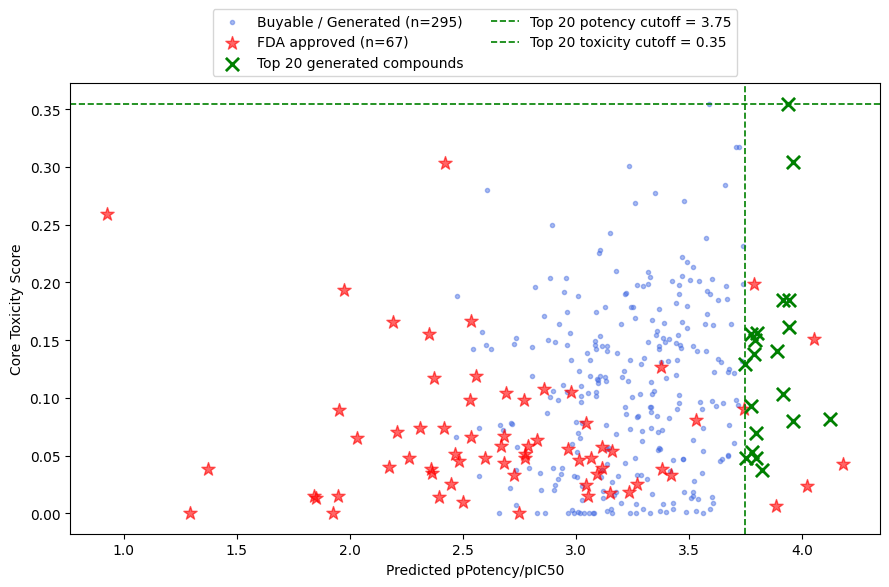

In [91]:
import matplotlib.pyplot as plt

# Dataframes
generatedDF = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_core.copy()
fdaDF = drugBankDrug_FDAapproved_antibiotic_wToxicity_core.copy()

# Keep only rows with required columns
generatedDF = generatedDF[
    generatedDF["pPotency_prediction"].notna() &
    generatedDF["Core_Toxicity_Score"].notna()
].copy()

fdaDF = fdaDF[
    fdaDF["pPotency_prediction"].notna() &
    fdaDF["Core_Toxicity_Score"].notna()
].copy()

# Top 20 generated compounds:
# highest potency first, then lowest toxicity
topN = 20
topGeneratedDF = (
    generatedDF
    .sort_values(
        by=["pPotency_prediction", "Core_Toxicity_Score"],
        ascending=[False, True]
    )
    .head(topN)
    .copy()
)

# Threshold lines from top 20 generated compounds
potencyLine = topGeneratedDF["pPotency_prediction"].min()
toxicityLine = topGeneratedDF["Core_Toxicity_Score"].max()

generatedCount = len(generatedDF)
fdaCount = len(fdaDF)
topCount = len(topGeneratedDF)

plt.figure(figsize=(9, 6))

# Buyable / generated compounds
plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Buyable / Generated (n={generatedCount})"
)

# FDA-approved antibiotic compounds
plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Core_Toxicity_Score"],
    alpha=0.6,
    marker="*",
    c="red",
    s=100,
    label=f"FDA approved (n={fdaCount})"
)

# Top 20 generated compounds
plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="green",
    linewidths=2,
    label=f"Top 20 generated compounds"
)

# Threshold lines from top 20 generated compounds
plt.axvline(
    x=potencyLine,
    c="green",
    linestyle="--",
    linewidth=1.2,
    label=f"Top 20 potency cutoff = {potencyLine:.2f}"
)

plt.axhline(
    y=toxicityLine,
    c="green",
    linestyle="--",
    linewidth=1.2,
    label=f"Top 20 toxicity cutoff = {toxicityLine:.2f}"
)

plt.xlabel("Predicted pPotency/pIC50")
plt.ylabel("Core Toxicity Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=2)
plt.tight_layout()
svg_path = os.path.join(saveDir, "BacillusAnthracisVirus_BasidalinOnly_pPotency_CoreToxicity.svg")
png_path = os.path.join(saveDir, "BacillusAnthracisVirus_BasidalinOnly_pPotency_CoreToxicity.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Add `Mechanistic_Alert_Score` & `ADME_Liability_Score` with `Toxicity`

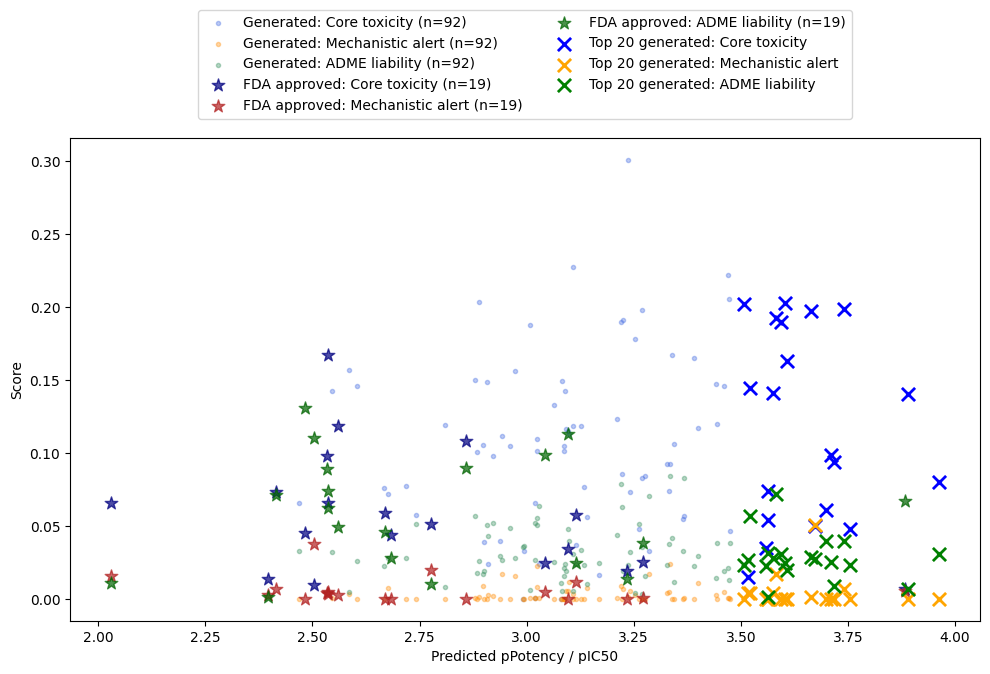

In [92]:
import os
import matplotlib.pyplot as plt

# Best generated compounds after full ADMET filtering
generatedDF = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_ADMET.copy()
fdaDF = drugBankDrug_FDAapproved_antibiotic_wToxicity_ADMET.copy()

requiredCols = [
    "pPotency_prediction",
    "Core_Toxicity_Score",
    "Mechanistic_Alert_Score",
    "ADME_Liability_Score"
]

generatedDF = generatedDF.dropna(subset=requiredCols).copy()
fdaDF = fdaDF.dropna(subset=requiredCols).copy()

# Rank generated compounds by potency first, then lowest liabilities
bestGeneratedDF = (
    generatedDF
    .sort_values(
        by=[
            "pPotency_prediction",
            "Core_Toxicity_Score",
            "Mechanistic_Alert_Score",
            "ADME_Liability_Score"
        ],
        ascending=[False, True, True, True]
    )
    .reset_index(drop=True)
)

topN = 20
topGeneratedDF = bestGeneratedDF.head(topN).copy()

generatedCount = len(generatedDF)
fdaCount = len(fdaDF)
topCount = len(topGeneratedDF)

plt.figure(figsize=(10, 7))

# Generated compounds
plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Core_Toxicity_Score"],
    alpha=0.35,
    marker=".",
    c="royalblue",
    label=f"Generated: Core toxicity (n={generatedCount})"
)

plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Mechanistic_Alert_Score"],
    alpha=0.35,
    marker=".",
    c="darkorange",
    label=f"Generated: Mechanistic alert (n={generatedCount})"
)

plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["ADME_Liability_Score"],
    alpha=0.35,
    marker=".",
    c="seagreen",
    label=f"Generated: ADME liability (n={generatedCount})"
)

# FDA-approved reference compounds
plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Core_Toxicity_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="navy",
    label=f"FDA approved: Core toxicity (n={fdaCount})"
)

plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Mechanistic_Alert_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="firebrick",
    label=f"FDA approved: Mechanistic alert (n={fdaCount})"
)

plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["ADME_Liability_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="darkgreen",
    label=f"FDA approved: ADME liability (n={fdaCount})"
)

# Top generated compounds
plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="blue",
    linewidths=2,
    label=f"Top {topN} generated: Core toxicity"
)

plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Mechanistic_Alert_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="orange",
    linewidths=2,
    label=f"Top {topN} generated: Mechanistic alert"
)

plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["ADME_Liability_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="green",
    linewidths=2,
    label=f"Top {topN} generated: ADME liability"
)

plt.xlabel("Predicted pPotency / pIC50")
plt.ylabel("Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.28), ncol=2)
plt.tight_layout()

svg_path = os.path.join(saveDir, "BacillusAnthracisVirus_BasidalinOnly_plot_bestCompounds_AllThreeScores.svg")
png_path = os.path.join(saveDir, "BacillusAnthracisVirus_BasidalinOnly_plot_bestCompounds_AllThreeScores.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

In [88]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
df = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_core

# Predicted pPotency from the new dataframe
predicted_pPotency = df['pPotency_prediction'].values

top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]  # Last (20th) value
highest_pPotency = predicted_pPotency[top_20_idx[0]]  # First (1st) value

# Convert to IC50 in µM
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM   = 10**(-highest_pPotency) * 1e6
top_20_std = df['pPotency_std'].values[top_20_idx]


print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} (IC50: {cutoff_IC50_uM:.3f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} (IC50: {best_IC50_uM:.3f} µM)")
print(f"Mean pPotency_std over top-20: {np.mean(top_20_std):.3f}")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} - {highest_pPotency:.2f}; IC50 --> {cutoff_IC50_uM:.3f} - {best_IC50_uM:.3f} µM")

Top 20 compounds cutoff pPotency: 3.75 (IC50: 178.213 µM)
Highest predicted pPotency: 4.12 (IC50: 75.076 µM)
Mean pPotency_std over top-20: 1.944
pPotency range of top 20 compounds: pPotency --> 3.75 - 4.12; IC50 --> 178.213 - 75.076 µM
